In [ ]:
# CELL 1: ONE-TIME SETUP — REFACTORED & FIXED (No Exit Status 1)
import subprocess, sys, os, gc

# OPTIMIZATION: Reduce memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# FIX: Handle NVIDIA library conflicts
try:
    import torch
except ImportError:
    print("⚠️ Torch import failed. Fixing NVIDIA dependencies...")
    subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "nvidia-nvjitlink-cu12"])
    import torch

print("Checking GPU...")
if not torch.cuda.is_available():
    raise RuntimeError("GPU REQUIRED → Runtime → Change runtime type → T4/A100")

print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Install dependencies (original + new for imblearn, bayes_opt)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "packaging", "ninja"])
subprocess.run([sys.executable, "-m", "pip", "install", "--extra-index-url=https://pypi.nvidia.com",
    "cudf-cu12==25.10.00", "cuml-cu12==25.10.00", "xgboost", "numba", "pyarrow"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install",
    "lion-pytorch", "lightgbm", "catboost", "gdown", "optuna", "bayesian-optimization", "imbalanced-learn"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna-integration[xgboost]"])
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "xformers"])

print("ALL DEPENDENCIES INSTALLED!")

Checking GPU...
GPU: NVIDIA A100-SXM4-80GB | VRAM: 85.2 GB
ALL DEPENDENCIES INSTALLED!


In [ ]:
# CELL 2: CONFIGURATION (TUNING-ENABLED FOR BEST HYPERPARAMETERS)
from types import SimpleNamespace
import os
from pathlib import Path

cfg = SimpleNamespace(
    # General
    seed=42,
    device="cuda" if torch.cuda.is_available() else "cpu",

    # Data path and label (restored to your original values)
    data_path="merged_clean_imputed_v2.parquet",
    label_col="label_unified",
    use_sample=False,
    use_advanced_features=True,  # keep your advanced feature block active

    # Artifacts
    artifact_root=os.environ.get("ARTIFACT_ROOT", "artifacts"),
    ae_cache_path=None,
    ae_model_path=None,
    tabt_model_path=None,
    stacking_model_path=None,

    # Data split
    use_time_based_split=False,
    time_split_column="year",
    time_split_value=2018,
    time_split_test_size=0.5,
    min_val_positives=50,
    train_year_cutoff=2017,  # year < cutoff -> train, else val/test

    # Training general - MEMORY OPTIMIZED
    batch_size=256,  # INCREASED for speed (safe with AMP on T4/A100)
    dataloader_workers=2,  # Async data loading for speed
    use_compile=False,  # DISABLED - torch.compile uses more memory
    use_amp=True,  # Keep AMP for memory savings
    use_pin_memory=True,  # Faster CPU→GPU transfers with workers>0
    use_xformers=True,  # xformers memory_efficient_attention (NOT flash)

    # ============================================================
    # HYPERPARAMETER TUNING - ENABLED FOR BEST PERFORMANCE
    # ============================================================
    # ✅ TUNE: Models that benefit significantly from tuning
    # ❌ SKIP: Models where tuning is not wise (unstable, OOM risk, or minimal gain)

    tune_ae=False,           # ❌ SKIP: VAE is for feature extraction, not classification
                             #    Tuning reconstruction loss doesn't improve downstream AP

    tune_tabt=True,          # ✅ TUNE: SAINT benefits greatly from hidden/heads/layers tuning
    tune_wide_deep=True,     # ✅ TUNE: Architecture (layers, dropout) impacts performance
    tune_rnn=True,           # ✅ TUNE: Hidden dim, layers, dropout are crucial

    tune_xgb=True,           # ✅ TUNE: Tree depth, learning rate, regularization
    tune_lgbm=True,          # ✅ TUNE: Similar to XGBoost, big gains from tuning
    tune_catboost=True,      # ✅ TUNE: Depth, L2 reg, learning rate (GPU-efficient)

    tune_nn=False,           # ❌ SKIP: Generic toggle, use model-specific flags above

    optuna_trials={
        "ae": 10,            # Minimal if enabled
        "tabt": 25,          # Good coverage for transformer architecture
        "wide_deep": 20,     # Architecture search
        "rnn": 20,           # Hidden/layers search
        "xgb": 30,           # Tree models tune fast
        "lgbm": 30,          # Tree models tune fast
        "catboost": 25,      # Slightly fewer (slower per trial)
    },
    optuna_timeout=3600,     # 1 hour timeout per model (increased for thorough search)
    optuna_sample_rows=100_000,  # Larger sample for better hyperparameter estimates

    # SAINT / TabTransformer - TUNING-OPTIMIZED
    tabt_optuna_max_rows=20_000,      # Larger sample for better estimates
    tabt_optuna_batch_size=128,       # Keep reasonable for memory
    tabt_optuna_min_free_gb=0.5,      # VRAM threshold
    tabt_optuna_clear_cache=True,
    tabt_epochs=15,          # More epochs for tuned model
    tabt_hidden_dim=128,     # Will be overridden by tuning
    tabt_depth=3,  # REDUCED from 4
    tabt_heads=4,  # REDUCED from 8
    tabt_dropout=0.2,
    tabt_patience=3,

    # Wide & Deep settings - MEMORY OPTIMIZED
    wide_deep_epochs=10,  # REDUCED
    wide_deep_hidden=[256, 128],  # REDUCED from [512, 256]
    wide_deep_dropout=0.2,
    wide_deep_patience=2,

    # RNN / sequence settings - MEMORY OPTIMIZED
    rnn_epochs=8,  # REDUCED
    rnn_hidden_dim=128,  # REDUCED from 192
    rnn_num_layers=2,
    rnn_dropout=0.2,
    rnn_sequence_steps=1,  # REDUCED from 4 - less memory
    rnn_patience=2,

    # Autoencoder (AE / VAE) settings - MEMORY OPTIMIZED
    ae_normals_only=True,
    ae_latent_dim=32,
    ae_hidden_dim=128,  # REDUCED
    ae_epochs=20,  # REDUCED from 30
    ae_scheduler_patience=2,
    ae_early_stop_patience=4,  # REDUCED
    ae_optuna_clear_cache=True,
    ae_input_noise=0.0,
    ae_cache_compression=True,

    # Model toggles - CONSERVATIVE FOR MEMORY
    train_ae=True,
    train_tabt=True,
    train_wide_deep=True,
    train_rnn=True,
    train_trees=True,
    run_stacking=True,
    train_nn=False,
    train_autoencoder=True,
    train_xgb=True,
    train_lgbm=True,
    train_catboost=True,

    use_hybrid_ae=True,
    use_ssl_pretrain=False,  # DISABLED - uses extra memory

    stacking_sources=['tabt', 'wide_deep', 'rnn', 'xgb', 'lgbm', 'catboost'],

    # Tree models
    tree_cv_folds=3,
    use_smote_enn=False,  # DISABLED - SMOTE uses lots of RAM
    use_bayesian_opt=True,

    # ============================================================
    # NEW ENHANCEMENTS FOR COLAB
    # ============================================================

    # Threshold Optimization (for imbalanced data)
    optimize_threshold=True,           # Find optimal threshold for F1/PR
    threshold_metric='f1',             # 'f1', 'f2', 'precision_at_recall', 'business'
    threshold_target_recall=0.90,      # Target recall for precision_at_recall metric
    threshold_search_steps=200,        # Number of thresholds to try

    # Learning Rate Schedulers
    use_onecycle_lr=True,              # Use OneCycleLR (usually better than ReduceLROnPlateau)
    use_cosine_annealing=False,        # Alternative: CosineAnnealingWarmRestarts
    lr_warmup_epochs=2,                # Warmup epochs before full LR

    # Feature Importance
    compute_feature_importance=True,   # Compute feature importance after training
    use_shap=True,                     # Use SHAP values (slower but more accurate)
    shap_sample_size=1000,             # Samples for SHAP computation (memory-limited)
    top_features_to_show=20,           # Top N features to display

    # Prediction Confidence
    flag_low_confidence=True,          # Flag predictions with low confidence
    confidence_threshold_low=0.3,      # Below this = "likely negative"
    confidence_threshold_high=0.7,     # Above this = "likely positive"

    # Test Time Augmentation (TTA)
    use_tta=False,                     # Average predictions from augmented inputs
    tta_noise_std=0.01,                # Noise level for TTA
    tta_num_augments=5,                # Number of augmented predictions to average

    # Early Stopping Warmup
    early_stop_warmup_epochs=3,        # Don't early stop before this many epochs

    # Evaluation
    run_final_evaluation=True,         # Run comprehensive final evaluation
    save_predictions=True,             # Save all predictions to disk
    plot_curves=True,                  # Plot PR/ROC curves (Colab-friendly)

    # Misc
    use_cost_sensitive=False,
    use_lion=True,
    use_hybrid_calibration=False,
    use_hyperstack_logging=True,
    use_pin_artifacts=True,
    use_calibration=True,
    force_retrain_autoencoder=True,
    )

# --- Derived artifact directories -----------------------------------------
artifact_root = Path(cfg.artifact_root).expanduser()
artifact_root.mkdir(parents=True, exist_ok=True)
cfg.artifact_root = str(artifact_root)

cfg.cache_dir = str(artifact_root / "cache")
cfg.model_dir = str(artifact_root / "models")
cfg.metrics_dir = str(artifact_root / "metrics")
for subdir in (cfg.cache_dir, cfg.model_dir, cfg.metrics_dir):
    Path(subdir).mkdir(parents=True, exist_ok=True)

cfg.ae_cache_path = cfg.ae_cache_path or str(Path(cfg.cache_dir) / "ae_features.npz")
cfg.ae_model_path = cfg.ae_model_path or str(Path(cfg.model_dir) / "ae.pt")
cfg.tabt_model_path = cfg.tabt_model_path or str(Path(cfg.model_dir) / "tabt.pt")
cfg.wide_deep_model_path = str(Path(cfg.model_dir) / "wide_deep.pt")
cfg.rnn_model_path = str(Path(cfg.model_dir) / "rnn.pt")
cfg.xgb_model_path = str(Path(cfg.model_dir) / "xgb.json")
cfg.lgbm_model_path = str(Path(cfg.model_dir) / "lgbm.txt")
cfg.catboost_model_path = str(Path(cfg.model_dir) / "catboost.cbm")
cfg.stacking_model_path = cfg.stacking_model_path or str(Path(cfg.model_dir) / "stacking.cbm")

print("Using device:", cfg.device)
print("ARTIFACT_ROOT (from cfg.artifact_root):", cfg.artifact_root)
print("MODEL DIR:", cfg.model_dir)
print("CACHE DIR:", cfg.cache_dir)
print("DATA PATH (cfg.data_path):", cfg.data_path)
print("LABEL COLUMN (cfg.label_col):", cfg.label_col)
print("USE_SAMPLE:", cfg.use_sample)

Using device: cuda
ARTIFACT_ROOT (from cfg.artifact_root): artifacts
MODEL DIR: artifacts/models
CACHE DIR: artifacts/cache
DATA PATH (cfg.data_path): merged_clean_imputed_v2.parquet
LABEL COLUMN (cfg.label_col): label_unified
USE_SAMPLE: False


In [ ]:
# CELL 3: IMPORTS + GPU SETUP (original + new)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.utils import checkpoint as ckpt
from torch.utils.dlpack import from_dlpack
from functools import lru_cache
import cudf, cuml, cupy as cp, xgboost as xgb, lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import numpy as np, pandas as pd, gc, json, joblib, os, math
import xformers.ops as xops
import optuna
from bayes_opt import BayesianOptimization  # New
from imblearn.combine import SMOTEENN  # New
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score
from cuml.model_selection import train_test_split
from cuml.preprocessing import StandardScaler as cuScaler
from scipy.stats import vonmises  # New for periodic
from sklearn.model_selection import StratifiedKFold  # For CV

# ============================================================
# GPU-FIRST MEMORY MANAGEMENT
# ============================================================
# Configure CuPy memory pool for better GPU memory utilization
_cupy_pool = cp.cuda.MemoryPool(cp.cuda.malloc_managed)
cp.cuda.set_allocator(_cupy_pool.malloc)
_cupy_pinned_pool = cp.cuda.PinnedMemoryPool()
cp.cuda.set_pinned_memory_allocator(_cupy_pinned_pool.malloc)

def gpu_memory_info():
    """Return GPU memory usage in GB."""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        return {'allocated_gb': allocated, 'reserved_gb': reserved, 'total_gb': total, 'free_gb': total - reserved}
    return {}

def aggressive_gpu_cleanup():
    """Force aggressive GPU memory cleanup across all frameworks."""
    gc.collect()
    # PyTorch cleanup
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    # CuPy cleanup
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
    # cuDF cleanup (via RMM if available)
    try:
        import rmm
        rmm.reinitialize(pool_allocator=True, initial_pool_size=2**30)  # 1GB initial
    except ImportError:
        pass
    gc.collect()

def cudf_to_torch(df, dtype=torch.float32):
    """Zero-copy cudf DataFrame → PyTorch tensor via DLPack (stays on GPU)."""
    # Convert to cupy array first, then to torch
    cp_arr = cp.asarray(df.values)
    return torch.as_tensor(cp_arr, device='cuda', dtype=dtype)

def torch_to_cudf(tensor):
    """Zero-copy PyTorch tensor → cudf DataFrame via DLPack (stays on GPU)."""
    cp_arr = cp.asarray(tensor.detach())
    return cudf.DataFrame(cp_arr)

print(f"GPU Memory: {gpu_memory_info()}")

# ============================================================

optuna_pruner = optuna.pruners.MedianPruner(n_warmup_steps=5) if getattr(cfg, 'use_optuna_pruner', True) else None

def create_optuna_study(direction="maximize", **kwargs):
    pruner = optuna_pruner if getattr(cfg, 'use_optuna_pruner', True) else None
    return optuna.create_study(direction=direction, pruner=pruner, **kwargs)

label_cache = {}

def cache_numpy(name, arr):
    if getattr(cfg, 'cache_labels', False):
        label_cache[name] = arr
    return arr

# GPU optimizations - Updated for PyTorch 2.9+ API
torch.backends.cudnn.benchmark = True

# New TF32 API (PyTorch 2.9+)
try:
    # New API for controlling TF32 behavior
    torch.backends.cuda.matmul.fp32_precision = 'tf32'
    torch.backends.cudnn.conv.fp32_precision = 'tf32'
except AttributeError:
    # Fallback for older PyTorch versions
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# Additional GPU optimizations
try:
    torch.backends.cuda.matmul.allow_bf16_reduced_precision_reduction = True
except AttributeError:
    pass
torch.set_float32_matmul_precision('high')  # Use TF32 for better GPU throughput

def safe_roc_auc(y_true, y_score, warn=False):
    try:
        if len(np.unique(y_true)) < 2:
            if warn: print("Warning: Only one class present in y_true. ROC AUC = 0.5")
            return 0.5
        return roc_auc_score(y_true, y_score)
    except Exception as e:
        if warn: print(f"Warning: ROC AUC failed ({e}). Returning 0.5")
        return 0.5

def safe_average_precision(y_true, y_score, warn=False):
    try:
        if len(np.unique(y_true)) < 2:
            if warn: print("Warning: Only one class present in y_true. AP = 0.0")
            return 0.0
        return average_precision_score(y_true, y_score)
    except Exception as e:
        if warn: print(f"Warning: AP failed ({e}). Returning 0.0")
        return 0.0

def focal_loss_with_logits(logits, targets, alpha=0.25, gamma=2.0, pos_weight=None):
    """Focal loss with safety checks for edge cases (e.g., no positives in batch)."""
    # AMP SAFETY: always compute focal loss in FP32 to prevent underflow/overflow
    logits = logits.float()
    targets = targets.float()
    # Safety: Check for NaN/Inf in logits
    if torch.isnan(logits).any() or torch.isinf(logits).any():
        logits = torch.clamp(logits, -20, 20)

    # Check batch composition
    n_pos = (targets == 1).sum().item()
    n_neg = (targets == 0).sum().item()
    batch_size = len(targets)

    # Adaptive alpha based on batch composition
    if n_pos == 0:
        # All negatives - reduce alpha to not over-penalize (rare with weighted sampler but possible)
        alpha = 0.1
    elif n_neg == 0:
        # All positives - increase alpha
        alpha = 0.9

    if pos_weight is not None:
        weight = torch.where(targets == 1, pos_weight, torch.ones_like(targets))
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        bce_loss = bce_loss * weight
    else:
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

    pt = torch.exp(-bce_loss)
    focal_loss = alpha * (1 - pt) ** gamma * bce_loss
    return focal_loss.mean()

# ============================================================
# IMBALANCE HANDLING UTILITIES (Extreme Imbalance ~113:1)
# ============================================================
# YOUR DATA: 2,617,883 negatives : 23,028 positives (113:1 ratio)
# STRATEGY:
# - Neural nets: WeightedRandomSampler to balance batches
# - Focal loss: Standard alpha=0.25, gamma=2.0
# - Tree models: scale_pos_weight = 113 (auto-computed)
# ============================================================

def compute_imbalance_stats(y, split_name="data", raise_on_empty=False):
    """Compute and display imbalance statistics."""
    y_np = ensure_numpy(y).ravel()
    n_samples = len(y_np)
    n_pos = int((y_np == 1).sum())
    n_neg = int((y_np == 0).sum())

    if n_samples == 0:
        print(f"⚠️ [{split_name}] Empty dataset!")
        return {'n_pos': 0, 'n_neg': 0, 'ratio': 0, 'pos_rate': 0, 'n_samples': 0}

    if n_pos == 0:
        print(f"⚠️ [{split_name}] No positive samples detected!")
        if raise_on_empty:
            raise ValueError(f"No positive samples in {split_name}")
        return {'n_pos': 0, 'n_neg': n_neg, 'ratio': float('inf'), 'pos_rate': 0, 'n_samples': n_samples}

    ratio = n_neg / n_pos
    pos_rate = n_pos / n_samples

    severity = "EXTREME" if ratio > 100 else "HIGH" if ratio > 20 else "MODERATE" if ratio > 5 else "LOW"
    print(f"📊 [{split_name}] {n_neg:,} neg | {n_pos:,} pos | Ratio {ratio:.1f}:1 [{severity}]")

    return {'n_pos': n_pos, 'n_neg': n_neg, 'ratio': ratio, 'pos_rate': pos_rate, 'n_samples': n_samples}

def create_weighted_sampler(y, oversample_minority=True):
    """Create WeightedRandomSampler for imbalanced data.

    Args:
        y: Labels (numpy/tensor/cudf)
        oversample_minority: If True, balance to ~50/50 per batch

    Returns:
        WeightedRandomSampler or None if creation fails
    """
    from torch.utils.data import WeightedRandomSampler

    y_np = ensure_numpy(y).ravel().astype(np.float64)
    n_total = len(y_np)
    n_pos = int((y_np == 1).sum())
    n_neg = int((y_np == 0).sum())

    print(f"📊 Creating sampler: {n_neg:,} neg, {n_pos:,} pos")

    if n_pos == 0:
        print("⚠️ No positives - returning None (will use shuffle=True)")
        return None

    if n_neg == 0:
        print("⚠️ No negatives - returning None (will use shuffle=True)")
        return None

    ratio = n_neg / n_pos

    # Weight for each sample based on its class
    if oversample_minority:
        weight_for_pos = ratio  # Oversample minority
        weight_for_neg = 1.0
    else:
        weight_for_pos = np.sqrt(ratio)  # Less aggressive
        weight_for_neg = 1.0

    # Create weight array - each sample gets weight based on its label
    sample_weights = np.where(y_np == 1, weight_for_pos, weight_for_neg)
    sample_weights = torch.from_numpy(sample_weights).double()

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=n_total,
        replacement=True
    )

    print(f"📊 Sampler ready: pos_weight={weight_for_pos:.1f}x → expect ~50% pos per batch")
    return sampler

def get_scale_pos_weight(y, cap=200.0):
    """Get scale_pos_weight for tree models."""
    y_np = ensure_numpy(y).ravel()
    n_pos = int((y_np == 1).sum())
    n_neg = int((y_np == 0).sum())

    if n_pos == 0:
        print("⚠️ No positives for scale_pos_weight, using 1.0")
        return 1.0

    raw_weight = n_neg / n_pos
    weight = min(raw_weight, cap)

    print(f"📊 scale_pos_weight: {weight:.1f}" + (f" (capped from {raw_weight:.1f})" if raw_weight > cap else ""))
    return weight

# Aliases
compute_class_weights = lambda y, device='cuda': (get_scale_pos_weight(y), 1.0, get_scale_pos_weight(y))
compute_pos_weight = get_scale_pos_weight

# ============================================================

# --- Additional Helper Functions ---

def _to_numpy_array(x):
    """Convert various array-like objects to numpy array."""
    if isinstance(x, np.ndarray):
        return x
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    if hasattr(x, 'to_pandas'):
        return x.to_pandas().values
    if hasattr(x, 'values'):
        return x.values
    return np.asarray(x)

ensure_numpy = _to_numpy_array  # alias for backward compatibility

def recall_at_target(preds, labels, target=0.9):
    """Find threshold achieving target recall, return (actual_recall, threshold)."""
    from sklearn.metrics import precision_recall_curve
    preds = ensure_numpy(preds).ravel()
    labels = ensure_numpy(labels).ravel()
    prec, rec, thresh = precision_recall_curve(labels, preds)
    # Find index closest to target recall
    idx = np.argmin(np.abs(rec - target))
    actual_recall = rec[idx]
    # thresh is one element shorter than prec/rec
    threshold = thresh[min(idx, len(thresh) - 1)] if len(thresh) > 0 else 0.5
    return actual_recall, threshold

# ============================================================
# THRESHOLD OPTIMIZATION (Critical for Imbalanced Data)
# ============================================================

def optimize_threshold(y_true, y_probs, metric='f1', target_recall=0.9, steps=200):
    """
    Find optimal classification threshold for imbalanced data.

    Args:
        y_true: Ground truth labels
        y_probs: Predicted probabilities
        metric: 'f1', 'f2', 'precision_at_recall', 'business'
        target_recall: Target recall for precision_at_recall metric
        steps: Number of threshold values to try

    Returns:
        dict with optimal_threshold, best_score, and metrics at threshold
    """
    from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score

    y_true = ensure_numpy(y_true).ravel()
    y_probs = ensure_numpy(y_probs).ravel()

    thresholds = np.linspace(0.01, 0.99, steps)
    best_threshold = 0.5
    best_score = -1
    best_metrics = {}

    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)

        # Skip if all predictions are same class
        if len(np.unique(y_pred)) < 2:
            continue

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

        if metric == 'f1':
            score = f1
        elif metric == 'f2':
            score = f2  # Weighs recall higher than precision
        elif metric == 'precision_at_recall':
            # Maximize precision while maintaining target recall
            if recall >= target_recall:
                score = precision
            else:
                score = -1  # Invalid
        elif metric == 'business':
            # Custom: Penalize false negatives more (missed fraud)
            fn_penalty = 10  # FN is 10x worse than FP
            tp = ((y_pred == 1) & (y_true == 1)).sum()
            fp = ((y_pred == 1) & (y_true == 0)).sum()
            fn = ((y_pred == 0) & (y_true == 1)).sum()
            score = tp - fp - fn_penalty * fn
        else:
            score = f1

        if score > best_score:
            best_score = score
            best_threshold = thresh
            best_metrics = {
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'f2': f2,
                'threshold': thresh
            }

    print(f"🎯 Optimal threshold ({metric}): {best_threshold:.4f}")
    print(f"   Precision: {best_metrics.get('precision', 0):.4f} | Recall: {best_metrics.get('recall', 0):.4f} | F1: {best_metrics.get('f1', 0):.4f}")

    return {
        'optimal_threshold': best_threshold,
        'best_score': best_score,
        'metrics': best_metrics
    }

# ============================================================
# LEARNING RATE SCHEDULERS
# ============================================================

def create_scheduler(optimizer, scheduler_type, epochs, steps_per_epoch=None, **kwargs):
    """
    Create learning rate scheduler.

    Args:
        optimizer: PyTorch optimizer
        scheduler_type: 'onecycle', 'cosine', 'plateau', 'warmup_cosine'
        epochs: Total training epochs
        steps_per_epoch: Steps per epoch (required for OneCycleLR)
    """
    if scheduler_type == 'onecycle' and steps_per_epoch:
        return torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=kwargs.get('max_lr', optimizer.param_groups[0]['lr'] * 10),
            epochs=epochs,
            steps_per_epoch=steps_per_epoch,
            pct_start=kwargs.get('pct_start', 0.3),
            anneal_strategy='cos'
        )
    elif scheduler_type == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=kwargs.get('T_0', max(1, epochs // 3)),
            T_mult=kwargs.get('T_mult', 2),
            eta_min=kwargs.get('eta_min', 1e-6)
        )
    elif scheduler_type == 'warmup_cosine':
        # Linear warmup + cosine decay
        warmup_epochs = kwargs.get('warmup_epochs', 2)
        def lr_lambda(epoch):
            if epoch < warmup_epochs:
                return (epoch + 1) / warmup_epochs
            else:
                progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
                return 0.5 * (1 + np.cos(np.pi * progress))
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    else:  # plateau
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            patience=kwargs.get('patience', 3),
            factor=kwargs.get('factor', 0.5),
            min_lr=kwargs.get('min_lr', 1e-6)
        )

# ============================================================
# PREDICTION CONFIDENCE ANALYSIS
# ============================================================

def analyze_prediction_confidence(y_true, y_probs, low_thresh=0.3, high_thresh=0.7):
    """
    Analyze prediction confidence and flag uncertain predictions.

    Returns:
        dict with confidence statistics and indices of uncertain predictions
    """
    y_true = ensure_numpy(y_true).ravel()
    y_probs = ensure_numpy(y_probs).ravel()

    # Categorize predictions
    confident_negative = y_probs < low_thresh
    confident_positive = y_probs > high_thresh
    uncertain = ~confident_negative & ~confident_positive

    n_total = len(y_probs)
    n_uncertain = uncertain.sum()

    # Accuracy in each confidence band
    def band_accuracy(mask):
        if mask.sum() == 0:
            return 0.0
        preds = (y_probs[mask] > 0.5).astype(int)
        return (preds == y_true[mask]).mean()

    results = {
        'total_samples': n_total,
        'confident_negative': {
            'count': int(confident_negative.sum()),
            'pct': confident_negative.mean() * 100,
            'accuracy': band_accuracy(confident_negative)
        },
        'confident_positive': {
            'count': int(confident_positive.sum()),
            'pct': confident_positive.mean() * 100,
            'accuracy': band_accuracy(confident_positive)
        },
        'uncertain': {
            'count': int(n_uncertain),
            'pct': n_uncertain / n_total * 100,
            'accuracy': band_accuracy(uncertain),
            'indices': np.where(uncertain)[0]
        }
    }

    print(f"📊 Confidence Analysis:")
    print(f"   Confident Negative (<{low_thresh}): {results['confident_negative']['count']:,} ({results['confident_negative']['pct']:.1f}%) - Acc: {results['confident_negative']['accuracy']:.2%}")
    print(f"   Confident Positive (>{high_thresh}): {results['confident_positive']['count']:,} ({results['confident_positive']['pct']:.1f}%) - Acc: {results['confident_positive']['accuracy']:.2%}")
    print(f"   Uncertain ({low_thresh}-{high_thresh}): {results['uncertain']['count']:,} ({results['uncertain']['pct']:.1f}%) - Acc: {results['uncertain']['accuracy']:.2%}")

    return results

# ============================================================
# TEST TIME AUGMENTATION (TTA)
# ============================================================

def predict_with_tta(model, X, num_augments=5, noise_std=0.01, device='cuda'):
    """
    Make predictions with Test Time Augmentation.
    Average predictions from original + noisy versions of input.
    """
    model.eval()
    all_preds = []

    with torch.no_grad():
        # Original prediction
        if isinstance(X, torch.Tensor):
            X_tensor = X.to(device)
        else:
            X_tensor = torch.tensor(X, device=device, dtype=torch.float32)

        logits = model(X_tensor)
        all_preds.append(torch.sigmoid(logits).cpu())

        # Augmented predictions
        for _ in range(num_augments - 1):
            noise = torch.randn_like(X_tensor) * noise_std
            noisy_X = X_tensor + noise
            logits = model(noisy_X)
            all_preds.append(torch.sigmoid(logits).cpu())

    # Average all predictions
    avg_preds = torch.stack(all_preds).mean(dim=0).numpy()
    return avg_preds

# NOTE: Functions save_torch_model, try_load_torch_model, fit_probability_calibrator,
# apply_calibrator, log_metrics, record_sanity_check, and save_json_artifact
# are defined in CELL 3A (Artifact Helpers) to ensure artifact_path() is available.


# Import Path for file operations
from pathlib import Path

GPU Memory: {'allocated_gb': 0.0, 'reserved_gb': 0.0, 'total_gb': 85.167243264, 'free_gb': 85.167243264}


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [ ]:
# CELL 3A: ARTIFACT + VRAM HELPERS
from contextlib import contextmanager

# Import Lion optimizer (with fallback if not installed)
try:
    from lion_pytorch import Lion
except ImportError:
    print("⚠️ lion-pytorch not installed, using AdamW as fallback")
    Lion = None

metrics_registry = {}
sanity_checks = []

def artifact_path(*parts, is_dir=False, mkdir=True):
    """Resolve a path inside cfg.artifact_root and ensure parent directories exist."""
    base = Path(cfg.artifact_root).expanduser()
    path = base.joinpath(*parts).expanduser() if parts else base
    if is_dir:
        path.mkdir(parents=True, exist_ok=True)
    elif mkdir:
        path.parent.mkdir(parents=True, exist_ok=True)
    return str(path)

def guard_vram(min_free_gb=0.5, context="", clear_cache=True, prune=False):
    """Check if enough VRAM is available, optionally clear cache."""
    if not torch.cuda.is_available():
        return True

    if clear_cache:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    free_mem, total_mem = torch.cuda.mem_get_info()
    free_gb = free_mem / 1e9

    if free_gb < min_free_gb:
        if prune:
            # Aggressive cleanup
            gc.collect()
            torch.cuda.empty_cache()
            cp.get_default_memory_pool().free_all_blocks()
            gc.collect()
            free_mem, _ = torch.cuda.mem_get_info()
            free_gb = free_mem / 1e9

        if free_gb < min_free_gb:
            print(f"⚠️ [{context}] Low VRAM: {free_gb:.2f}GB free (need {min_free_gb}GB)")
            return False

    return True

def save_torch_model(model, filename):
    path = artifact_path('models', filename)
    torch.save(model.state_dict(), path)
    print(f"[Artifact] Saved model → {path}")
    return path

def try_load_torch_model(model, filename, strict=True):
    path = artifact_path('models', filename)
    if not os.path.exists(path):
        return False
    state = torch.load(path, map_location=cfg.device)
    model.load_state_dict(state, strict=strict)
    print(f"[Artifact] Loaded model ← {path}")
    return True

def save_json_artifact(name, payload):
    path = artifact_path('metadata', name)
    with open(path, 'w') as fp:
        json.dump(payload, fp, indent=2)
    print(f"[Artifact] Saved {name} → {path}")
    return path

def log_metrics(name, metrics, persist=True):
    """Track metrics in-memory and persist them under cfg.metrics_dir."""
    metrics_registry[name] = metrics
    if persist:
        metrics_path = Path(cfg.metrics_dir) / f"{name}.json"
        metrics_path.parent.mkdir(parents=True, exist_ok=True)
        with open(metrics_path, 'w') as fp:
            json.dump(metrics, fp, indent=2)
        print(f"[Metrics] {name} → {metrics_path}")
        return str(metrics_path)
    return None

def record_sanity_check(name, passed, details=""):
    entry = {"name": name, "passed": bool(passed), "details": details}
    sanity_checks.append(entry)
    status = "PASS" if passed else "FAIL"
    suffix = f" :: {details}" if details else ""
    print(f"[Sanity] {status} - {name}{suffix}")
    return entry

def sync_cuda_memory(context=""):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    if context:
        print(f"[Memory] Cleared after {context}")
    return torch.cuda.mem_get_info()[1] if torch.cuda.is_available() else None

@contextmanager
def vram_session(min_free_gb=0.0, context="", prune=False):
    guard_vram(min_free_gb, context=context, clear_cache=True, prune=prune)
    try:
        yield
    finally:
        sync_cuda_memory(context or "VRAM session")

def ensure_numpy(arr):
    try:
        return _to_numpy_array(arr)
    except NameError:
        return arr

def fit_probability_calibrator(name, probs, labels):
    """Fit a Platt-scaling calibrator and persist it for reuse."""
    probs_np = ensure_numpy(probs).reshape(-1, 1)
    labels_np = ensure_numpy(labels).ravel()
    calibrator = LogisticRegression(max_iter=500, class_weight='balanced')
    calibrator.fit(probs_np, labels_np)
    path = Path(cfg.model_dir) / f"{name}_calibrator.joblib"
    joblib.dump(calibrator, path)
    print(f"[Calibrator] Saved {name} calibrator → {path}")
    return calibrator, str(path)

def apply_calibrator(calibrator, probs):
    probs_np = ensure_numpy(probs).reshape(-1, 1)
    return calibrator.predict_proba(probs_np)[:, 1]

def recall_at_target(probs, labels, target=0.9, buckets=512):
    probs_np = ensure_numpy(probs)
    labels_np = ensure_numpy(labels)
    if probs_np.size == 0:
        return 0.0, 0.0
    thresholds = np.linspace(probs_np.min(), probs_np.max(), buckets)
    best_th = thresholds[0]
    best_recall = 0.0
    for th in thresholds:
        preds = (probs_np >= th).astype(int)
        recall = recall_score(labels_np, preds)
        if recall >= target and recall > best_recall:
            best_recall = recall
            best_th = th
    return float(best_recall), float(best_th)


In [ ]:
# CELL 4: DATA LOADING & ADVANCED FEATURE ENGINEERING (original + new)
import gdown
from pathlib import Path

if not Path(cfg.data_path).exists():
    print("Downloading dataset...")
    gdown.download("https://drive.google.com/uc?id=1D0vx_uYwyhIHkFSVzlsDzOI3cgBnayOI", cfg.data_path, quiet=False)

df = cudf.read_parquet(cfg.data_path)
print(f"Loaded: {df.shape}")

if cfg.label_col not in df.columns:
    raise ValueError(f"Label column '{cfg.label_col}' not found in dataset")

label_series = df[cfg.label_col].astype('int32')
y_raw = label_series.copy()
X_raw = df.drop(columns=[cfg.label_col])

leak_cols = ['label', 'unnamed:_0', 'index', 'address', 'tx_hash', 'flag',
             'erc20_uniq_sent_addr.1',  # .1 = pandas column-name collision artifact
             'year', 'day']             # temporal bias / dataset-source proxies
found_leaks = [c for c in leak_cols if c in X_raw.columns]
if found_leaks:
    print(f"🚫 DROPPING LEAKAGE COLUMNS: {found_leaks}")
    X_raw = X_raw.drop(columns=found_leaks)

# Drop ALL missingness indicators (_was_missing, _not_applicable)
# These fingerprint which dataset each row came from (BitcoinHeist vs Ethereum)
# and let the model learn dataset boundaries instead of fraud patterns.
_miss_cols = [c for c in X_raw.columns if c.endswith('_was_missing') or c.endswith('_not_applicable')]
if _miss_cols:
    print(f"🚫 DROPPING {len(_miss_cols)} MISSINGNESS INDICATOR COLUMNS (dataset-source proxies)")
    X_raw = X_raw.drop(columns=_miss_cols)

if 'chain' in X_raw.columns:
    chain_values = X_raw['chain'].astype('category')
    chain_ohe = cudf.get_dummies(chain_values, prefix='chain', dtype='int8')
    X_raw = X_raw.drop(columns=['chain'])
    X_raw = cudf.concat([X_raw, chain_ohe], axis=1)
    print(f"Chain column encoded into {chain_ohe.shape[1]} features")

if cfg.use_sample:
    pos_idx = (y_raw == 1)
    neg_idx = (y_raw == 0)
    pos = df[pos_idx]
    neg = df[neg_idx].sample(n=int(pos_idx.sum()), random_state=cfg.seed)
    sample = cudf.concat([pos, neg]).sample(frac=1, random_state=cfg.seed)
    y_raw = sample[cfg.label_col].astype('int32')
    X_raw = sample.drop(columns=[cfg.label_col])
    # Re-apply leakage drop for sampled data
    _sample_leaks = [c for c in leak_cols if c in X_raw.columns]
    if _sample_leaks:
        print(f"🚫 DROPPING LEAKAGE (sample path): {_sample_leaks}")
        X_raw = X_raw.drop(columns=_sample_leaks)
    # Re-apply missingness indicator drop for sampled data
    _sample_miss = [c for c in X_raw.columns if c.endswith('_was_missing') or c.endswith('_not_applicable')]
    if _sample_miss:
        print(f"🚫 DROPPING {len(_sample_miss)} MISSINGNESS INDICATORS (sample path)")
        X_raw = X_raw.drop(columns=_sample_miss)
    if 'chain' in X_raw.columns:
        chain_values = X_raw['chain'].astype('category')
        chain_ohe = cudf.get_dummies(chain_values, prefix='chain', dtype='int8')
        X_raw = X_raw.drop(columns=['chain'])
        X_raw = cudf.concat([X_raw, chain_ohe], axis=1)
    print(f"Sample mode → {X_raw.shape}")

if cfg.use_advanced_features:
    print("Performing advanced feature engineering (GPU-accelerated)...")
    # GPU-NATIVE: Use cudf/cupy instead of pandas where possible

    # Periodic time features using cupy (von Mises-inspired)
    if 'time_diff_between_first_and_last_(mins)' in X_raw.columns:
        times_col = X_raw['time_diff_between_first_and_last_(mins)']
        times_rad = cp.asarray(times_col.values) * 2 * cp.pi / (24*60)  # Daily cycle
        # Approximate von Mises fitting on GPU (use circular mean)
        sin_sum = cp.sum(cp.sin(times_rad))
        cos_sum = cp.sum(cp.cos(times_rad))
        mu = cp.arctan2(sin_sum, cos_sum)
        R = cp.sqrt(sin_sum**2 + cos_sum**2) / len(times_rad)
        kappa = R * (2 - R**2) / (1 - R**2) if R < 0.85 else 1 / (R**3 - 4*R**2 + 3*R)  # Approx
        X_raw['time_periodic_sin'] = cudf.Series(cp.sin(times_rad - mu))
        X_raw['time_periodic_cos'] = cudf.Series(cp.cos(times_rad - mu))
        X_raw['time_anomaly'] = cudf.Series((cp.abs(times_rad - mu) > float(kappa)).astype(cp.int32))
        del times_rad
        cp.get_default_memory_pool().free_all_blocks()

    # Rolling aggregations - cudf supports groupby rolling natively
    if 'day' in X_raw.columns and 'address' in X_raw.columns:
        X_raw = X_raw.sort_values(['address', 'day'])
        for window in [1, 3, 7]:
            if 'sent_tnx' in X_raw.columns:
                X_raw[f'txn_count_{window}d'] = X_raw.groupby('address')['sent_tnx'].rolling(window=window, min_periods=1).count().reset_index(drop=True)
            if 'avg_val_sent' in X_raw.columns:
                X_raw[f'amt_sum_{window}d'] = X_raw.groupby('address')['avg_val_sent'].rolling(window=window, min_periods=1).sum().reset_index(drop=True)

    # Ratios/logs using cudf (GPU-native)
    if 'total_ether_sent' in X_raw.columns and 'total_ether_received' in X_raw.columns:
        X_raw['sent_received_ratio'] = X_raw['total_ether_sent'] / (X_raw['total_ether_received'] + 1e-8)
    if 'avg_val_sent' in X_raw.columns:
        # Use cupy for log1p since cudf Series doesn't have it directly
        X_raw['log_avg_val_sent'] = cudf.Series(cp.log1p(cp.asarray(X_raw['avg_val_sent'].values)))

    # Frequency encoding using cudf value_counts (GPU-native)
    cat_cols = ['erc20_most_rec_token_type', 'erc20_most_sent_token_type']
    for col in cat_cols:
        if col in X_raw.columns:
            freq = X_raw[col].value_counts(normalize=True)
            X_raw[col + '_freq'] = X_raw[col].map(freq).fillna(0)
            X_raw = X_raw.drop(columns=[col])

    print(f"Advanced features added (GPU): Shape now {X_raw.shape}")

print(f"Positive rate: {float(y_raw.mean()):.4f}")

print("\nColumn dtypes:")

try:for col, dtype in df.dtypes.items():

    display(df.head(5))

except NameError:    raise NameError("DataFrame 'df' not found in the notebook.")    print(f"{col}: {dtype}")


Downloading...
From (original): https://drive.google.com/uc?id=1D0vx_uYwyhIHkFSVzlsDzOI3cgBnayOI
From (redirected): https://drive.google.com/uc?id=1D0vx_uYwyhIHkFSVzlsDzOI3cgBnayOI&confirm=t&uuid=5e73e339-58f6-4da7-b005-cc8925e07871
To: /content/merged_clean_imputed_v2.parquet
100%|██████████| 128M/128M [00:01<00:00, 124MB/s]


Loaded: (2640911, 177)
🚫 DROPPING LEAKAGE COLUMNS: ['label', 'unnamed:_0', 'index', 'address', 'flag']
Chain column encoded into 2 features
Performing advanced feature engineering (GPU-accelerated)...
Advanced features added (GPU): Shape now (2640911, 177)
Positive rate: 0.0087


,address,avg_min_between_received_tnx,avg_min_between_sent_tnx,avg_val_received,avg_val_sent,avg_value_sent_to_contract,chain,count,day,erc20_avg_time_between_contract_tnx,...,unique_sent_to_addresses_not_applicable,unnamed:_0_was_missing,unnamed:_0_not_applicable,weight_was_missing,weight_not_applicable,year_was_missing,year_not_applicable,erc20_most_rec_token_type_not_applicable,erc20_most_sent_token_type_not_applicable,label_not_applicable
0,111k8kzaenjg245r2cm6y9zgjghztjpy6,0.0,0.0,0.0,0.0,0.0,bitcoin,1.0,11.0,0.0,...,1,1,1,0,0,0,0,1,1,0
1,1123pjv8jzefqacv4w644pzqjzvway2zca,0.0,0.0,0.0,0.0,0.0,bitcoin,1.0,132.0,0.0,...,1,1,1,0,0,0,0,1,1,0
2,112536im7hy6wtkbph1qydwttymraca2p7,0.0,0.0,0.0,0.0,0.0,bitcoin,1.0,246.0,0.0,...,1,1,1,0,0,0,0,1,1,0
3,1126edrw2wqskwosjtcre8cjjqw8ssewh7,0.0,0.0,0.0,0.0,0.0,bitcoin,1.0,322.0,0.0,...,1,1,1,0,0,0,0,1,1,0
4,1129tsjktx65e35giuo4ayveyo48twbrgx,0.0,0.0,0.0,0.0,0.0,bitcoin,456.0,238.0,0.0,...,1,1,1,0,0,0,0,1,1,0



Column dtypes:
address: object
avg_min_between_received_tnx: float64
avg_min_between_sent_tnx: float64
avg_val_received: float64
avg_val_sent: float64
avg_value_sent_to_contract: float64
chain: object
count: float64
day: float64
erc20_avg_time_between_contract_tnx: float64
erc20_avg_time_between_rec_2_tnx: float64
erc20_avg_time_between_rec_tnx: float64
erc20_avg_time_between_sent_tnx: float64
erc20_avg_val_rec: float64
erc20_avg_val_sent: float64
erc20_avg_val_sent_contract: float64
erc20_max_val_rec: float64
erc20_max_val_sent: float64
erc20_max_val_sent_contract: float64
erc20_min_val_rec: float64
erc20_min_val_sent: float64
erc20_min_val_sent_contract: float64
erc20_most_rec_token_type: object
erc20_most_sent_token_type: object
erc20_total_ether_received: float64
erc20_total_ether_sent: float64
erc20_total_ether_sent_contract: float64
erc20_uniq_rec_addr: float64
erc20_uniq_rec_contract_addr: float64
erc20_uniq_rec_token_name: float64
erc20_uniq_sent_addr: float64
erc20_uniq_sent_

In [ ]:
# CELL 5: DATA SPLIT (original, assuming time-based from doc)
print("Splitting data...")
if cfg.use_time_based_split:
    if cfg.time_split_column not in df.columns:
        raise ValueError(f"Time split column '{cfg.time_split_column}' not found")
    # Convert cfg.time_split_value to the appropriate numeric type for comparison
    # Assuming 'year' should be compared as an integer
    train_mask = df[cfg.time_split_column] < int(cfg.time_split_value)
    val_test_mask = ~train_mask
    train_df = df[train_mask]
    val_test_df = df[val_test_mask]
    val_df, test_df = train_test_split(val_test_df, test_size=cfg.time_split_test_size, random_state=cfg.seed)
else:
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=cfg.seed, stratify=df[cfg.label_col])
    val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=cfg.seed, stratify=val_df[cfg.label_col])

y_train = train_df[cfg.label_col].astype('int32')
X_train = train_df.drop(columns=[cfg.label_col])
y_val = val_df[cfg.label_col].astype('int32')
X_val = val_df.drop(columns=[cfg.label_col])
y_test = test_df[cfg.label_col].astype('int32')
X_test = test_df.drop(columns=[cfg.label_col])

# ── Drop leakage / artifact / dataset-proxy columns ──
leak_cols = ['label', 'unnamed:_0', 'index', 'address', 'tx_hash', 'flag',
             'erc20_uniq_sent_addr.1',  # .1 is a pandas column-name collision
             'year', 'day']             # temporal bias / dataset-source proxies
for _df_name, _df in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    found = [c for c in leak_cols if c in _df.columns]
    if found:
        print(f"🚫 DROPPING LEAKAGE from {_df_name}: {found}")
X_train = X_train.drop(columns=[c for c in leak_cols if c in X_train.columns], errors='ignore')
X_val   = X_val.drop(columns=[c for c in leak_cols if c in X_val.columns], errors='ignore')
X_test  = X_test.drop(columns=[c for c in leak_cols if c in X_test.columns], errors='ignore')

# Drop ALL missingness indicators (_was_missing, _not_applicable)
_miss_cols = [c for c in X_train.columns if c.endswith('_was_missing') or c.endswith('_not_applicable')]
if _miss_cols:
    print(f"🚫 DROPPING {len(_miss_cols)} MISSINGNESS INDICATOR COLUMNS (dataset-source proxies)")
    X_train = X_train.drop(columns=_miss_cols, errors='ignore')
    X_val   = X_val.drop(columns=_miss_cols, errors='ignore')
    X_test  = X_test.drop(columns=_miss_cols, errors='ignore')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Quick validation of splits
def _count_pos(y):

    arr = y.values.get() if hasattr(y.values, 'get') else (y.to_numpy() if hasattr(y, 'to_numpy') else np.asarray(y))print(f"📊 Imbalance ratio: {(n_train - n_train_pos) / max(n_train_pos, 1):.1f}:1")

n_test_pos, n_test = _count_pos(y_test)

    return int((arr == 1).sum()), len(arr)print(f"📊 Test: {n_test:,} samples | {n_test_pos:,} pos ({n_test_pos/n_test:.2%})")n_val_pos, n_val = _count_pos(y_val)



print(f"📊 Val: {n_val:,} samples | {n_val_pos:,} pos ({n_val_pos/n_val:.2%})")n_train_pos, n_train = _count_pos(y_train)print(f"📊 Train: {n_train:,} samples | {n_train_pos:,} pos ({n_train_pos/n_train:.2%})")


Splitting data...
Train: (2112729, 176), Val: (264091, 176), Test: (264091, 176)
📊 Train: 2,112,729 samples | 18,422 pos (0.87%)
📊 Val: 264,091 samples | 2,303 pos (0.87%)
📊 Test: 264,091 samples | 2,303 pos (0.87%)
📊 Imbalance ratio: 113.7:1


In [ ]:
print("Unique values and counts for 'year' column:")
display(df['year'].value_counts().sort_index())

Unique values and counts for 'year' column:


year
0.0         9816
2011.0    281880
2012.0    287433
2013.0    337934
2014.0    344084
2015.0    346598
2016.0    362368
2017.0    358618
2018.0    312180
Name: count, dtype: int64

In [ ]:
print(f"cfg.time_split_value: {cfg.time_split_value}")

cfg.time_split_value: 2018


After inspecting the output, if all 'year' values are less than or equal to `cfg.time_split_value`, it will explain why the validation and test sets are empty. You might need to adjust `cfg.time_split_value` to a value that allows for a meaningful split.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# MEMORY-OPTIMIZED VAE
class VAEWithAttention(nn.Module):
    """Memory-efficient VAE with optional gradient checkpointing."""
    def __init__(self, d_in, hidden=256, latent=32, dropout=0.1, num_layers=2, num_heads=4, use_checkpointing=True):
        super().__init__()
        self.d_in = d_in
        self.latent = latent
        self.num_heads = num_heads
        self.hidden = hidden
        self.use_checkpointing = use_checkpointing

        # Encoder: Reduced hidden sizes
        self.initial_encoder_proj = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.enc_layers = nn.ModuleList()
        for _ in range(num_layers - 1):
            self.enc_layers.append(nn.Sequential(
                nn.Linear(hidden, hidden),
                nn.GELU(),
                nn.Dropout(dropout)
            ))

        self.fc_mu = nn.Linear(hidden, latent)
        self.fc_logvar = nn.Linear(hidden, latent)

        # Decoder
        self.initial_decoder_proj = nn.Sequential(
            nn.Linear(latent, hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.dec_layers = nn.ModuleList()
        for _ in range(num_layers - 1):
            self.dec_layers.append(nn.Sequential(
                nn.Linear(hidden, hidden),
                nn.GELU(),
                nn.Dropout(dropout)
            ))
        self.dec_out = nn.Linear(hidden, d_in)

        # Attention (optional, only if hidden divisible by heads)
        # SPEED: xformers memory_efficient_attention replaces nn.MultiheadAttention
        if hidden % num_heads == 0:
            self.head_dim = hidden // num_heads
            self.q_proj = nn.Linear(hidden, hidden)
            self.k_proj = nn.Linear(hidden, hidden)
            self.v_proj = nn.Linear(hidden, hidden)
            self.out_proj = nn.Linear(hidden, hidden)
            self.attn_drop_p = dropout
            self.norm = nn.LayerNorm(hidden)
            self._has_attn = True
        else:
            self._has_attn = False
            self.norm = None

    def _encode_block(self, h):
        for block in self.enc_layers:
            h = block(h)
        return h

    def encode(self, x):
        h = self.initial_encoder_proj(x)

        # SPEED: xformers memory_efficient_attention (NOT flash attention)
        if self._has_attn and self.num_heads > 1:
            B = h.shape[0]
            q = self.q_proj(h).view(B, 1, self.num_heads, self.head_dim).contiguous()
            k = self.k_proj(h).view(B, 1, self.num_heads, self.head_dim).contiguous()
            v = self.v_proj(h).view(B, 1, self.num_heads, self.head_dim).contiguous()
            drop_p = self.attn_drop_p if self.training else 0.0
            attn_output = xops.memory_efficient_attention(q, k, v, p=drop_p)
            attn_output = attn_output.reshape(B, -1)
            attn_output = self.out_proj(attn_output)
            h = self.norm(h + attn_output)

        # Use checkpointing for encoder layers
        if self.use_checkpointing and self.training and len(self.enc_layers) > 0:
            h = ckpt.checkpoint(self._encode_block, h, use_reentrant=False)
        else:
            h = self._encode_block(h)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # AMP SAFETY: clamp logvar to prevent exp() overflow in FP16
        # FP16 max ≈ 65504, exp(11) ≈ 59874 → safe; exp(12) overflows
        logvar = torch.clamp(logvar, min=-20.0, max=10.0)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.initial_decoder_proj(z)
        for block in self.dec_layers:
            h = block(h)
        return self.dec_out(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), z, mu, logvar

def to_torch_tensor(data, dtype=torch.float32):
    """Safely convert cudf/cupy/NumPy/tensor inputs to torch tensors on cfg.device."""
    if isinstance(data, torch.Tensor):
        return data.to(cfg.device, dtype=dtype)
    if hasattr(data, 'to_dlpack'):
        tensor = from_dlpack(data.to_dlpack())
        return tensor.to(cfg.device, dtype=dtype, non_blocking=True).contiguous()
    if hasattr(data, 'to_cupy'):
        try:
            cupy_arr = data.to_cupy()
            tensor = from_dlpack(cupy_arr.toDlpack())
            return tensor.to(cfg.device, dtype=dtype, non_blocking=True).contiguous()
        except Exception:
            pass
    if hasattr(data, 'values_host'):
        arr = data.values_host
    elif hasattr(data, 'to_pandas'):
        arr = data.to_pandas().values
    else:
        arr = np.asarray(data)
    return torch.as_tensor(arr, device=cfg.device, dtype=dtype)

def _ae_vram_guard(context, prune=False):
    min_free = 0.5  # Reduced from 1.5GB
    if not guard_vram(min_free, context, clear_cache=True, prune=prune):
        raise RuntimeError(f"Insufficient VRAM for Autoencoder during {context}. Needed {min_free} GB.")

def chunked_ae_encode(ae_model, data, batch_size=512):
    """SPEED: Larger chunks for faster AE encoding."""
    ae_model.eval()
    all_z, all_errors = [], []
    with torch.inference_mode():
        for i in range(0, len(data), batch_size):
            chunk = data[i:i+batch_size]
            rec, z, _, _ = ae_model(chunk)
            recon_error = F.mse_loss(rec, chunk, reduction='none').mean(dim=1, keepdim=True)
            all_z.append(z.cpu())
            all_errors.append(recon_error.cpu())
            del rec, z, chunk
            if i % (batch_size * 10) == 0:
                torch.cuda.empty_cache()
    return torch.cat(all_z, dim=0).to(cfg.device), torch.cat(all_errors, dim=0).to(cfg.device)

ae_cache_loaded = False
ae_cache_path = getattr(cfg, 'ae_cache_path', None)

if (not getattr(cfg, 'force_retrain_autoencoder', False)
        and ae_cache_path and os.path.exists(ae_cache_path)):
    print(f"Loading autoencoder features from cache → {ae_cache_path}")
    cache = np.load(ae_cache_path)
    X_train_enh = torch.as_tensor(cache['train'], device=cfg.device, dtype=torch.float32)
    X_val_enh = torch.as_tensor(cache['val'], device=cfg.device, dtype=torch.float32)
    X_test_enh = torch.as_tensor(cache['test'], device=cfg.device, dtype=torch.float32)
    ae_hparams = json.loads(str(cache.get('metadata', '{}')))
    ae_cache_loaded = True
    if os.path.exists("ae.pt"):
        raw_state_dict = torch.load("ae.pt")
        corrected_state_dict = {}
        for key, value in raw_state_dict.items():
            if key.startswith('_orig_mod.'):
                new_key = key[len('_orig_mod.'):]
            else:
                new_key = key
            corrected_state_dict[new_key] = value

        ae = VAEWithAttention(X_train.shape[1], hidden=ae_hparams.get('hidden', 512), latent=ae_hparams.get('latent', 64), dropout=ae_hparams.get('dropout', 0.1), num_layers=ae_hparams.get('num_layers', 2), num_heads=ae_hparams.get('num_heads', 8)).to(cfg.device)
        try:
            ae.load_state_dict(corrected_state_dict)
            print(f"Cached Autoencoder model loaded successfully from ae.pt.")
        except RuntimeError as e:
            print(f"⚠️ Warning: Failed to load cached AE model with corrected state_dict keys. Error: {e}")
            print("Forcing retrain of Autoencoder due to state_dict mismatch.")
            cfg.force_retrain_autoencoder = True
            ae_cache_loaded = False
            if os.path.exists("ae.pt"):
                os.remove("ae.pt")
            if os.path.exists(ae_cache_path):
                os.remove(ae_cache_path)
            torch.cuda.empty_cache()
            print("Autoencoder cache cleared. Model will be retrained.")

    if ae_cache_loaded:
        print(f"Cached enhanced features ready: {X_train_enh.shape} (GPU Tensor)")
    else:
        print("Autoencoder cache not used. Proceeding with training or skipping based on config.")

if not ae_cache_loaded:
    # --- CLEAN OBJECT COLUMNS BEFORE SCALING (FIX FOR TypeError) ---
    object_cols = X_train.select_dtypes(include=['object']).columns
    if len(object_cols) > 0:
        print(f"Dropping object columns for Autoencoder scaling: {list(object_cols)}")
        X_train = X_train.drop(columns=object_cols)
        X_val = X_val.drop(columns=object_cols)
        X_test = X_test.drop(columns=object_cols)

    # --- NORMALIZATION FIX (User Request) ---
    print("Normalizing data for Autoencoder...")
    from cuml.preprocessing import StandardScaler as CuScaler
    scaler_ae = CuScaler()
    X_train_ae = scaler_ae.fit_transform(X_train)
    X_val_ae   = scaler_ae.transform(X_val)
    X_test_ae  = scaler_ae.transform(X_test)
    train_mean = float(X_train_ae.values.mean())
    train_std = float(X_train_ae.values.std())
    print(f"AE scaler check — global mean {train_mean:.4f}, std {train_std:.4f}")

    # OPTIMIZATION: Convert to GPU Tensor ONCE (Zero-Copy)
    _ae_vram_guard("Autoencoder tensor conversion")
    print("Converting data to GPU Tensors...")
    X_train_t = to_torch_tensor(X_train_ae)
    X_val_t   = to_torch_tensor(X_val_ae)
    X_test_t  = to_torch_tensor(X_test_ae)

    # Labels for masking / downstream use
    y_train_np = y_train.to_pandas().values if hasattr(y_train, 'to_pandas') else np.asarray(y_train)
    y_val_np   = y_val.to_pandas().values if hasattr(y_val, 'to_pandas') else np.asarray(y_val)

    # Safety check for NaNs in input
    if torch.isnan(X_train_t).any():
        print(" NaNs found in X_train_t! Filling with 0...")
        X_train_t = torch.nan_to_num(X_train_t, nan=0.0)
    if torch.isnan(X_val_t).any():
        X_val_t = torch.nan_to_num(X_val_t, nan=0.0)

    # Decide which samples to expose to reconstruction model
    ae_train_tensor = X_train_t
    ae_val_tensor   = X_val_t

    if getattr(cfg, 'ae_normals_only', False):
        normal_mask_train = torch.tensor((y_train_np == 0))
        normal_idx_train = normal_mask_train.nonzero().flatten().to(cfg.device)
        normal_count_train = int(len(normal_idx_train))
        if normal_count_train == 0:
            raise ValueError("No normal transactions available for Autoencoder training. Check labels or disable cfg.ae_normals_only.")
        ae_train_tensor = X_train_t[normal_idx_train]

        normal_mask_val = torch.tensor((y_val_np == 0))
        normal_idx_val = normal_mask_val.nonzero().flatten().to(cfg.device)
        normal_count_val = int(len(normal_idx_val))
        if normal_count_val > 0:
            ae_val_tensor = X_val_t[normal_idx_val]
            print(f"Autoencoder: Training on {normal_count_train} normals | Validating on {normal_count_val} normals")
        else:
            print(f"Autoencoder: Training on {normal_count_train} normals | Validation set has no normals (using full set)")
    else:
        print("Autoencoder training on full training set (normals + fraud).")

    # ---------------- OPTUNA (OPTIONAL) ----------------
    ae_hparams = {'hidden': 256, 'latent': 32, 'dropout': 0.2, 'lr': 1e-4, 'weight_decay': 1e-4, 'noise': 0.01, 'beta_kl': 0.05, 'num_layers': 2, 'verbose': False, 'num_heads': 4, 'latent_l1': 1e-4, 'mask_prob': 0.05}
    if getattr(cfg, 'tune_autoencoder', False):
        print(" Running Optuna for Autoencoder hyperparameters...")
        subset_rows = min(getattr(cfg, 'optuna_sample_rows', 20000), len(ae_train_tensor)) or len(ae_train_tensor)
        val_subset_rows = min(getattr(cfg, 'optuna_sample_rows', 20000), len(ae_val_tensor)) or len(ae_val_tensor)
        train_subset = ae_train_tensor[:subset_rows]
        val_subset = ae_val_tensor[:max(1, val_subset_rows)]
        batch_size = min(cfg.batch_size, max(16, train_subset.shape[0] // 4))

        def objective_ae(trial):
            hidden = trial.suggest_categorical('hidden', [128, 192, 256])
            latent = trial.suggest_categorical('latent', [16, 32, 48])
            dropout = trial.suggest_float('dropout', 0.05, 0.35)
            lr = trial.suggest_float('lr', 1e-5, 5e-4, log=True)
            weight_decay = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            noise = trial.suggest_float('noise', 0.0, 0.02)
            beta_kl = trial.suggest_float('beta_kl', 0.01, 0.5)
            latent_l1 = trial.suggest_float('latent_l1', 1e-6, 1e-3, log=True)
            num_layers = trial.suggest_int('num_layers', 1, 2)
            num_heads = trial.suggest_categorical('num_heads', [2, 4])

            if hidden % num_heads != 0:
                raise optuna.TrialPruned(f"hidden ({hidden}) must be divisible by num_heads ({num_heads})")

            _ae_vram_guard("Autoencoder Optuna (model build)", prune=True)
            model = VAEWithAttention(train_subset.shape[1], hidden=hidden, latent=latent, dropout=dropout, num_layers=num_layers, num_heads=num_heads).to(cfg.device)
            opt_trial = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

            for _ in range(3):
                perm = torch.randperm(train_subset.shape[0], device=cfg.device)
                for i in range(0, train_subset.shape[0], batch_size):
                    idx = perm[i:i+batch_size]
                    xb = train_subset[idx]
                    if noise > 0:
                        mask = (torch.rand_like(xb) < ae_hparams['mask_prob']).float()
                        xb_noisy = xb * (1 - mask) + torch.randn_like(xb) * noise * mask
                    else:
                        xb_noisy = xb
                    opt_trial.zero_grad()
                    rec, z, mu, logvar = model(xb_noisy)
                    recon_loss = F.huber_loss(rec, xb, delta=1.0)
                    # AMP SAFETY: clamp logvar in Optuna trials too
                    logvar_c = torch.clamp(logvar, min=-20.0, max=10.0)
                    kl_loss = -0.5 * torch.mean(1 + logvar_c - mu.pow(2) - logvar_c.exp())
                    latent_l1_term = latent_l1 * mu.abs().mean()
                    loss = recon_loss + beta_kl * kl_loss + latent_l1_term
                    if not torch.isfinite(loss):
                        return float('inf')
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt_trial.step()

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for i in range(0, len(val_subset), batch_size):
                    batch = val_subset[i:i+batch_size]
                    rec, z, mu, logvar = model(batch)
                    recon_loss = F.huber_loss(rec, batch, delta=1.0)
                    logvar_c = torch.clamp(logvar, min=-20.0, max=10.0)
                    kl_loss = -0.5 * torch.mean(1 + logvar_c - mu.pow(2) - logvar_c.exp())
                    latent_l1_term = latent_l1 * mu.abs().mean()
                    val_loss += (recon_loss + beta_kl * kl_loss + latent_l1_term).item()
            return val_loss / max(1, len(val_subset) / batch_size)

        ae_trials = getattr(cfg, 'optuna_trials', {}).get('ae', 15)
        study = create_optuna_study(direction='minimize')
        study.optimize(objective_ae, n_trials=ae_trials, timeout=cfg.optuna_timeout)
        print(" Best AE params:", study.best_params)
        ae_hparams.update(study.best_params)
        if getattr(cfg, 'ae_optuna_clear_cache', False):
            torch.cuda.empty_cache()
    else:
        print("Optuna autoencoder tuning skipped (cfg.tune_autoencoder = False)")

    ae = VAEWithAttention(
        X_train.shape[1],
        hidden=ae_hparams['hidden'],
        latent=ae_hparams['latent'],
        dropout=ae_hparams['dropout'],
        num_layers=ae_hparams['num_layers'],
        num_heads=ae_hparams['num_heads']
    ).to(cfg.device)
    if cfg.use_compile:
        ae = torch.compile(ae, mode="max-autotune")

    # Force AdamW for stability (Lion can be unstable with MSE)
    opt = torch.optim.AdamW(ae.parameters(), lr=ae_hparams['lr'] * 0.1, weight_decay=ae_hparams['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode='min',
        patience=getattr(cfg, 'ae_scheduler_patience', 2),
        factor=0.5,
        min_lr=1e-5
    )
    early_stop_patience = getattr(cfg, 'ae_early_stop_patience', 6)

    # ============================================================
    # AMP SAFETY: conservative scaler for VAE (KL loss is sensitive)
    # - init_scale=1024 (not 65536) to avoid early overflow
    # - growth_interval=2000 (scale up slowly)
    # - backoff_factor=0.25 (quarter scale on overflow, recover fast)
    # - Auto-disable AMP if >15 NaN batches (fallback to FP32)
    # ============================================================
    print("Training Autoencoder (AMP enabled with FP16-safe KL guards)...")
    _ae_use_amp = cfg.use_amp
    ae_scaler = torch.amp.GradScaler('cuda', enabled=_ae_use_amp,
                                      init_scale=2**10,
                                      growth_interval=2000,
                                      backoff_factor=0.25)
    _ae_nan_count = 0
    _ae_nan_limit = 15
    ae.train()
    best_loss = float('inf')
    bad_epochs = 0
    noise_std = ae_hparams.get('noise', getattr(cfg, 'ae_input_noise', 0.0))
    beta_kl = ae_hparams.get('beta_kl', 0.1)
    latent_l1 = ae_hparams.get('latent_l1', 1e-4)
    mask_prob = ae_hparams.get('mask_prob', 0.05)

    for epoch in range(cfg.ae_epochs):
        _ae_vram_guard(f"Autoencoder epoch {epoch+1}")
        total = 0
        n_batches = 0
        ae.train()
        for i in range(0, len(ae_train_tensor), cfg.batch_size):
            batch = ae_train_tensor[i:i+cfg.batch_size]
            opt.zero_grad(set_to_none=True)
            noisy = batch
            if noise_std > 0:
                mask = (torch.rand_like(batch) < mask_prob).float()
                noisy = batch * (1 - mask) + torch.randn_like(batch) * noise_std * mask

            # SPEED: autocast for forward pass only
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=_ae_use_amp):
                rec, _, mu, logvar = ae(noisy)
                recon_loss = F.huber_loss(rec, batch, delta=1.0)

            # AMP SAFETY: compute KL divergence in FP32 (logvar.exp() overflows FP16)
            mu_f32 = mu.float()
            logvar_f32 = torch.clamp(logvar.float(), min=-20.0, max=10.0)
            kl_loss = -0.5 * torch.mean(1 + logvar_f32 - mu_f32.pow(2) - logvar_f32.exp())
            l1_loss = latent_l1 * mu_f32.abs().mean()
            loss = recon_loss.float() + beta_kl * kl_loss + l1_loss

            # AMP SAFETY: NaN recovery — skip batch instead of crashing
            if not torch.isfinite(loss):
                _ae_nan_count += 1
                print(f"⚠️ AE NaN loss epoch {epoch+1} batch {i//cfg.batch_size} (skip {_ae_nan_count}/{_ae_nan_limit})")
                opt.zero_grad(set_to_none=True)
                ae_scaler.update()
                if _ae_nan_count >= _ae_nan_limit and _ae_use_amp:
                    print("⚠️ Too many NaN → disabling AMP for rest of AE training")
                    _ae_use_amp = False
                    ae_scaler = torch.amp.GradScaler('cuda', enabled=False)
                del rec, mu, logvar, mu_f32, logvar_f32
                continue

            ae_scaler.scale(loss).backward()
            ae_scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(ae.parameters(), 1.0)
            ae_scaler.step(opt)
            ae_scaler.update()

            total += loss.item()
            n_batches += 1

        # Validation
        ae.eval()
        val_total = 0
        val_batches = 0
        with torch.inference_mode():
            for i in range(0, len(ae_val_tensor), cfg.batch_size):
                batch = ae_val_tensor[i:i+cfg.batch_size]
                rec, _, mu, logvar = ae(batch)
                recon_loss = F.huber_loss(rec, batch, delta=1.0)
                # AMP SAFETY: FP32 KL even in eval
                logvar_c = torch.clamp(logvar.float(), min=-20.0, max=10.0)
                kl_loss = -0.5 * torch.mean(1 + logvar_c - mu.float().pow(2) - logvar_c.exp())
                l1_loss = latent_l1 * mu.float().abs().mean()
                val_total += (recon_loss.float() + beta_kl * kl_loss + l1_loss).item()
                val_batches += 1

        avg_train = total / max(1, n_batches)
        avg_val = val_total / max(1, val_batches)
        print(f"AE Epoch {epoch+1}/{cfg.ae_epochs} — Train Loss: {avg_train:.5f} | Val Loss: {avg_val:.5f}")

        scheduler.step(avg_val)

        if avg_val + 1e-4 < best_loss:
            best_loss = avg_val
            bad_epochs = 0
            torch.save(ae.state_dict(), "ae.pt")
        else:
            bad_epochs += 1
            if bad_epochs >= early_stop_patience:
                print(f"Early stopping autoencoder at epoch {epoch+1} (no val improvement)")
                break

    # Load best model
    if os.path.exists("ae.pt"):
        if not ae_cache_loaded and os.path.exists("ae.pt"):
            ae.load_state_dict(torch.load("ae.pt"))
        print(f"Loaded best Autoencoder model (Val Loss {best_loss:.5f}).")

    print("Evaluating AE anomaly detection...")
    ae.eval()
    with torch.inference_mode():
        rec_val, _, mu_val, logvar_val = ae(X_val_t)
        val_errors = F.mse_loss(rec_val, X_val_t, reduction='none').mean(dim=1).cpu().numpy()
    ae_auc = safe_roc_auc(y_val_np, val_errors, warn=True)
    ae_ap = safe_average_precision(y_val_np, val_errors, warn=True)
    print(f"AE Standalone: Val AUC {ae_auc:.4f} | AP {ae_ap:.4f}")

    def tune_threshold(errors, y_true, target_recall=0.9):
        thresholds = np.linspace(errors.min(), errors.max(), 1000)
        best_th = thresholds[0]
        best_recall = 0
        for th in thresholds:
            preds = (errors > th).astype(int)
            recall = recall_score(y_true, preds)
            if recall >= target_recall and recall > best_recall:
                best_recall = recall
                best_th = th
        return best_th

    ae_threshold = tune_threshold(val_errors, y_val_np)
    print(f"Tuned AE threshold: {ae_threshold} for 90% recall")

    def encode_to_tensor(df_cudf):
        """Memory-efficient encoding using chunked processing."""
        arr = to_torch_tensor(df_cudf)
        z, recon_error = chunked_ae_encode(ae, arr, batch_size=256)
        result = torch.cat([z, recon_error], dim=1)
        del arr
        torch.cuda.empty_cache()
        return result

    # OPTIMIZATION: Keep enhanced features on GPU with chunked processing
    print("Generating enhanced features (GPU, chunked)...")
    X_train_enh = torch.cat([X_train_t, encode_to_tensor(X_train_ae)], dim=1)
    X_val_enh   = torch.cat([X_val_t, encode_to_tensor(X_val_ae)], dim=1)
    X_test_enh  = torch.cat([X_test_t, encode_to_tensor(X_test_ae)], dim=1)
    aggressive_gpu_cleanup()
    globals()['ae_hparams'] = ae_hparams

    if ae_cache_path:
        np.savez_compressed(
            ae_cache_path,
            train=X_train_enh.detach().cpu().numpy(),
            val=X_val_enh.detach().cpu().numpy(),
            test=X_test_enh.detach().cpu().numpy(),
            metadata=json.dumps(ae_hparams)
        )
        print(f"AE features cached → {ae_cache_path}")

    print(f"Enhanced features ready: {X_train_enh.shape} (GPU Tensor)")
else:
    if not getattr(cfg, 'train_autoencoder', False):
        X_train_enh = to_torch_tensor(X_train)
        X_val_enh   = to_torch_tensor(X_val)
        X_test_enh  = to_torch_tensor(X_test)
        print("Autoencoder skipped as per config. Using raw features.")
    else:
        pass

Dropping object columns for Autoencoder scaling: ['address', 'chain', 'erc20_most_rec_token_type', 'erc20_most_sent_token_type', 'label']
Normalizing data for Autoencoder...
AE scaler check — global mean -0.0000, std 0.9612
Converting data to GPU Tensors...
Autoencoder: Training on 2094307 normals | Validating on 261788 normals
Optuna autoencoder tuning skipped (cfg.tune_autoencoder = False)
Training Autoencoder (AMP Disabled for Stability)...
AE Epoch 1/20 — Train Loss: 0.03253 | Val Loss: 0.01447
AE Epoch 2/20 — Train Loss: 0.01621 | Val Loss: 0.01271
AE Epoch 3/20 — Train Loss: 0.01514 | Val Loss: 0.01308
AE Epoch 4/20 — Train Loss: 0.01471 | Val Loss: 0.01238
AE Epoch 5/20 — Train Loss: 0.01427 | Val Loss: 0.01179
AE Epoch 6/20 — Train Loss: 0.01396 | Val Loss: 0.01151
AE Epoch 7/20 — Train Loss: 0.01384 | Val Loss: 0.01133
AE Epoch 8/20 — Train Loss: 0.01369 | Val Loss: 0.01136
AE Epoch 9/20 — Train Loss: 0.01358 | Val Loss: 0.01128
AE Epoch 10/20 — Train Loss: 0.01347 | Val Loss:

In [ ]:
# CELL 6.1: HYBRID AE + XGB (new, toggleable, artifact-safe)
if cfg.use_hybrid_ae:
    print("Training Hybrid AE + XGB…")
    y_train_np = y_train.to_pandas().values if hasattr(y_train, 'to_pandas') else np.asarray(y_train)
    y_val_np = y_val.to_pandas().values if hasattr(y_val, 'to_pandas') else np.asarray(y_val)
    y_test_np = y_test.to_pandas().values if hasattr(y_test, 'to_pandas') else np.asarray(y_test)
    hybrid_model_filename = Path(getattr(cfg, 'hybrid_model_path', artifact_path('models', 'hybrid_xgb.json'))).name
    hybrid_cache_path = artifact_path('metadata', 'hybrid_preds.npz')

    with vram_session(1.0, "Hybrid AE+XGB"):
        X_train_hybrid = X_train_enh.detach().cpu().numpy()
        X_val_hybrid = X_val_enh.detach().cpu().numpy()
        X_test_hybrid = X_test_enh.detach().cpu().numpy()
        xgb_hybrid = xgb.XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            scale_pos_weight=100,
            device='cuda',
            eval_metric='aucpr',
        )
        xgb_hybrid.fit(X_train_hybrid, y_train_np)
        hybrid_train_preds = xgb_hybrid.predict_proba(X_train_hybrid)[:, 1]
        hybrid_val_preds = xgb_hybrid.predict_proba(X_val_hybrid)[:, 1]
        hybrid_test_preds = xgb_hybrid.predict_proba(X_test_hybrid)[:, 1]
        hybrid_ap = safe_average_precision(y_val_np, hybrid_val_preds)
        print(f"Hybrid AP: {hybrid_ap:.4f}")
        xgb_hybrid.save_model(artifact_path('models', hybrid_model_filename))
        np.savez_compressed(
            hybrid_cache_path,
            train=hybrid_train_preds,
            val=hybrid_val_preds,
            test=hybrid_test_preds,
            metadata=json.dumps({'ap': float(hybrid_ap)})
        )
        print(f"Hybrid model + preds cached → {hybrid_cache_path}")
        globals()['hybrid_train_preds'] = hybrid_train_preds
        globals()['hybrid_val_preds'] = hybrid_val_preds
        globals()['hybrid_test_preds'] = hybrid_test_preds
        del X_train_hybrid, X_val_hybrid, X_test_hybrid, xgb_hybrid
    sync_cuda_memory("Hybrid AE+XGB")
else:
    print("cfg.use_hybrid_ae=False → skipping hybrid block.")

Training Hybrid AE + XGB…


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [20:36:01] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Hybrid AP: 0.6060
Hybrid model + preds cached → artifacts/metadata/hybrid_preds.npz
[Memory] Cleared after Hybrid AE+XGB
[Memory] Cleared after Hybrid AE+XGB


In [ ]:
# CELL 7: SAINT TABULAR TRANSFORMER (MEMORY-OPTIMIZED)
# Key optimizations: gradient checkpointing, chunked inference, FP16, reduced dims
if cfg.train_tabt:
    aggressive_gpu_cleanup()  # Clean before starting

    y_train_np = _to_numpy_array(y_train)
    y_val_np = _to_numpy_array(y_val)
    y_test_np = _to_numpy_array(y_test)
    num_features = int(X_train_enh.shape[1])
    saint_model_filename = Path(getattr(cfg, 'tabt_model_path', artifact_path('models', 'tabt.pt'))).name

    class FeatureTokenizer(nn.Module):
        def __init__(self, n_features, hidden):
            super().__init__()
            # Use smaller init for memory efficiency
            self.weight = nn.Parameter(torch.empty(1, n_features, hidden).normal_(0, 0.02))
            self.bias = nn.Parameter(torch.zeros(1, n_features, hidden))
            self.norm = nn.LayerNorm(hidden)
        def forward(self, x):
            tokens = x.unsqueeze(-1) * self.weight + self.bias
            return self.norm(tokens)

    class XFormersEncoderLayer(nn.Module):
        """SPEED: Transformer encoder layer using xformers memory_efficient_attention.
        Pre-norm architecture (matches norm_first=True behaviour)."""
        def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
            super().__init__()
            self.head_dim = d_model // nhead
            self.nhead = nhead
            self.norm1 = nn.LayerNorm(d_model)
            self.norm2 = nn.LayerNorm(d_model)
            self.q_proj = nn.Linear(d_model, d_model)
            self.k_proj = nn.Linear(d_model, d_model)
            self.v_proj = nn.Linear(d_model, d_model)
            self.out_proj = nn.Linear(d_model, d_model)
            self.ffn = nn.Sequential(
                nn.Linear(d_model, dim_feedforward),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(dim_feedforward, d_model),
                nn.Dropout(dropout),
            )
            self.attn_drop_p = dropout

        def forward(self, x):
            B, S, D = x.shape
            # Pre-norm + xformers attention
            h = self.norm1(x)
            q = self.q_proj(h).view(B, S, self.nhead, self.head_dim).contiguous()
            k = self.k_proj(h).view(B, S, self.nhead, self.head_dim).contiguous()
            v = self.v_proj(h).view(B, S, self.nhead, self.head_dim).contiguous()
            drop_p = self.attn_drop_p if self.training else 0.0
            attn_out = xops.memory_efficient_attention(q, k, v, p=drop_p)
            attn_out = attn_out.reshape(B, S, D)
            attn_out = self.out_proj(attn_out)
            x = x + attn_out
            # Pre-norm FFN
            x = x + self.ffn(self.norm2(x))
            return x

    class SAINTModel(nn.Module):
        """SPEED-OPTIMIZED SAINT with xformers attention + gradient checkpointing."""
        def __init__(self, n_features, hidden=128, n_layers=3, n_heads=4, dropout=0.1, token_dropout=0.1, use_checkpointing=True):
            super().__init__()
            self.use_checkpointing = use_checkpointing
            self.tokenizer = FeatureTokenizer(n_features, hidden)
            # SPEED: xformers-based encoder layers (faster than nn.TransformerEncoderLayer)
            self.layers = nn.ModuleList([
                XFormersEncoderLayer(
                    d_model=hidden,
                    nhead=n_heads,
                    dim_feedforward=hidden * 2,  # Reduced from 4x
                    dropout=dropout
                )
                for _ in range(n_layers)
            ])
            self.dropout = nn.Dropout(dropout)
            self.token_dropout = nn.Dropout(token_dropout)
            self.cls_head = nn.Sequential(
                nn.LayerNorm(hidden),
                nn.Linear(hidden, hidden // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden // 2, 1)
            )

        def _forward_layer(self, layer, tokens):
            return layer(tokens)

        def forward(self, x):
            tokens = self.tokenizer(x)
            tokens = self.token_dropout(tokens)
            # Gradient checkpointing saves memory during backprop
            for layer in self.layers:
                if self.use_checkpointing and self.training:
                    tokens = ckpt.checkpoint(self._forward_layer, layer, tokens, use_reentrant=False)
                else:
                    tokens = layer(tokens)
            pooled = self.dropout(tokens.mean(dim=1))
            return self.cls_head(pooled).squeeze(-1)

    def chunked_inference(model, data, chunk_size=1024):
        """SPEED: Larger chunks + inference_mode for faster inference."""
        model.eval()
        all_preds = []
        with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=cfg.use_amp):
            for i in range(0, len(data), chunk_size):
                chunk = data[i:i+chunk_size]
                logits = model(chunk)
                probs = torch.sigmoid(logits).cpu()
                all_preds.append(probs)
                # Clear intermediate tensors
                del logits
        return torch.cat(all_preds).numpy()

    def run_ssl_pretrain(model, normals, epochs=2, mask_prob=0.15, noise_std=0.05):
        """Memory-efficient SSL with smaller batches."""
        if normals is None or len(normals) == 0:
            print("SAINT SSL skipped (no normal samples available).")
            return
        ssl_batch = min(256, cfg.batch_size)  # Smaller batch for SSL
        ssl_opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
        scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)
        for epoch in range(epochs):
            perm = torch.randperm(normals.shape[0], device=cfg.device)
            total = 0.0
            for i in range(0, len(perm), ssl_batch):
                idx = perm[i:i+ssl_batch]
                batch = normals[idx]
                ssl_opt.zero_grad(set_to_none=True)
                with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=cfg.use_amp):
                    noise_mask = (torch.rand_like(batch) < mask_prob).float()
                    noisy = batch + noise_std * torch.randn_like(batch) * noise_mask
                    recon = model(noisy)
                    loss = F.mse_loss(recon, batch.mean(dim=1))
                scaler.scale(loss).backward()
                scaler.unscale_(ssl_opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(ssl_opt)
                scaler.update()
                total += loss.item()
                del batch, noisy, recon, loss
            print(f"SAINT SSL Epoch {epoch+1}/{epochs} → Proxy Loss {total / max(1, len(perm)//ssl_batch):.5f}")
        aggressive_gpu_cleanup()

    # MEMORY-OPTIMIZED DEFAULTS: smaller hidden, fewer layers
    tabt_hparams = {
        'hidden': getattr(cfg, 'tabt_hidden_dim', 128),  # Reduced from 256
        'n_layers': getattr(cfg, 'tabt_depth', 3),  # Reduced from 4
        'n_heads': getattr(cfg, 'tabt_heads', 4),  # Reduced from 8
        'dropout': getattr(cfg, 'tabt_dropout', 0.1),
        'lr': 1e-4,
        'weight_decay': 1e-4,
        'token_dropout': 0.1,
    }

    if cfg.tune_tabt:
        print("Running Optuna for SAINT hyperparameters (memory-safe)…")

        # CRITICAL FIX: Use STRATIFIED sampling to ensure positives in subsets
        subset_rows = min(getattr(cfg, 'tabt_optuna_max_rows', 20000), len(X_train_enh))

        # Get indices of positives and negatives
        pos_idx = np.where(y_train_np == 1)[0]
        neg_idx = np.where(y_train_np == 0)[0]

        # Sample proportionally but ensure at least 100 positives
        n_pos_sample = min(len(pos_idx), max(100, int(subset_rows * len(pos_idx) / len(y_train_np))))
        n_neg_sample = min(len(neg_idx), subset_rows - n_pos_sample)

        # Random sample indices
        np.random.seed(cfg.seed)
        sampled_pos = np.random.choice(pos_idx, n_pos_sample, replace=False)
        sampled_neg = np.random.choice(neg_idx, n_neg_sample, replace=False)
        train_idx = np.concatenate([sampled_pos, sampled_neg])
        np.random.shuffle(train_idx)

        train_subset = X_train_enh[train_idx]
        y_subset = torch.tensor(y_train_np[train_idx], device=cfg.device, dtype=torch.float32)

        # Same for validation - ensure positives
        val_size = min(len(y_val_np), max(2000, subset_rows // 4))
        val_pos_idx = np.where(y_val_np == 1)[0]
        val_neg_idx = np.where(y_val_np == 0)[0]
        n_val_pos = min(len(val_pos_idx), max(50, int(val_size * 0.1)))  # At least 50 positives or 10%
        n_val_neg = min(len(val_neg_idx), val_size - n_val_pos)

        if len(val_pos_idx) > 0:
            sampled_val_pos = np.random.choice(val_pos_idx, n_val_pos, replace=len(val_pos_idx) < n_val_pos)
            sampled_val_neg = np.random.choice(val_neg_idx, n_val_neg, replace=False)
            val_idx = np.concatenate([sampled_val_pos, sampled_val_neg])
        else:
            val_idx = np.random.choice(len(y_val_np), val_size, replace=False)

        val_subset = X_val_enh[val_idx]
        y_val_subset = torch.tensor(y_val_np[val_idx], device=cfg.device, dtype=torch.float32)

        print(f"📊 Optuna subsets - Train: {len(train_idx)} ({(y_subset==1).sum().item()} pos) | Val: {len(val_idx)} ({(y_val_subset==1).sum().item()} pos)")

        batch_size = max(64, getattr(cfg, 'tabt_optuna_batch_size', 128))

        def objective_tabt(trial):
            hidden = trial.suggest_categorical('hidden', [64, 128, 192])  # Smaller options
            n_heads_options = [h for h in [2, 4, 8] if hidden % h == 0]
            if not n_heads_options:
                raise optuna.TrialPruned(f"No valid heads for hidden={hidden}")
            n_heads = trial.suggest_categorical('n_heads', n_heads_options)
            n_layers = trial.suggest_int('n_layers', 2, 4)  # Fewer layers
            dropout = trial.suggest_float('dropout', 0.05, 0.3)
            lr = trial.suggest_float('lr', 5e-5, 5e-4, log=True)
            weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
            token_dropout = trial.suggest_float('token_dropout', 0.05, 0.25)

            aggressive_gpu_cleanup()
            try:
                with vram_session(getattr(cfg, 'tabt_optuna_min_free_gb', 0.5), "SAINT Optuna trial", prune=True):
                    model = SAINTModel(train_subset.shape[1], hidden=hidden, n_layers=n_layers, n_heads=n_heads, dropout=dropout, token_dropout=token_dropout, use_checkpointing=True).to(cfg.device)
                    opt_trial = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
                    scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)
                    for _ in range(4):  # More epochs for learning from sparse positives
                        perm = torch.randperm(train_subset.shape[0], device=cfg.device)
                        for i in range(0, len(perm), batch_size):
                            idx = perm[i:i+batch_size]
                            xb = train_subset[idx]
                            yb = y_subset[idx]
                            opt_trial.zero_grad(set_to_none=True)
                            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=cfg.use_amp):
                                logits = model(xb)
                                loss = focal_loss_with_logits(logits, yb)
                            scaler.scale(loss).backward()
                            scaler.unscale_(opt_trial)
                            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                            scaler.step(opt_trial)
                            scaler.update()
                            del xb, yb, logits, loss
                    model.eval()
                    with torch.no_grad():
                        val_logits = model(val_subset)
                        ap = safe_average_precision(y_val_subset.cpu().numpy(), torch.sigmoid(val_logits).cpu().numpy())
                    del model, opt_trial, scaler
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    aggressive_gpu_cleanup()
                    raise optuna.TrialPruned(f"OOM: {e}")
                raise
            finally:
                aggressive_gpu_cleanup()
            return ap

        study = create_optuna_study(direction='maximize')
        study.optimize(objective_tabt, n_trials=getattr(cfg, 'optuna_trials', {}).get('tabt', 20), timeout=getattr(cfg, 'optuna_timeout', 1800))
        print("Best SAINT params:", study.best_params)
        tabt_hparams.update({k: study.best_params[k] for k in ['hidden','n_layers','n_heads','dropout','token_dropout'] if k in study.best_params})
        tabt_hparams['lr'] = study.best_params.get('lr', tabt_hparams['lr'])
        tabt_hparams['weight_decay'] = study.best_params.get('weight_decay', tabt_hparams['weight_decay'])
        aggressive_gpu_cleanup()

    # ============================================================
    # STABILITY FIX: Cap dropout values (Optuna sometimes picks too high)
    # ============================================================
    tabt_hparams['dropout'] = min(tabt_hparams['dropout'], 0.15)
    tabt_hparams['token_dropout'] = min(tabt_hparams['token_dropout'], 0.10)
    print(f"📊 Capped dropout={tabt_hparams['dropout']:.3f}, token_dropout={tabt_hparams['token_dropout']:.3f}")

    # Create model with checkpointing enabled
    tabt = SAINTModel(
        num_features,
        hidden=tabt_hparams['hidden'],
        n_layers=tabt_hparams['n_layers'],
        n_heads=tabt_hparams['n_heads'],
        dropout=tabt_hparams['dropout'],
        token_dropout=tabt_hparams['token_dropout'],
        use_checkpointing=True
    ).to(cfg.device)

    # Skip torch.compile - it uses more memory
    # if cfg.use_compile:
    #     tabt = torch.compile(tabt, mode="max-autotune")

    if getattr(cfg, 'use_ssl_pretrain', False):
        print("Running SAINT SSL pretraining (masked reconstruction)…")
        normal_mask = torch.tensor((y_train_np == 0), device=cfg.device)
        normals = X_train_enh[normal_mask]
        run_ssl_pretrain(tabt, normals, epochs=2)
        del normals, normal_mask
        aggressive_gpu_cleanup()

    # ============================================================
    # STABILITY FIX: Use EXACT Optuna LR - NO MULTIPLIER
    # ============================================================
    best_lr = tabt_hparams['lr']
    best_wd = tabt_hparams['weight_decay']
    print(f"📊 Using Optuna-tuned LR: {best_lr:.2e}, weight_decay: {best_wd:.2e}")

    optimizer = torch.optim.AdamW(tabt.parameters(), lr=best_lr, weight_decay=best_wd)

    # ============================================================
    # SPEED: Larger batch size (xformers allows it)
    # ============================================================
    effective_batch = 128  # Increased from 64 (xformers is more memory-efficient)

    # Create scheduler based on config
    tabt_epochs = getattr(cfg, 'tabt_epochs', 15)
    steps_per_epoch = len(X_train_enh) // effective_batch + 1

    # ============================================================
    # STABILITY FIX: SAFE OneCycleLR with conservative settings
    # max_lr = Optuna LR (NOT multiplied!)
    # ============================================================
    print(f"📊 Using SAFE OneCycleLR: max_lr={best_lr:.2e} (exact Optuna LR, no multiplier)")
    print(f"   pct_start=0.1, div_factor=10, final_div_factor=1000")
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=best_lr,           # EXACT Optuna LR - NO MULTIPLIER!
        steps_per_epoch=steps_per_epoch,
        epochs=tabt_epochs,
        pct_start=0.1,            # Only 10% warmup (was higher)
        div_factor=10,            # Start at max_lr/10
        final_div_factor=1000,    # End at max_lr/1000
        anneal_strategy='cos'
    )
    scheduler_step_per_batch = True  # OneCycleLR steps per batch

    # ============================================================
    # SPEED: AMP RE-ENABLED (xformers stabilizes mixed precision)
    # AMP SAFETY: conservative GradScaler to avoid overflow spikes
    # ============================================================
    use_amp_saint = cfg.use_amp  # Re-enabled with xformers
    saint_scaler = torch.amp.GradScaler('cuda', enabled=use_amp_saint,
                                         init_scale=2**10,         # start smaller (1024 not 65536)
                                         growth_interval=2000,     # double scale less often
                                         backoff_factor=0.25)      # quarter on overflow
    _nan_skip_count = 0
    _nan_skip_limit = 20  # auto-disable AMP if too many NaN batches
    print(f"📊 AMP {'enabled' if use_amp_saint else 'disabled'} for SAINT (xformers + conservative scaler)")

    train_labels = torch.tensor(y_train_np, device=cfg.device, dtype=torch.float32)
    best_ap = 0.0
    bad_epochs = 0
    early_stop_warmup = getattr(cfg, 'early_stop_warmup_epochs', 3)  # Don't early stop before this

    # IMBALANCE: Display stats (sampler handles rebalancing, not loss)
    imb_stats = compute_imbalance_stats(y_train_np)

    # Create training dataset and loader
    train_dataset = TensorDataset(X_train_enh, train_labels)

    # IMBALANCE: Use weighted sampler for balanced batches
    weighted_sampler = create_weighted_sampler(y_train_np, oversample_minority=True)
    if weighted_sampler is not None:
        train_loader = DataLoader(
            train_dataset,
            batch_size=effective_batch,
            sampler=weighted_sampler,
            pin_memory=cfg.use_pin_memory,
            num_workers=cfg.dataloader_workers,
            persistent_workers=cfg.dataloader_workers > 0,
        )
    else:
        # Fallback to regular shuffle if sampler creation failed
        print("⚠️ Using shuffle=True instead of weighted sampler")
        train_loader = DataLoader(
            train_dataset,
            batch_size=effective_batch,
            shuffle=True,
            pin_memory=cfg.use_pin_memory,
            num_workers=cfg.dataloader_workers,
            persistent_workers=cfg.dataloader_workers > 0,
        )

    print(f"SAINT training with batch_size={effective_batch}, hidden={tabt_hparams['hidden']}, layers={tabt_hparams['n_layers']}")
    print(f"   Scheduler: OneCycleLR (SAFE: max_lr=Optuna LR, no multiplier)")
    print(f"   AMP: {'enabled' if use_amp_saint else 'disabled'} | xformers attention")

    with vram_session(getattr(cfg, 'tabt_optuna_min_free_gb', 0.3), "SAINT training"):
        for epoch in range(tabt_epochs):
            tabt.train()
            total_loss = 0.0
            for batch_idx, (xb, yb) in enumerate(train_loader):
                optimizer.zero_grad(set_to_none=True)

                # SPEED: AMP re-enabled with xformers (stable mixed precision)
                with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp_saint):
                    _nan_skip_count += 1
                    print(f"⚠️ NaN/Inf loss at epoch {epoch+1} batch {batch_idx} (skip {_nan_skip_count}/{_nan_skip_limit})")
                    optimizer.zero_grad(set_to_none=True)
                    saint_scaler.update()  # keep scaler in sync
                    # AMP SAFETY: if too many NaN, disable AMP mid-training
                    if _nan_skip_count >= _nan_skip_limit and use_amp_saint:
                        print("⚠️ Too many NaN batches → disabling AMP for rest of SAINT training")
                        use_amp_saint = False
                        saint_scaler = torch.amp.GradScaler('cuda', enabled=False)
                    continue

                saint_scaler.scale(loss).backward()

                # ============================================================
                # Gradient clipping
                # ============================================================
                saint_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(tabt.parameters(), 1.0)
                saint_scaler.step(optimizer)
                saint_scaler.step(optimizer)
                saint_scaler.update()

                # Step OneCycleLR per batch
                if scheduler_step_per_batch:
                    scheduler.step()

                total_loss += loss.item()
                del xb, yb, logits, loss
                # Periodic cleanup every 50 batches
                if batch_idx % 50 == 0:
                    torch.cuda.empty_cache()

            # Chunked validation inference
            val_probs = chunked_inference(tabt, X_val_enh, chunk_size=1024)
            ap = safe_average_precision(y_val_np, val_probs)
            current_lr = optimizer.param_groups[0]['lr']
            print(f"SAINT Epoch {epoch+1}/{tabt_epochs} → Train Loss {total_loss:.5f} | Val AP {ap:.4f} | LR {current_lr:.2e}")
            # Step scheduler per epoch (if not OneCycleLR)
            # Step scheduler per epoch (if not OneCycleLR)
            if not scheduler_step_per_batch:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(ap)
                else:
                    scheduler.step()

            if ap > best_ap + 1e-4:
                best_ap = ap
                bad_epochs = 0
                save_torch_model(tabt, saint_model_filename)
            else:
                bad_epochs += 1
                # Only early stop after warmup period
                if bad_epochs >= getattr(cfg, 'tabt_patience', 3) and epoch >= early_stop_warmup:
                    print(f"Early stopping SAINT at epoch {epoch+1} (patience reached)")
                    break
            aggressive_gpu_cleanup()

    try_load_torch_model(tabt, saint_model_filename, strict=False)

    # Chunked inference for all splits
    print("Running chunked inference for predictions...")
    val_probs = chunked_inference(tabt, X_val_enh, chunk_size=1024)
    train_probs = chunked_inference(tabt, X_train_enh, chunk_size=1024)
    test_probs = chunked_inference(tabt, X_test_enh, chunk_size=1024)
    if getattr(cfg, 'use_calibration', True):
    if getattr(cfg, 'use_calibration', True):
        calibrator, path = fit_probability_calibrator('tabt', val_probs, y_val_np)
        train_probs = apply_calibrator(calibrator, train_probs)
        val_probs = apply_calibrator(calibrator, val_probs)
        test_probs = apply_calibrator(calibrator, test_probs)
        print(f"SAINT calibration applied (model stored at {path})")

    val_ap = safe_average_precision(y_val_np, val_probs)
    val_auc = safe_roc_auc(y_val_np, val_probs)
    recall_90, th = recall_at_target(val_probs, y_val_np, 0.9)
    metrics = {
        'val_ap': float(val_ap),
        'val_auc': float(val_auc),
        'threshold@90recall': float(th),
        'recall_at_threshold': float(recall_90)
    }
    log_metrics('tabtransformer', metrics)
    record_sanity_check('tabt_val_shape', len(val_probs) == len(y_val_np))
    np.savez_compressed(
        artifact_path('metadata', 'tabt_preds.npz'),
        train=train_probs,
        val=val_probs,
        test=test_probs,
        metadata=json.dumps(metrics)
    )

    globals()['tabt_val_preds'] = val_probs
    globals()['tabt_train_preds'] = train_probs
    globals()['tabt_test_preds'] = test_probs

    # Final cleanup - safely delete variables that may or may not exist
    for var_name in ['tabt', 'optimizer', 'scheduler', 'scaler', 'train_loader', 'train_dataset', 'train_labels']:
        if var_name in dir():
            try:
                del locals()[var_name]
            except:
                pass
    # Explicit cleanup of known variables
    try:
        del tabt
    except NameError:
        pass
    try:
        del optimizer
    except NameError:
        pass
    try:
        del scheduler
    except NameError:
        pass
    try:
        del train_loader
    except NameError:
        pass
    try:
        del train_dataset
    except NameError:
        pass
    try:

        del train_labels
    except NameError:else:    print("cfg.train_tabt=False → skipping SAINT block.")

    except NameError:
        passelse:    print("cfg.train_tabt=False → skipping SAINT block.")

        pass
    aggressive_gpu_cleanup()

    aggressive_gpu_cleanup()
    print(f"SAINT complete. GPU Memory: {gpu_memory_info()}")
    print(f"SAINT complete. GPU Memory: {gpu_memory_info()}")

[I 2025-12-10 20:36:08,136] A new study created in memory with name: no-name-bccb8a02-6514-477d-899d-c57e7ef0f20a


Running Optuna for SAINT hyperparameters (memory-safe)…
📊 Optuna subsets - Train: 20000 (174 pos) | Val: 5000 (500 pos)


/tmp/ipython-input-2902290490.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


[Memory] Cleared after SAINT Optuna trial


[I 2025-12-10 20:36:22,308] Trial 0 finished with value: 0.270749185671253 and parameters: {'hidden': 192, 'n_heads': 4, 'n_layers': 3, 'dropout': 0.18734992931352767, 'lr': 0.0002061012811567111, 'weight_decay': 1.5045367462585344e-06, 'token_dropout': 0.14995306525240515}. Best is trial 0 with value: 0.270749185671253.
/tmp/ipython-input-2902290490.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


...

[Memory] Cleared after SAINT Optuna trial


[I 2025-12-10 20:41:14,477] Trial 23 finished with value: 0.25876419999202743 and parameters: {'hidden': 192, 'n_heads': 4, 'n_layers': 2, 'dropout': 0.10479005633084688, 'lr': 8.908292034197002e-05, 'weight_decay': 8.816679062083804e-05, 'token_dropout': 0.1566755571832138}. Best is trial 21 with value: 0.3119985289776166.
/tmp/ipython-input-2902290490.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


[Memory] Cleared after SAINT Optuna trial


[I 2025-12-10 20:41:28,317] Trial 24 finished with value: 0.26820411649513776 and parameters: {'hidden': 192, 'n_heads': 4, 'n_layers': 3, 'dropout': 0.08887019801029435, 'lr': 6.033262182140558e-05, 'weight_decay': 2.110727458699354e-05, 'token_dropout': 0.14386982378299637}. Best is trial 21 with value: 0.3119985289776166.


Best SAINT params: {'hidden': 192, 'n_heads': 4, 'n_layers': 3, 'dropout': 0.10879651365947249, 'lr': 6.523175184162577e-05, 'weight_decay': 2.7495684428391248e-05, 'token_dropout': 0.14298224043342533}
📊 Capped dropout=0.109, token_dropout=0.100
📊 Using Optuna-tuned LR: 6.52e-05, weight_decay: 2.75e-05
📊 Using SAFE OneCycleLR: max_lr=6.52e-05 (exact Optuna LR, no multiplier)
   pct_start=0.1, div_factor=10, final_div_factor=1000
📊 AMP disabled for SAINT (stability fix)
📊 [data] 2,094,307 neg | 18,422 pos | Ratio 113.7:1 [EXTREME]
📊 Creating sampler: 2,094,307 neg, 18,422 pos
📊 Sampler ready: pos_weight=113.7x → expect ~50% pos per batch
SAINT training with batch_size=64, hidden=192, layers=3
   Scheduler: OneCycleLR (SAFE: max_lr=Optuna LR, no multiplier)
   AMP: DISABLED (stability fix)
SAINT Epoch 1/15 → Train Loss 687.08753 | Val AP 0.2760 | LR 5.06e-05
[Artifact] Saved model → artifacts/models/tabt.pt
SAINT Epoch 2/15 → Train Loss 533.80024 | Val AP 0.3097 | LR 6.50e-05
[Artifact]

In [ ]:
# CELL 8: WIDE & DEEP NN (WITH OPTUNA TUNING)
if cfg.train_wide_deep:
    aggressive_gpu_cleanup()
    print("Training Wide & Deep network…")
    required = ['X_train_enh', 'X_val_enh', 'X_test_enh']
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(f"Missing tensors for Wide&Deep block: {missing}")

    def _as_numpy(vec):
        if isinstance(vec, torch.Tensor):
            return vec.detach().cpu().numpy()
        if hasattr(vec, "to_pandas"):
            return vec.to_pandas().values
        try:
            return ensure_numpy(vec)
        except Exception:
            return np.asarray(vec)

    y_train_np = _as_numpy(y_train)
    y_val_np = _as_numpy(y_val)
    y_test_np = _as_numpy(y_test)
    num_features = int(X_train_enh.shape[1])

    # EXTREME IMBALANCE: Display stats (sampler handles rebalancing, not loss)
    imb_stats = compute_imbalance_stats(y_train_np)

    def _loss_fn(logits, targets):
        # EXTREME IMBALANCE: Standard focal loss (sampler already balanced the batch)
        return focal_loss_with_logits(logits, targets, alpha=0.25, gamma=2.0)

    safe_ap_fn = globals().get("safe_average_precision")
    if safe_ap_fn is None:
        def safe_ap_fn(y_true, y_pred):
            if len(np.unique(y_true)) < 2:
                return 0.0
            return average_precision_score(y_true, y_pred)

    safe_auc_fn = globals().get("safe_roc_auc")
    if safe_auc_fn is None:
        def safe_auc_fn(y_true, y_pred):
            try:
                return roc_auc_score(y_true, y_pred)
            except ValueError:
                return 0.5

    # Default hyperparameters (will be overridden by tuning)
    wd_hparams = {
        'hidden_layers': getattr(cfg, "wide_deep_hidden", [256, 128]),
        'dropout': getattr(cfg, "wide_deep_dropout", 0.2),
        'lr': 1e-4,
        'weight_decay': 1e-4,
    }
    epochs = getattr(cfg, "wide_deep_epochs", 12)
    patience = getattr(cfg, "wide_deep_patience", 3)

    # ============================================================
    # OPTUNA HYPERPARAMETER TUNING FOR WIDE & DEEP
    # ============================================================
    if getattr(cfg, 'tune_wide_deep', False):
        print("Running Optuna for Wide&Deep hyperparameters…")

        # CRITICAL FIX: Use STRATIFIED sampling to ensure positives in subsets
        subset_rows = min(getattr(cfg, 'optuna_sample_rows', 20000), len(X_train_enh))

        # Get indices of positives and negatives
        pos_idx = np.where(y_train_np == 1)[0]
        neg_idx = np.where(y_train_np == 0)[0]

        # Sample proportionally but ensure at least 100 positives
        n_pos_sample = min(len(pos_idx), max(100, int(subset_rows * len(pos_idx) / len(y_train_np))))
        n_neg_sample = min(len(neg_idx), subset_rows - n_pos_sample)

        # Random sample indices
        np.random.seed(cfg.seed)
        sampled_pos = np.random.choice(pos_idx, n_pos_sample, replace=False)
        sampled_neg = np.random.choice(neg_idx, n_neg_sample, replace=False)
        train_idx = np.concatenate([sampled_pos, sampled_neg])
        np.random.shuffle(train_idx)

        train_subset = X_train_enh[train_idx]
        y_subset = torch.tensor(y_train_np[train_idx], device=cfg.device, dtype=torch.float32)

        # Same for validation - ensure positives
        val_rows = min(len(y_val_np), max(2000, subset_rows // 4))
        val_pos_idx = np.where(y_val_np == 1)[0]
        val_neg_idx = np.where(y_val_np == 0)[0]
        n_val_pos = min(len(val_pos_idx), max(50, int(val_rows * 0.1)))  # At least 50 positives or 10%
        n_val_neg = min(len(val_neg_idx), val_rows - n_val_pos)

        if len(val_pos_idx) > 0:
            sampled_val_pos = np.random.choice(val_pos_idx, n_val_pos, replace=len(val_pos_idx) < n_val_pos)
            sampled_val_neg = np.random.choice(val_neg_idx, n_val_neg, replace=False)
            val_idx = np.concatenate([sampled_val_pos, sampled_val_neg])
        else:
            val_idx = np.random.choice(len(y_val_np), val_rows, replace=False)

        val_subset = X_val_enh[val_idx]
        y_val_subset = torch.tensor(y_val_np[val_idx], device=cfg.device, dtype=torch.float32)

        print(f"📊 Optuna subsets - Train: {len(train_idx)} ({int((y_subset==1).sum().item())} pos) | Val: {len(val_idx)} ({int((y_val_subset==1).sum().item())} pos)")

        # Create weighted sampler for tuning
        tune_sampler = create_weighted_sampler(y_train_np[train_idx], oversample_minority=True)

        def objective_wd(trial):
            # Architecture search
            n_layers = trial.suggest_int('n_layers', 1, 3)
            layer_sizes = []
            prev_size = 512
            for i in range(n_layers):
                size = trial.suggest_categorical(f'layer_{i}_size', [64, 128, 256, 512])
                if size <= prev_size:  # Ensure decreasing or equal sizes
                    layer_sizes.append(size)
                    prev_size = size
                else:
                    layer_sizes.append(prev_size)

            dropout = trial.suggest_float('dropout', 0.1, 0.5)
            lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
            weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

            aggressive_gpu_cleanup()
            try:
                with vram_session(0.3, "Wide&Deep Optuna trial", prune=True):
                    # Inline model definition for trial
                    class WDTrial(nn.Module):
                        def __init__(self, d_in, layers, drop):
                            super().__init__()
                            deep = []
                            prev = d_in
                            for h in layers:
                                deep.extend([nn.Linear(prev, h), nn.GELU(), nn.Dropout(drop)])
                                prev = h
                            self.deep = nn.Sequential(*deep) if deep else nn.Identity()
                            self.wide = nn.Linear(d_in, 1)
                            self.out = nn.Linear(prev + 1, 1)
                        def forward(self, x):
                            return self.out(torch.cat([self.wide(x), self.deep(x)], dim=1)).squeeze(-1)

                    model = WDTrial(num_features, layer_sizes, dropout).to(cfg.device)
                    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
                    scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)

                    # Create dataloader with weighted sampler
                    tune_ds = TensorDataset(train_subset, y_subset)
                    if tune_sampler is not None:
                        tune_loader = DataLoader(tune_ds, batch_size=128, sampler=tune_sampler)
                    else:
                        tune_loader = DataLoader(tune_ds, batch_size=128, shuffle=True)

                    for epoch in range(3):  # Quick epochs for tuning
                        model.train()
                        for xb, yb in tune_loader:
                            opt.zero_grad(set_to_none=True)
                            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=cfg.use_amp):
                                logits = model(xb)
                                loss = _loss_fn(logits, yb)
                            scaler.scale(loss).backward()
                            scaler.step(opt)
                            scaler.update()

                    model.eval()
                    with torch.no_grad():
                        val_logits = model(val_subset)
                        ap = safe_ap_fn(y_val_subset.cpu().numpy(), torch.sigmoid(val_logits).cpu().numpy())
                    del model, opt, scaler
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    aggressive_gpu_cleanup()
                    raise optuna.TrialPruned(f"OOM: {e}")
                raise
            finally:
                aggressive_gpu_cleanup()
            return ap

        study = create_optuna_study(direction='maximize')
        study.optimize(objective_wd, n_trials=cfg.optuna_trials.get('wide_deep', 20),
                      timeout=cfg.optuna_timeout)
        print(f"Best Wide&Deep params: {study.best_params}")

        # Extract best architecture
        best = study.best_params
        n_layers = best['n_layers']
        best_layers = [best.get(f'layer_{i}_size', 128) for i in range(n_layers)]
        wd_hparams = {
            'hidden_layers': best_layers,
            'dropout': best['dropout'],
            'lr': best['lr'],
            'weight_decay': best['weight_decay'],
        }
        aggressive_gpu_cleanup()

    # Use tuned or default hyperparameters
    hidden_layers = wd_hparams['hidden_layers']
    dropout = wd_hparams['dropout']

    class WideDeepNN(nn.Module):
        """Memory-efficient Wide&Deep with gradient checkpointing."""
        def __init__(self, d_in, hidden_layers, dropout, use_checkpointing=True):
            super().__init__()
            self.use_checkpointing = use_checkpointing
            deep_layers = []
            prev = d_in
            for h in hidden_layers:
                deep_layers.append(nn.Linear(prev, h))
                deep_layers.append(nn.GELU())
                deep_layers.append(nn.Dropout(dropout))
                prev = h
            if not deep_layers:
                deep_layers.append(nn.Identity())
            self.deep = nn.Sequential(*deep_layers)
            self.wide = nn.Linear(d_in, 1)
            self.out = nn.Linear(prev + 1, 1)

        def _deep_forward(self, x):
            return self.deep(x)

        def forward(self, x):
            wide_out = self.wide(x)
            if self.use_checkpointing and self.training:
                deep_out = ckpt.checkpoint(self._deep_forward, x, use_reentrant=False)
            else:
                deep_out = self.deep(x)
            combined = torch.cat([wide_out, deep_out], dim=1)
            return self.out(combined).squeeze(-1)

    nn_model = WideDeepNN(num_features, hidden_layers, dropout, use_checkpointing=True).to(cfg.device)

    train_targets = torch.tensor(y_train_np, device=cfg.device, dtype=torch.float32)
    effective_batch = min(getattr(cfg, 'batch_size', 256), 256)
    train_dataset = TensorDataset(X_train_enh, train_targets)

    # IMBALANCE: Use weighted sampler for balanced batches
    weighted_sampler = create_weighted_sampler(y_train_np, oversample_minority=True)
    if weighted_sampler is not None:
        train_loader = DataLoader(
            train_dataset,
            batch_size=effective_batch,
            sampler=weighted_sampler,
            pin_memory=cfg.use_pin_memory,
            num_workers=cfg.dataloader_workers,
            persistent_workers=cfg.dataloader_workers > 0,
        )
    else:
        print("⚠️ Using shuffle=True instead of weighted sampler")
        train_loader = DataLoader(
            train_dataset,
            batch_size=effective_batch,
            shuffle=True,
            pin_memory=cfg.use_pin_memory,
            num_workers=cfg.dataloader_workers,
            persistent_workers=cfg.dataloader_workers > 0,
        )

    def _ssl_pretrain(model):
        if not getattr(cfg, "use_ssl_pretrain", False):
            return
        normal_mask = torch.tensor((y_train_np == 0), device=cfg.device)
        if normal_mask.sum() < 8:
            print("Wide&Deep SSL skipped (insufficient normal samples).")
            return
        normals = X_train_enh[normal_mask]
        ssl_loader = DataLoader(
            TensorDataset(normals),
            batch_size=min(cfg.batch_size, len(normals)),
            shuffle=True
        )
        ssl_opt = torch.optim.AdamW(model.parameters(), lr=5e-5)
        print("Running Wide&Deep SSL contrastive warm-up…")
        for epoch in range(2):
            total = 0.0
            for (xb,) in ssl_loader:
                ssl_opt.zero_grad(set_to_none=True)
                noisy = xb + 0.05 * torch.randn_like(xb)
                inputs = torch.cat([xb, noisy], dim=0)
                targets = torch.cat([
                    torch.ones(xb.size(0), device=cfg.device),
                    torch.zeros(noisy.size(0), device=cfg.device)
                ], dim=0)
                logits = nn_model(inputs)
                loss = F.binary_cross_entropy_with_logits(logits, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(nn_model.parameters(), 1.0)
                ssl_opt.step()
                total += loss.item()
            print(f"SSL epoch {epoch+1}/2 → loss {total / max(1, len(ssl_loader)):.5f}")
        sync_cuda_memory("Wide&Deep SSL")

    _ssl_pretrain(nn_model)

    # Use tuned learning rate and weight decay from Optuna
    best_lr = wd_hparams.get('lr', 1e-4)
    best_wd = wd_hparams.get('weight_decay', 1e-4)
    print(f"📊 Using Optuna-tuned LR: {best_lr:.2e}, weight_decay: {best_wd:.2e}")

    # Use Lion if available and configured, otherwise AdamW
    if getattr(cfg, "use_lion", False) and Lion is not None:
        optimizer = Lion(nn_model.parameters(), lr=best_lr, weight_decay=best_wd)
    else:
        optimizer = torch.optim.AdamW(nn_model.parameters(), lr=best_lr, weight_decay=best_wd)

    # SAFE: ReduceLROnPlateau respects Optuna's finding
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=patience, factor=0.5)
    scaler = torch.amp.GradScaler('cuda', enabled=cfg.use_amp)
    best_ap = -float("inf")
    bad_epochs = 0
    model_filename = Path(cfg.wide_deep_model_path).name

    with vram_session(0.5, "Wide&Deep training"):
        for epoch in range(epochs):
            nn_model.train()
            running_loss = 0.0
            for xb, yb in train_loader:
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast(device_type=cfg.device, dtype=torch.float16, enabled=cfg.use_amp):
                    logits = nn_model(xb)
                    loss = _loss_fn(logits, yb)
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(nn_model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                running_loss += loss.item()
            nn_model.eval()
            with torch.inference_mode():
                val_logits = nn_model(X_val_enh)
                val_probs = torch.sigmoid(val_logits).cpu().numpy()
            val_ap = safe_ap_fn(y_val_np, val_probs)
            scheduler.step(val_ap)
            print(f"Wide&Deep Epoch {epoch+1}/{epochs} → Loss {running_loss:.4f} | Val AP {val_ap:.4f}")
            if val_ap > best_ap + 1e-4:
                best_ap = val_ap
                bad_epochs = 0
                save_torch_model(nn_model, model_filename)
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print("Early stopping Wide&Deep (patience reached)")
                    break

    try_load_torch_model(nn_model, model_filename, strict=False)

    nn_model.eval()
    with torch.inference_mode():
        train_probs = torch.sigmoid(nn_model(X_train_enh)).cpu().numpy()
        val_probs = torch.sigmoid(nn_model(X_val_enh)).cpu().numpy()
        test_probs = torch.sigmoid(nn_model(X_test_enh)).cpu().numpy()

    if getattr(cfg, "use_calibration", True):
        calibrator, path = fit_probability_calibrator("wide_deep", val_probs, y_val_np)
        train_probs = apply_calibrator(calibrator, train_probs)
        val_probs = apply_calibrator(calibrator, val_probs)
        test_probs = apply_calibrator(calibrator, test_probs)
        print(f"Wide&Deep calibration applied (model stored at {path})")

    metrics = {
        "val_ap": float(safe_ap_fn(y_val_np, val_probs)),
        "val_auc": float(safe_auc_fn(y_val_np, val_probs)),
        "train_ap": float(safe_ap_fn(y_train_np, train_probs))
    }
    recall_90, threshold = recall_at_target(val_probs, y_val_np, target=0.9)
    metrics["threshold@90recall"] = float(threshold)
    metrics["recall_at_threshold"] = float(recall_90)
    log_metrics("wide_deep", metrics)
    record_sanity_check("wide_deep_val_shape", len(val_probs) == len(y_val_np))
    np.savez_compressed(
        artifact_path("metadata", "wide_deep_preds.npz"),
        train=train_probs,
        val=val_probs,
        test=test_probs,
        metadata=json.dumps(metrics)
    )
    globals()["wide_deep_train_preds"] = train_probs
    globals()["wide_deep_val_preds"] = val_probs
    globals()["wide_deep_test_preds"] = test_probs
    sync_cuda_memory("Wide&Deep block")

else:    print("cfg.train_wide_deep=False → skipping Wide & Deep block.")

[I 2025-12-10 22:00:37,414] A new study created in memory with name: no-name-71218b44-17ba-4263-9a27-c5fd9ef329d8


Training Wide & Deep network…
📊 [data] 2,094,307 neg | 18,422 pos | Ratio 113.7:1 [EXTREME]
Running Optuna for Wide&Deep hyperparameters…
📊 Optuna subsets - Train: 100000 (871 pos) | Val: 25000 (2303 pos)
📊 Creating sampler: 99,129 neg, 871 pos
📊 Sampler ready: pos_weight=113.8x → expect ~50% pos per batch


/tmp/ipython-input-458447946.py:143: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


[Memory] Cleared after Wide&Deep Optuna trial


[I 2025-12-10 22:00:48,216] Trial 0 finished with value: 0.22797473973901597 and parameters: {'n_layers': 1, 'layer_0_size': 256, 'dropout': 0.4573006840840429, 'lr': 1.322609598392062e-05, 'weight_decay': 0.0001875195935000908}. Best is trial 0 with value: 0.22797473973901597.
/tmp/ipython-input-458447946.py:143: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


...

[Memory] Cleared after Wide&Deep Optuna trial


[I 2025-12-10 22:04:21,535] Trial 18 finished with value: 0.25875977060549576 and parameters: {'n_layers': 2, 'layer_0_size': 128, 'layer_1_size': 128, 'dropout': 0.24066559787165445, 'lr': 0.00018344872993579796, 'weight_decay': 3.3055947701505424e-06}. Best is trial 17 with value: 0.2629171028425432.
/tmp/ipython-input-458447946.py:143: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


[Memory] Cleared after Wide&Deep Optuna trial


[I 2025-12-10 22:04:33,089] Trial 19 finished with value: 0.2625861364415285 and parameters: {'n_layers': 2, 'layer_0_size': 64, 'layer_1_size': 128, 'dropout': 0.1780750597270721, 'lr': 0.0005243736484507604, 'weight_decay': 4.73977442481681e-06}. Best is trial 17 with value: 0.2629171028425432.


Best Wide&Deep params: {'n_layers': 2, 'layer_0_size': 512, 'layer_1_size': 128, 'dropout': 0.2451232997867097, 'lr': 0.0002090480434919262, 'weight_decay': 3.856179746922001e-06}
📊 Creating sampler: 2,094,307 neg, 18,422 pos
📊 Sampler ready: pos_weight=113.7x → expect ~50% pos per batch
📊 Using Optuna-tuned LR: 2.09e-04, weight_decay: 3.86e-06
Wide&Deep Epoch 1/10 → Loss 486.2134 | Val AP 0.1690
[Artifact] Saved model → artifacts/models/wide_deep.pt
Wide&Deep Epoch 2/10 → Loss nan | Val AP 0.1866
[Artifact] Saved model → artifacts/models/wide_deep.pt
Wide&Deep Epoch 3/10 → Loss nan | Val AP 0.0108
Wide&Deep Epoch 4/10 → Loss nan | Val AP 0.0108
Early stopping Wide&Deep (patience reached)
[Memory] Cleared after Wide&Deep training
[Artifact] Loaded model ← artifacts/models/wide_deep.pt
[Calibrator] Saved wide_deep calibrator → artifacts/models/wide_deep_calibrator.joblib
Wide&Deep calibration applied (model stored at artifacts/models/wide_deep_calibrator.joblib)
[Metrics] wide_deep → ar

In [ ]:
# CELL 9: RNN (GRU/LSTM) WITH OPTUNA TUNING
if cfg.train_rnn:
    print("Training recurrent block (GRU/LSTM)…")
    required = ['X_train_enh', 'X_val_enh', 'X_test_enh']
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(f"Missing tensors for RNN block: {missing}")

    def _as_numpy(vec):
        if isinstance(vec, torch.Tensor):
            return vec.detach().cpu().numpy()
        if hasattr(vec, "to_pandas"):
            return vec.to_pandas().values
        try:
            return ensure_numpy(vec)
        except Exception:
            return np.asarray(vec)

    def _reshape_sequences(tensor, steps):
        steps = max(1, int(steps))
        if steps <= 1:
            return tensor.unsqueeze(1)
        feat_dim = tensor.shape[1]
        step_dim = feat_dim // steps
        if step_dim == 0:
            return tensor.unsqueeze(1)
        trimmed = tensor[:, :step_dim * steps]
        return trimmed.reshape(tensor.shape[0], steps, step_dim)

    y_train_np = _as_numpy(y_train)
    y_val_np = _as_numpy(y_val)
    y_test_np = _as_numpy(y_test)
    seq_steps = getattr(cfg, 'rnn_sequence_steps', 1)
    X_train_seq = _reshape_sequences(X_train_enh, seq_steps)
    X_val_seq = _reshape_sequences(X_val_enh, seq_steps)
    X_test_seq = _reshape_sequences(X_test_enh, seq_steps)
    input_dim = X_train_seq.shape[-1]

    # EXTREME IMBALANCE: Display stats
    imb_stats = compute_imbalance_stats(y_train_np)

    # EXTREME IMBALANCE: Standard focal loss (sampler handles balance)
    def _loss_fn(logits, targets):
        return focal_loss_with_logits(logits, targets, alpha=0.25, gamma=2.0)

    safe_ap_fn = globals().get('safe_average_precision')
    if safe_ap_fn is None:
        def safe_ap_fn(y_true, y_pred):
            if len(np.unique(y_true)) < 2:
                return 0.0
            return average_precision_score(y_true, y_pred)

    safe_auc_fn = globals().get('safe_roc_auc')
    if safe_auc_fn is None:
        def safe_auc_fn(y_true, y_pred):
            try:
                return roc_auc_score(y_true, y_pred)
            except ValueError:
                return 0.5

    # Default hyperparameters (will be overridden by tuning)
    rnn_hparams = {
        'hidden_dim': getattr(cfg, 'rnn_hidden_dim', 128),
        'num_layers': getattr(cfg, 'rnn_num_layers', 2),
        'dropout': getattr(cfg, 'rnn_dropout', 0.2),
        'rnn_type': getattr(cfg, 'rnn_type', 'gru').lower(),
        'lr': 1e-4,
        'weight_decay': 1e-4,
    }
    epochs = getattr(cfg, 'rnn_epochs', 12)
    patience = getattr(cfg, 'rnn_patience', 3)

    # ============================================================
    # OPTUNA HYPERPARAMETER TUNING FOR RNN
    # ============================================================
    if getattr(cfg, 'tune_rnn', False):
        print("Running Optuna for RNN hyperparameters…")

        # CRITICAL FIX: Use STRATIFIED sampling to ensure positives in subsets
        subset_rows = min(getattr(cfg, 'optuna_sample_rows', 20000), len(X_train_seq))

        # Get indices of positives and negatives
        pos_idx = np.where(y_train_np == 1)[0]
        neg_idx = np.where(y_train_np == 0)[0]

        # Sample proportionally but ensure at least 100 positives
        n_pos_sample = min(len(pos_idx), max(100, int(subset_rows * len(pos_idx) / len(y_train_np))))
        n_neg_sample = min(len(neg_idx), subset_rows - n_pos_sample)

        # Random sample indices
        np.random.seed(cfg.seed)
        sampled_pos = np.random.choice(pos_idx, n_pos_sample, replace=False)
        sampled_neg = np.random.choice(neg_idx, n_neg_sample, replace=False)
        train_idx = np.concatenate([sampled_pos, sampled_neg])
        np.random.shuffle(train_idx)

        train_subset = X_train_seq[train_idx]
        y_subset = torch.tensor(y_train_np[train_idx], device=cfg.device, dtype=torch.float32)

        # Same for validation - ensure positives
        val_rows = min(len(y_val_np), max(2000, subset_rows // 4))
        val_pos_idx = np.where(y_val_np == 1)[0]
        val_neg_idx = np.where(y_val_np == 0)[0]
        n_val_pos = min(len(val_pos_idx), max(50, int(val_rows * 0.1)))  # At least 50 positives or 10%
        n_val_neg = min(len(val_neg_idx), val_rows - n_val_pos)

        if len(val_pos_idx) > 0:
            sampled_val_pos = np.random.choice(val_pos_idx, n_val_pos, replace=len(val_pos_idx) < n_val_pos)
            sampled_val_neg = np.random.choice(val_neg_idx, n_val_neg, replace=False)
            val_idx = np.concatenate([sampled_val_pos, sampled_val_neg])
        else:
            val_idx = np.random.choice(len(y_val_np), val_rows, replace=False)

        val_subset = X_val_seq[val_idx]
        y_val_subset = torch.tensor(y_val_np[val_idx], device=cfg.device, dtype=torch.float32)

        print(f"📊 Optuna subsets - Train: {len(train_idx)} ({int((y_subset==1).sum().item())} pos) | Val: {len(val_idx)} ({int((y_val_subset==1).sum().item())} pos)")

        # Create weighted sampler for tuning
        tune_sampler = create_weighted_sampler(y_train_np[train_idx], oversample_minority=True)

        def objective_rnn(trial):
            hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 192, 256])
            num_layers = trial.suggest_int('num_layers', 1, 3)
            dropout = trial.suggest_float('dropout', 0.1, 0.5)
            rnn_type = trial.suggest_categorical('rnn_type', ['gru', 'lstm'])
            lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
            weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

            aggressive_gpu_cleanup()
            try:
                with vram_session(0.3, "RNN Optuna trial", prune=True):
                    # Inline model for trial
                    class RNNTrial(nn.Module):
                        def __init__(self):
                            super().__init__()
                            rnn_cls = nn.GRU if rnn_type == 'gru' else nn.LSTM
                            self.rnn = rnn_cls(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
                            self.dropout = nn.Dropout(dropout)
                            self.fc = nn.Linear(hidden_dim, 1)
                        def forward(self, x):
                            output, hidden = self.rnn(x)
                            if isinstance(hidden, tuple):
                                hidden = hidden[0]
                            last = hidden[-1] if hidden.dim() == 3 else output[:, -1, :]
                            return self.fc(self.dropout(last)).squeeze(-1)

                    model = RNNTrial().to(cfg.device)
                    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
                    scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)

                    # Create dataloader with weighted sampler
                    tune_ds = TensorDataset(train_subset, y_subset)
                    if tune_sampler is not None:
                        tune_loader = DataLoader(tune_ds, batch_size=128, sampler=tune_sampler)
                    else:
                        tune_loader = DataLoader(tune_ds, batch_size=128, shuffle=True)

                    for epoch in range(3):  # Quick epochs for tuning
                        model.train()
                        for xb, yb in tune_loader:
                            opt.zero_grad(set_to_none=True)
                            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=cfg.use_amp):
                                logits = model(xb)
                                loss = _loss_fn(logits, yb)
                            scaler.scale(loss).backward()
                            scaler.step(opt)
                            scaler.update()

                    model.eval()
                    with torch.no_grad():
                        val_logits = model(val_subset)
                        ap = safe_ap_fn(y_val_subset.cpu().numpy(), torch.sigmoid(val_logits).cpu().numpy())
                    del model, opt, scaler
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    aggressive_gpu_cleanup()
                    raise optuna.TrialPruned(f"OOM: {e}")
                raise
            finally:
                aggressive_gpu_cleanup()
            return ap

        study = create_optuna_study(direction='maximize')
        study.optimize(objective_rnn, n_trials=cfg.optuna_trials.get('rnn', 20),
                      timeout=cfg.optuna_timeout)
        print(f"Best RNN params: {study.best_params}")

        rnn_hparams = {
            'hidden_dim': study.best_params['hidden_dim'],
            'num_layers': study.best_params['num_layers'],
            'dropout': study.best_params['dropout'],
            'rnn_type': study.best_params['rnn_type'],
            'lr': study.best_params['lr'],
            'weight_decay': study.best_params['weight_decay'],
        }
        aggressive_gpu_cleanup()

    # Use tuned or default hyperparameters
    hidden_dim = rnn_hparams['hidden_dim']
    num_layers = rnn_hparams['num_layers']
    dropout = rnn_hparams['dropout']
    rnn_type = rnn_hparams['rnn_type']

    class SequenceModel(nn.Module):
        def __init__(self, input_dim, hidden_dim, layers, dropout, rnn_type='gru'):
            super().__init__()
            rnn_cls = nn.GRU if rnn_type == 'gru' else nn.LSTM
            self.rnn = rnn_cls(input_dim, hidden_dim, layers, dropout=dropout, batch_first=True)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            output, hidden = self.rnn(x)
            if isinstance(hidden, tuple):
                hidden = hidden[0]
            last_hidden = hidden[-1] if hidden.dim() == 3 else output[:, -1, :]
            last_hidden = self.dropout(last_hidden)
            return self.fc(last_hidden).squeeze(-1)

    rnn_model = SequenceModel(input_dim, hidden_dim, num_layers, dropout, rnn_type=rnn_type).to(cfg.device)
    if cfg.use_compile:
        try:
            rnn_model = torch.compile(rnn_model)
        except Exception as exc:
            print(f"torch.compile skipped for RNN ({exc})")

    train_targets = torch.tensor(y_train_np, device=cfg.device, dtype=torch.float32)
    train_dataset = TensorDataset(X_train_seq, train_targets)

    # IMBALANCE: Use weighted sampler for balanced batches
    weighted_sampler = create_weighted_sampler(y_train_np, oversample_minority=True)
    effective_batch = min(getattr(cfg, 'batch_size', 256), 256)
    if weighted_sampler is not None:
        train_loader = DataLoader(
            train_dataset,
            batch_size=effective_batch,
            sampler=weighted_sampler,
            pin_memory=cfg.use_pin_memory,
            num_workers=cfg.dataloader_workers,
            persistent_workers=cfg.dataloader_workers > 0,
        )
    else:
        print("⚠️ Using shuffle=True instead of weighted sampler")
        train_loader = DataLoader(
            train_dataset,
            batch_size=effective_batch,
            shuffle=True,
            pin_memory=cfg.use_pin_memory,
            num_workers=cfg.dataloader_workers,
            persistent_workers=cfg.dataloader_workers > 0,
        )

    def _ssl_pretrain(model):
        if not getattr(cfg, 'use_ssl_pretrain', False):
            return
        normal_mask = torch.tensor((y_train_np == 0), device=cfg.device)
        if normal_mask.sum() < 8:
            print("RNN SSL skipped (insufficient normal samples).")
            return
        normals = X_train_seq[normal_mask]
        ssl_loader = DataLoader(
            TensorDataset(normals),
            batch_size=min(cfg.batch_size, len(normals)),
            shuffle=True
        )
        ssl_opt = torch.optim.AdamW(model.parameters(), lr=5e-5)
        print("Running RNN SSL contrastive warm-up…")
        for epoch in range(2):
            total = 0.0
            for (xb,) in ssl_loader:
                ssl_opt.zero_grad(set_to_none=True)
                noisy = xb + 0.05 * torch.randn_like(xb)
                inputs = torch.cat([xb, noisy], dim=0)
                targets = torch.cat([
                    torch.ones(xb.size(0), device=cfg.device),
                    torch.zeros(noisy.size(0), device=cfg.device)
                ], dim=0)
                logits = model(inputs)
                loss = F.binary_cross_entropy_with_logits(logits, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                ssl_opt.step()
                total += loss.item()
            print(f"SSL epoch {epoch+1}/2 → loss {total / max(1, len(ssl_loader)):.5f}")
        sync_cuda_memory("RNN SSL")

    _ssl_pretrain(rnn_model)

    # Use tuned learning rate and weight decay from Optuna
    best_lr = rnn_hparams.get('lr', 1e-4)
    best_wd = rnn_hparams.get('weight_decay', 1e-4)
    print(f"📊 Using Optuna-tuned LR: {best_lr:.2e}, weight_decay: {best_wd:.2e}")

    # Use Lion if available and configured, otherwise AdamW
    if getattr(cfg, 'use_lion', False) and Lion is not None:
        optimizer = Lion(rnn_model.parameters(), lr=best_lr, weight_decay=best_wd)
    else:
        optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=best_lr, weight_decay=best_wd)

    # SAFE: ReduceLROnPlateau respects Optuna's finding
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=patience, factor=0.5)
    scaler = torch.amp.GradScaler('cuda', enabled=cfg.use_amp)
    best_ap = -float('inf')
    bad_epochs = 0
    model_filename = Path(cfg.rnn_model_path).name

    with vram_session(0.5, "RNN training"):
        for epoch in range(epochs):
            rnn_model.train()
            running_loss = 0.0
            for xb, yb in train_loader:
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast(device_type=cfg.device, dtype=torch.float16, enabled=cfg.use_amp):
                    logits = rnn_model(xb)
                    loss = _loss_fn(logits, yb)
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(rnn_model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                running_loss += loss.item()
            rnn_model.eval()
            with torch.inference_mode():
                val_logits = rnn_model(X_val_seq)
                val_probs = torch.sigmoid(val_logits).cpu().numpy()
            val_ap = safe_ap_fn(y_val_np, val_probs)
            scheduler.step(val_ap)
            print(f"RNN Epoch {epoch+1}/{epochs} → Loss {running_loss:.4f} | Val AP {val_ap:.4f}")
            if val_ap > best_ap + 1e-4:
                best_ap = val_ap
                bad_epochs = 0
                save_torch_model(rnn_model, model_filename)
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print("Early stopping RNN (patience reached)")
                    break

    try_load_torch_model(rnn_model, model_filename, strict=False)

    rnn_model.eval()
    with torch.inference_mode():
        train_probs = torch.sigmoid(rnn_model(X_train_seq)).cpu().numpy()
        val_probs = torch.sigmoid(rnn_model(X_val_seq)).cpu().numpy()
        test_probs = torch.sigmoid(rnn_model(X_test_seq)).cpu().numpy()

    if getattr(cfg, 'use_calibration', True):
        calibrator, path = fit_probability_calibrator('rnn', val_probs, y_val_np)
        train_probs = apply_calibrator(calibrator, train_probs)
        val_probs = apply_calibrator(calibrator, val_probs)
        test_probs = apply_calibrator(calibrator, test_probs)
        print(f"RNN calibration applied (model stored at {path})")

    metrics = {
        'val_ap': float(safe_ap_fn(y_val_np, val_probs)),
        'val_auc': float(safe_auc_fn(y_val_np, val_probs)),
        'train_ap': float(safe_ap_fn(y_train_np, train_probs))
    }
    recall_90, threshold = recall_at_target(val_probs, y_val_np, target=0.9)
    metrics['threshold@90recall'] = float(threshold)
    metrics['recall_at_threshold'] = float(recall_90)
    log_metrics('rnn', metrics)
    record_sanity_check('rnn_val_shape', len(val_probs) == len(y_val_np))
    np.savez_compressed(
        artifact_path('metadata', 'rnn_preds.npz'),
        train=train_probs,
        val=val_probs,
        test=test_probs,
        metadata=json.dumps(metrics)
    )
    globals()['rnn_train_preds'] = train_probs
    globals()['rnn_val_preds'] = val_probs
    globals()['rnn_test_preds'] = test_probs
    sync_cuda_memory("RNN block")
else:
    print("cfg.train_rnn=False → skipping RNN block.")

Training recurrent block (GRU/LSTM)…
📊 [data] 2,094,307 neg | 18,422 pos | Ratio 113.7:1 [EXTREME]
Running Optuna for RNN hyperparameters…


[I 2025-12-10 22:11:16,165] A new study created in memory with name: no-name-4c496c98-1e40-4740-a307-a3a8adac11ec


📊 Optuna subsets - Train: 100000 (871 pos) | Val: 25000 (2303 pos)
📊 Creating sampler: 99,129 neg, 871 pos
📊 Sampler ready: pos_weight=113.8x → expect ~50% pos per batch


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.27202389456947995 and num_layers=1
  warnings.warn(
/tmp/ipython-input-3099885218.py:150: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


[Memory] Cleared after RNN Optuna trial


...

[Memory] Cleared after RNN Optuna trial


[I 2025-12-10 22:15:37,423] Trial 18 finished with value: 0.2544559050504455 and parameters: {'hidden_dim': 192, 'num_layers': 1, 'dropout': 0.11686101113586206, 'rnn_type': 'lstm', 'lr': 8.201591747944929e-05, 'weight_decay': 1.0281962687232344e-06}. Best is trial 4 with value: 0.26686896884333344.
/tmp/ipython-input-3099885218.py:150: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)


[Memory] Cleared after RNN Optuna trial


[I 2025-12-10 22:15:51,373] Trial 19 finished with value: 0.23735174956573357 and parameters: {'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.45154851130425094, 'rnn_type': 'gru', 'lr': 1.9432914103156287e-05, 'weight_decay': 1.4050893538144996e-05}. Best is trial 4 with value: 0.26686896884333344.


Best RNN params: {'hidden_dim': 192, 'num_layers': 2, 'dropout': 0.46192932545018695, 'rnn_type': 'gru', 'lr': 0.0004226595678357948, 'weight_decay': 0.0001167329530784659}
📊 Creating sampler: 2,094,307 neg, 18,422 pos
📊 Sampler ready: pos_weight=113.7x → expect ~50% pos per batch
📊 Using Optuna-tuned LR: 4.23e-04, weight_decay: 1.17e-04
RNN Epoch 1/8 → Loss 510.9263 | Val AP 0.1502
[Artifact] Saved model → artifacts/models/rnn.pt
RNN Epoch 2/8 → Loss 402.2648 | Val AP 0.1848
[Artifact] Saved model → artifacts/models/rnn.pt
RNN Epoch 3/8 → Loss 357.7946 | Val AP 0.2031
[Artifact] Saved model → artifacts/models/rnn.pt
RNN Epoch 4/8 → Loss 325.4672 | Val AP 0.2125
[Artifact] Saved model → artifacts/models/rnn.pt
RNN Epoch 5/8 → Loss 311.1725 | Val AP 0.2084
RNN Epoch 6/8 → Loss 300.8584 | Val AP 0.2170
[Artifact] Saved model → artifacts/models/rnn.pt
RNN Epoch 7/8 → Loss 295.6076 | Val AP 0.2247
[Artifact] Saved model → artifacts/models/rnn.pt
RNN Epoch 8/8 → Loss 290.9494 | Val AP 0.229

In [ ]:
# CELL 10: TREE MODELS (XGB, LGBM, CATBOOST) WITH ARTIFACT + MEMORY SAFETY
# GPU-FIRST: Keep all data on GPU, avoid CPU round-trips
# XGBoost, LightGBM, CatBoost all support GPU-native cudf/cupy input

# Convert labels to cupy (stays on GPU)
y_train_cp = cp.asarray(y_train.values) if hasattr(y_train, 'values') else cp.asarray(y_train)
y_val_cp = cp.asarray(y_val.values) if hasattr(y_val, 'values') else cp.asarray(y_val)
y_test_cp = cp.asarray(y_test.values) if hasattr(y_test, 'values') else cp.asarray(y_test)
# Keep numpy versions for sklearn metrics (evaluated on CPU after GPU inference)
y_train_np = cp.asnumpy(y_train_cp)
y_val_np = cp.asnumpy(y_val_cp)
y_test_np = cp.asnumpy(y_test_cp)

tree_pred_cache = artifact_path('metadata', 'tree_preds', is_dir=True)

if cfg.use_smote_enn:
    print("Applying SMOTE-ENN for imbalance (requires CPU detour)…")
    smote_enn = SMOTEENN()
    # SMOTE requires CPU - minimize this detour
    X_train_pd, y_train_pd = X_train.to_pandas(), y_train.to_pandas()
    X_train_sm, y_train_sm = smote_enn.fit_resample(X_train_pd, y_train_pd)
    X_train = cudf.from_pandas(X_train_sm)
    y_train = cudf.Series(y_train_sm)
    y_train_cp = cp.asarray(y_train.values)
    y_train_np = cp.asnumpy(y_train_cp)
    del X_train_pd, y_train_pd, X_train_sm, y_train_sm
    gc.collect()

# GPU-NATIVE: Use cudf directly with XGBoost/LightGBM (no .to_pandas())
# XGBoost >=2.0 and LightGBM >=4.0 accept cudf DataFrames directly
X_train_gpu = X_train  # cudf DataFrame - stays on GPU
X_val_gpu = X_val
X_test_gpu = X_test

tree_results = {}

# IMBALANCE: Compute dynamic scale_pos_weight from actual data distribution
tree_scale_pos_weight = compute_pos_weight(y_train_np)
print(f"Tree models scale_pos_weight (computed): {tree_scale_pos_weight:.2f}")

def _save_tree_preds(name, train_preds, val_preds, test_preds, meta):
    globals()[f"{name}_train_preds"] = train_preds
    globals()[f"{name}_val_preds"] = val_preds
    globals()[f"{name}_test_preds"] = test_preds
    np.savez_compressed(
        Path(tree_pred_cache) / f"{name}_preds.npz",
        train=train_preds,
        val=val_preds,
        test=test_preds,
        metadata=json.dumps(meta),
    )
    print(f"[{name}] preds cached → {tree_pred_cache}")

if cfg.train_xgb:
    print("Training XGBoost (GPU-native)…")
    default_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'gamma': 0.0,
        'scale_pos_weight': tree_scale_pos_weight,  # Dynamic from actual data
        'device': 'cuda',
        'tree_method': 'hist'
    }
    best_params = default_params.copy()
    if cfg.tune_xgb and cfg.use_bayesian_opt:
        def xgb_bayes_obj(n_estimators, max_depth, learning_rate, subsample, colsample_bytree, gamma, min_child_weight, reg_alpha, reg_lambda):
            params = best_params.copy()
            params.update({
                'n_estimators': int(n_estimators),
                'max_depth': int(max_depth),
                'learning_rate': learning_rate,
                'subsample': subsample,
                'colsample_bytree': colsample_bytree,
                'gamma': gamma,
                'min_child_weight': int(min_child_weight),
                'reg_alpha': reg_alpha,
                'reg_lambda': reg_lambda
            })
            with vram_session(0.5, "XGB Bayes Obj", prune=True):
                # FIX: Use DMatrix instead of QuantileDMatrix for tuning (avoids reference error)
                dtrain = xgb.DMatrix(X_train_gpu, label=y_train_cp, enable_categorical=True)
                dval = xgb.DMatrix(X_val_gpu, label=y_val_cp, enable_categorical=True)
                bst = xgb.train(params, dtrain, num_boost_round=2000, evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False)
                preds = bst.predict(dval)
            return safe_average_precision(y_val_np, preds)

        pbounds = {
            'n_estimators': (200, 2000),
            'max_depth': (3, 10),
            'learning_rate': (0.01, 0.3),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0),
            'gamma': (0, 5),
            'min_child_weight': (1, 10),
            'reg_alpha': (0, 1),
            'reg_lambda': (0, 1)
        }
        bo = BayesianOptimization(f=xgb_bayes_obj, pbounds=pbounds, random_state=cfg.seed)
        bo.maximize(init_points=10, n_iter=40)
        best_params.update({k: bo.max['params'][k] for k in bo.max['params']})
        best_params['n_estimators'] = int(best_params.get('n_estimators', 500))
        best_params['max_depth'] = int(best_params.get('max_depth', 6))
        best_params['min_child_weight'] = int(best_params.get('min_child_weight', 5))

    rounds = getattr(cfg, 'xgb_rounds', 1500)
    with vram_session(0.5, "XGB training"):
        # FIX: Use regular DMatrix instead of QuantileDMatrix to avoid reference errors
        # QuantileDMatrix requires train as reference for val/test which is complex
        dtrain = xgb.DMatrix(X_train_gpu, label=y_train_cp, enable_categorical=True)
        dval = xgb.DMatrix(X_val_gpu, label=y_val_cp, enable_categorical=True)
        dtest = xgb.DMatrix(X_test_gpu, label=y_test_cp, enable_categorical=True)
        bst = xgb.train(best_params, dtrain, num_boost_round=rounds, evals=[(dval, 'val')], early_stopping_rounds=50)
        xgb_train_preds = bst.predict(dtrain)
        xgb_val_preds = bst.predict(dval)
        xgb_test_preds = bst.predict(dtest)
        val_ap = safe_average_precision(y_val_np, xgb_val_preds)
        print(f"XGB Val AP: {val_ap:.4f}")
        bst.save_model(artifact_path('models', Path(getattr(cfg, 'xgb_model_path', artifact_path('models', 'xgb_main.json'))).name))
        _save_tree_preds('xgb', xgb_train_preds, xgb_val_preds, xgb_test_preds, {'ap': float(val_ap)})
    sync_cuda_memory("XGBoost")

if cfg.train_lgbm:
    print("Training LightGBM (GPU-native)…")

    # FIX: Sanitize column names for LightGBM (no special JSON characters)
    def sanitize_column_names(df):
        """Replace special characters in column names that LightGBM doesn't support."""
        import re
        new_cols = {}
        for col in df.columns:
            # Replace problematic characters with underscores
            new_col = re.sub(r'[^\w]', '_', str(col))
            new_cols[col] = new_col
        return df.rename(columns=new_cols)

    default_lgb_params = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'aucpr',
        'learning_rate': 0.05,
        'num_leaves': 63,
        'max_depth': -1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'scale_pos_weight': tree_scale_pos_weight,  # Dynamic from actual data
        'device': 'gpu',
        'gpu_use_dp': False,  # Use FP32 on GPU for speed
        'verbosity': -1
    }
    best_params_lgb = default_lgb_params.copy()
    rounds = getattr(cfg, 'lgbm_rounds', 2000)
    if cfg.tune_lgbm and cfg.use_bayesian_opt:
        def lgbm_bayes_obj(num_leaves, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, reg_alpha, reg_lambda):
            params = best_params_lgb.copy()
            params.update({
                'num_leaves': int(num_leaves),
                'max_depth': int(max_depth),
                'learning_rate': learning_rate,
                'subsample': subsample,
                'colsample_bytree': colsample_bytree,
                'min_child_weight': int(min_child_weight),
                'lambda_l1': reg_alpha,
                'lambda_l2': reg_lambda,
                'metric': 'average_precision',  # Explicitly set metric for early stopping
            })
            with vram_session(0.5, "LGBM Bayes Obj", prune=True):
                # LightGBM GPU accepts pandas - sanitize column names
                X_train_pd = sanitize_column_names(X_train_gpu.to_pandas())
                X_val_pd = sanitize_column_names(X_val_gpu.to_pandas())
                dtrain = lgb.Dataset(X_train_pd, label=y_train_np, free_raw_data=False)
                dval = lgb.Dataset(X_val_pd, label=y_val_np, reference=dtrain, free_raw_data=False)
                bst = lgb.train(
                    params, dtrain, num_boost_round=rounds,
                    valid_sets=[dval], valid_names=['val'],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)]
                )
                preds = bst.predict(X_val_pd)
                del dtrain, dval, bst
                del X_train_pd, X_val_pd
                gc.collect()
            return safe_average_precision(y_val_np, preds)

        pbounds_lgb = {
            'num_leaves': (31, 255),
            'max_depth': (3, 15),
            'learning_rate': (0.01, 0.3),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0),
            'min_child_weight': (1, 10),
            'reg_alpha': (0, 1),
            'reg_lambda': (0, 1)
        }
        bo_lgb = BayesianOptimization(f=lgbm_bayes_obj, pbounds=pbounds_lgb, random_state=cfg.seed)
        bo_lgb.maximize(init_points=8, n_iter=30)
        best_params_lgb.update({k: bo_lgb.max['params'][k] for k in bo_lgb.max['params']})
        best_params_lgb['num_leaves'] = int(best_params_lgb.get('num_leaves', 63))
        best_params_lgb['max_depth'] = int(best_params_lgb.get('max_depth', -1))
        best_params_lgb['min_child_weight'] = int(best_params_lgb.get('min_child_weight', 5))

    with vram_session(0.5, "LightGBM training"):
        # LightGBM GPU: convert cudf→pandas and sanitize column names
        X_train_pd = sanitize_column_names(X_train_gpu.to_pandas())
        X_val_pd = sanitize_column_names(X_val_gpu.to_pandas())
        X_test_pd = sanitize_column_names(X_test_gpu.to_pandas())
        # Ensure metric is set for final training
        best_params_lgb['metric'] = 'average_precision'
        dtrain = lgb.Dataset(X_train_pd, label=y_train_np, free_raw_data=False)
        dval = lgb.Dataset(X_val_pd, label=y_val_np, reference=dtrain, free_raw_data=False)
        bst = lgb.train(
            best_params_lgb, dtrain, num_boost_round=rounds,
            valid_sets=[dval], valid_names=['val'],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=100)]
        )
        lgb_train_preds = bst.predict(X_train_pd)
        lgb_val_preds = bst.predict(X_val_pd)
        lgb_test_preds = bst.predict(X_test_pd)
        val_ap = safe_average_precision(y_val_np, lgb_val_preds)
        print(f"LGBM Val AP: {val_ap:.4f}")
        bst.save_model(artifact_path('models', Path(getattr(cfg, 'lgbm_model_path', artifact_path('models', 'lgbm.txt'))).name))
        _save_tree_preds('lgbm', lgb_train_preds, lgb_val_preds, lgb_test_preds, {'ap': float(val_ap)})
        del dtrain, dval, bst
        del X_train_pd, X_val_pd, X_test_pd  # Free CPU memory immediately
        gc.collect()
    sync_cuda_memory("LightGBM")

if cfg.train_catboost:
    print("Training CatBoost (GPU-native)…")
    cat_params = {
        'iterations': getattr(cfg, 'catboost_rounds', 2000),
        'depth': getattr(cfg, 'catboost_depth', 8),
        'learning_rate': 0.03,
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'class_weights': [1.0, tree_scale_pos_weight],  # Dynamic from actual data
        'task_type': 'GPU',
        'devices': '0',
        'gpu_ram_part': 0.9,  # Use 90% of GPU RAM
        'verbose': 200
    }
    with vram_session(0.5, "CatBoost training"):
        # CatBoost GPU: accepts pandas, convert at last moment
        X_train_pd = X_train_gpu.to_pandas()
        X_val_pd = X_val_gpu.to_pandas()
        X_test_pd = X_test_gpu.to_pandas()
        train_pool = Pool(X_train_pd, label=y_train_np)
        val_pool = Pool(X_val_pd, label=y_val_np)
        test_pool = Pool(X_test_pd, label=y_test_np)
        cat_model = CatBoostClassifier(**cat_params)
        cat_model.fit(train_pool, eval_set=val_pool, verbose=200)
        cat_train_preds = cat_model.predict_proba(train_pool)[:, 1]
        cat_val_preds = cat_model.predict_proba(val_pool)[:, 1]
        cat_test_preds = cat_model.predict_proba(test_pool)[:, 1]
        del X_train_pd, X_val_pd, X_test_pd, train_pool, val_pool, test_pool  # Free CPU memory
        gc.collect()
        val_ap = safe_average_precision(y_val_np, cat_val_preds)
        print(f"CatBoost Val AP: {val_ap:.4f}")
        cat_model_path = artifact_path('models', Path(getattr(cfg, 'catboost_model_path', artifact_path('models', 'catboost.cbm'))).name)
        cat_model.save_model(cat_model_path)
        _save_tree_preds('catboost', cat_train_preds, cat_val_preds, cat_test_preds, {'ap': float(val_ap)})
    sync_cuda_memory("CatBoost")

📊 scale_pos_weight: 113.7
Tree models scale_pos_weight (computed): 113.69
Training XGBoost (GPU-native)…
|   iter    |  target   | n_esti... | max_depth | learni... | subsample | colsam... |   gamma   | min_ch... | reg_alpha | reg_la... |
-------------------------------------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [22:29:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[Memory] Cleared after XGB Bayes Obj
| 1         | 0.6700582 | 874.17221 | 9.6550001 | 0.2222782 | 0.7993292 | 0.5780093 | 0.7799726 | 1.5227525 | 0.8661761 | 0.6011150 |


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [22:29:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[Memory] Cleared after XGB Bayes Obj
| 2         | 0.5755521 | 1474.5306 | 3.1440914 | 0.2912738 | 0.9162213 | 0.6061695 | 0.9091248 | 2.6506405 | 0.3042422 | 0.5247564 |


...

[Memory] Cleared after XGB Bayes Obj
| 50        | 0.6759929 | 1422.9462 | 10.0      | 0.01      | 1.0       | 0.5       | 0.0       | 1.0       | 0.0       | 1.0       |
[0]	val-aucpr:0.23651
[1]	val-aucpr:0.28911


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [22:39:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[2]	val-aucpr:0.28888
[3]	val-aucpr:0.32687
[4]	val-aucpr:0.34256
[5]	val-aucpr:0.35814
[6]	val-aucpr:0.36295
[7]	val-aucpr:0.36744
[8]	val-aucpr:0.36980
[9]	val-aucpr:0.38270
[10]	val-aucpr:0.37671
[11]	val-aucpr:0.38764
[12]	val-aucpr:0.39994
[13]	val-aucpr:0.40994
[14]	val-aucpr:0.45588
[15]	val-aucpr:0.45647
[16]	val-aucpr:0.48879
[17]	val-aucpr:0.49104
[18]	val-aucpr:0.50444
[19]	val-aucpr:0.51297
[20]	val-aucpr:0.52539
[21]	val-aucpr:0.53332
[22]	val-aucpr:0.53357
[23]	val-aucpr:0.53131
[24]	val-aucpr:0.52914
[25]	val-aucpr:0.54642
[26]	val-aucpr:0.54981
[27]	val-aucpr:0.55365
[28]	val-aucpr:0.55195
[29]	val-aucpr:0.55183
[30]	val-aucpr:0.56126
[31]	val-aucpr:0.56014
[32]	val-aucpr:0.56311
[33]	val-aucpr:0.56331
[34]	val-aucpr:0.57070
[35]	val-aucpr:0.56961
[36]	val-aucpr:0.56903
[37]	val-aucpr:0.57240
[38]	val-aucpr:0.57205
[39]	val-aucpr:0.57137
[40]	val-aucpr:0.57459
[41]	val-aucpr:0.57922
[42]	val-aucpr:0.58273
[43]	val-aucpr:0.58333
[44]	val-aucpr:0.58094
[45]	val-aucpr:0.58

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9010429	test: 0.9016630	best: 0.9016630 (0)	total: 145ms	remaining: 4m 50s
200:	learn: 0.9741856	test: 0.9737749	best: 0.9737749 (200)	total: 13.6s	remaining: 2m 1s
400:	learn: 0.9797675	test: 0.9780763	best: 0.9780763 (400)	total: 28.7s	remaining: 1m 54s
600:	learn: 0.9828326	test: 0.9799010	best: 0.9799010 (600)	total: 43.7s	remaining: 1m 41s
800:	learn: 0.9846697	test: 0.9806344	best: 0.9806344 (800)	total: 58.7s	remaining: 1m 27s
1000:	learn: 0.9861153	test: 0.9811184	best: 0.9811184 (1000)	total: 1m 13s	remaining: 1m 13s
1200:	learn: 0.9872414	test: 0.9814519	best: 0.9814575 (1195)	total: 1m 28s	remaining: 59.1s
1400:	learn: 0.9881617	test: 0.9816142	best: 0.9816142 (1400)	total: 1m 43s	remaining: 44.4s
1600:	learn: 0.9889428	test: 0.9817949	best: 0.9817949 (1600)	total: 1m 59s	remaining: 29.7s
1800:	learn: 0.9895919	test: 0.9818510	best: 0.9818578 (1745)	total: 2m 14s	remaining: 14.8s
1999:	learn: 0.9901764	test: 0.9818450	best: 0.9818702 (1890)	total: 2m 29s	remainin

In [ ]:
# CELL 11: LGBM STACKING META-LEARNER (full implementation, no stubs)
if cfg.run_stacking:
    print("Preparing stacking inputs…")
    y_train_np = _to_numpy_array(y_train)
    y_val_np = _to_numpy_array(y_val)
    y_test_np = _to_numpy_array(y_test)

    def fetch_cached_preds(name):
        cache_keys = (f"{name}_train_preds", f"{name}_val_preds", f"{name}_test_preds")
        if all(k in globals() for k in cache_keys):
            return {
                'train': ensure_numpy(globals()[cache_keys[0]]),
                'val': ensure_numpy(globals()[cache_keys[1]]),
                'test': ensure_numpy(globals()[cache_keys[2]])
            }
        tree_npz = Path(artifact_path('metadata', 'tree_preds', is_dir=True)) / f"{name}_preds.npz"
        generic_npz = Path(artifact_path('metadata')) / f"{name}_preds.npz"
        for npz_path in (tree_npz, generic_npz):
            if npz_path.exists():
                with np.load(npz_path, allow_pickle=True) as data:
                    return {
                        'train': ensure_numpy(data['train']),
                        'val': ensure_numpy(data['val']),
                        'test': ensure_numpy(data['test'])
                    }
        print(f"⚠️ Missing predictions for '{name}', skipping…")
        return None

    default_sources = ['tabt', 'wide_deep', 'rnn', 'hybrid', 'xgb', 'lgbm', 'catboost']
    stacking_sources = getattr(cfg, 'stacking_sources', default_sources)
    stack_train_cols, stack_val_cols, stack_test_cols, feature_names, used_sources = [], [], [], [], []
    for src in stacking_sources:
        preds = fetch_cached_preds(src)
        if preds is None:
            continue
        stack_train_cols.append(preds['train'].reshape(-1, 1))
        stack_val_cols.append(preds['val'].reshape(-1, 1))
        stack_test_cols.append(preds['test'].reshape(-1, 1))
        feature_names.append(f"{src}_prob")
        used_sources.append(src)

    if not stack_train_cols:
        raise RuntimeError("No base model predictions found for stacking")

    def _clean_stack(matrix_list):
        mat = np.hstack(matrix_list).astype(np.float32)
        return np.nan_to_num(mat, nan=0.0, posinf=1.0, neginf=0.0)

    oof_train = _clean_stack(stack_train_cols)
    oof_val = _clean_stack(stack_val_cols)
    oof_test = _clean_stack(stack_test_cols)
    print(f"Stacking on sources: {used_sources}")

    # IMBALANCE: Compute dynamic scale_pos_weight for stacking meta-learner
    stack_pos_weight = compute_pos_weight(y_train_np)

    meta_rounds = getattr(cfg, 'stacking_iterations', 1500)
    early_stop = getattr(cfg, 'stacking_early_rounds', 200)
    meta_params = {
        'objective': 'binary',
        'metric': 'average_precision',  # LightGBM uses 'average_precision' not 'aucpr'
        'learning_rate': getattr(cfg, 'stacking_lr', 0.05),
        'max_depth': getattr(cfg, 'stacking_depth', -1),
        'num_leaves': getattr(cfg, 'stacking_num_leaves', 63),
        'feature_fraction': getattr(cfg, 'stacking_feature_fraction', 0.9),
        'bagging_fraction': getattr(cfg, 'stacking_bagging_fraction', 0.8),
        'bagging_freq': 1,
        'scale_pos_weight': getattr(cfg, 'stacking_pos_weight', stack_pos_weight),  # Dynamic default
        'verbosity': -1,
        'device': 'gpu'
    }

    train_dataset = lgb.Dataset(oof_train, label=y_train_np, feature_name=feature_names, free_raw_data=False)
    val_dataset = lgb.Dataset(oof_val, label=y_val_np, reference=train_dataset, feature_name=feature_names, free_raw_data=False)

    with vram_session(0.35, "LGBM stacking"):
        meta_model = lgb.train(
            meta_params,
            train_dataset,
            num_boost_round=meta_rounds,
            valid_sets=[val_dataset],
            valid_names=['val'],
            callbacks=[lgb.early_stopping(early_stop, verbose=False), lgb.log_evaluation(period=200)]
        )
        final_train_preds = meta_model.predict(oof_train)
        final_val_preds = meta_model.predict(oof_val)
        final_test_preds = meta_model.predict(oof_test)

    if getattr(cfg, 'use_calibration', True):
        calibrator, path = fit_probability_calibrator('stacking', final_val_preds, y_val_np)
        final_train_preds = apply_calibrator(calibrator, final_train_preds)
        final_val_preds = apply_calibrator(calibrator, final_val_preds)
        final_test_preds = apply_calibrator(calibrator, final_test_preds)
        print(f"Stacking calibration applied (model stored at {path})")

    val_ap = safe_average_precision(y_val_np, final_val_preds) if 'safe_average_precision' in globals() else average_precision_score(y_val_np, final_val_preds)
    val_auc = safe_roc_auc(y_val_np, final_val_preds) if 'safe_roc_auc' in globals() else roc_auc_score(y_val_np, final_val_preds)
    test_ap = safe_average_precision(y_test_np, final_test_preds) if 'safe_average_precision' in globals() else average_precision_score(y_test_np, final_test_preds)
    recall_90, threshold = recall_at_target(final_val_preds, y_val_np, target=0.9)
    print(f"Stacking Val AP: {val_ap:.4f} | Test AP: {test_ap:.4f}")

    metrics = {
        'sources': used_sources,
        'val_ap': float(val_ap),
        'val_auc': float(val_auc),
        'test_ap': float(test_ap),
        'threshold@90recall': float(threshold),
        'recall_at_threshold': float(recall_90)
    }
    log_metrics('stacking', metrics)
    record_sanity_check('stacking_val_shape', len(final_val_preds) == len(y_val_np))

    stacking_model_name = Path(getattr(cfg, 'stacking_model_name', 'stacking_lgbm.txt')).name
    meta_model.save_model(artifact_path('models', stacking_model_name))
    np.savez_compressed(
        artifact_path('metadata', getattr(cfg, 'stacking_pred_name', 'stacking_preds.npz')),
        train=final_train_preds,
        val=final_val_preds,
        test=final_test_preds,
        sources=np.array(used_sources),
        metadata=json.dumps(metrics)
    )
    globals()['stacking_train_preds'] = final_train_preds
    globals()['stacking_val_preds'] = final_val_preds
    globals()['stacking_test_preds'] = final_test_preds
    sync_cuda_memory("Stacking")

    if cfg.use_cost_sensitive and 'avg_val_sent' in X_test.columns:
        print("Evaluating cost-sensitive savings…")
        amt_test = ensure_numpy(X_test['avg_val_sent'])
        th = getattr(cfg, 'stacking_cost_threshold', float(threshold))
        binary_preds = (final_test_preds > th).astype(int)
        fn_cost = np.sum(amt_test[(y_test_np == 1) & (binary_preds == 0)])
        fp_cost = getattr(cfg, 'cost_fp_penalty', 3.0) * np.sum(binary_preds[(y_test_np == 0) & (binary_preds == 1)])
        no_model_cost = np.sum(amt_test[y_test_np == 1])
        savings = (no_model_cost - (fn_cost + fp_cost)) / no_model_cost if no_model_cost > 0 else 0.0
        print(f"Ensemble Savings: {savings:.2%}")
        save_json_artifact('stacking_costs.json', {
            'threshold': float(th),
            'false_negative_cost': float(fn_cost),
            'false_positive_cost': float(fp_cost),
            'no_model_cost': float(no_model_cost),
            'savings_ratio': float(savings)
        })
else:
    print("cfg.run_stacking=False → skipping stacking block.")

Preparing stacking inputs…
Stacking on sources: ['tabt', 'wide_deep', 'rnn', 'xgb', 'lgbm', 'catboost']
📊 scale_pos_weight: 113.7
[200]	val's average_precision: 0.659216
[Memory] Cleared after LGBM stacking
[Calibrator] Saved stacking calibrator → artifacts/models/stacking_calibrator.joblib
Stacking calibration applied (model stored at artifacts/models/stacking_calibrator.joblib)
Stacking Val AP: 0.6658 | Test AP: 0.6703
[Metrics] stacking → artifacts/metrics/stacking.json
[Sanity] PASS - stacking_val_shape
[Memory] Cleared after Stacking


📊 COMPREHENSIVE FINAL EVALUATION

🎯 THRESHOLD OPTIMIZATION
🎯 Optimal threshold (f1): 0.9900
   Precision: 0.5406 | Recall: 0.6791 | F1: 0.6020

📊 Thresholds for different objectives:
🎯 Optimal threshold (f1): 0.9900
   Precision: 0.5406 | Recall: 0.6791 | F1: 0.6020
   f1: 0.9900 (score: 0.6020)
🎯 Optimal threshold (f2): 0.9900
   Precision: 0.5406 | Recall: 0.6791 | F1: 0.6020
   f2: 0.9900 (score: 0.6460)
🎯 Optimal threshold (precision_at_recall): 0.5000
   Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
   precision_at_recall: 0.5000 (score: -1.0000)

📈 CONFUSION MATRIX (Test Set)

Threshold: 0.9900
┌─────────────────────────────────────┐
│         Predicted Negative  Positive│
├─────────────────────────────────────┤
│ Actual Negative     260,424     1,364│
│ Actual Positive         721     1,582│
└─────────────────────────────────────┘

True Negatives:     260,424
False Positives:      1,364 (Type I Error)
False Negatives:        721 (Type II Error - Missed Fraud!)
True Positives: 

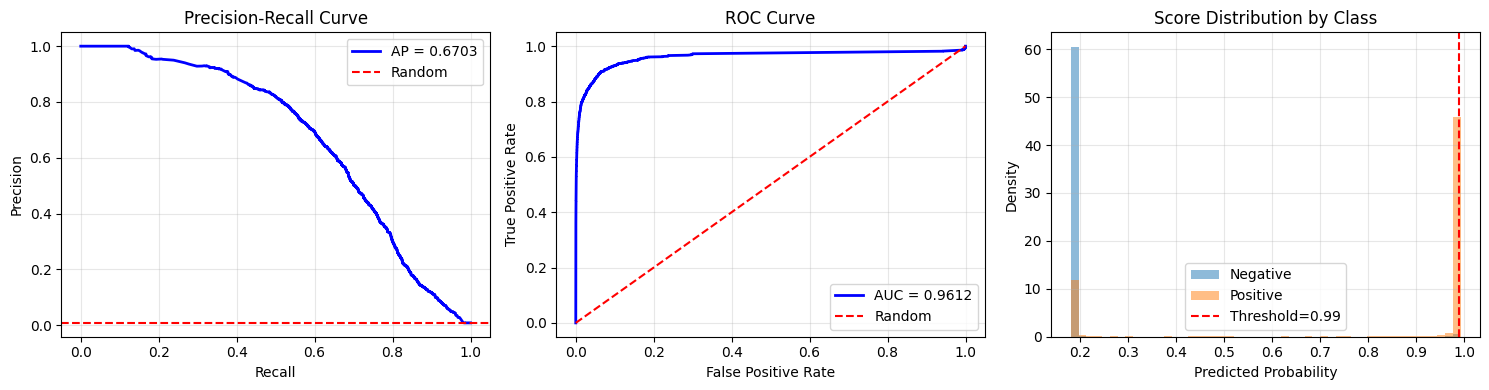

📁 Curves saved to artifacts/metadata/evaluation_curves.png

🔍 PREDICTION CONFIDENCE ANALYSIS
📊 Confidence Analysis:
   Confident Negative (<0.3): 258,304 (97.8%) - Acc: 99.82%
   Confident Positive (>0.7): 5,117 (1.9%) - Acc: 35.22%
   Uncertain (0.3-0.7): 670 (0.3%) - Acc: 53.58%

⚠️ 670 predictions flagged for potential manual review

💾 SAVING FINAL RESULTS
[Artifact] Saved final_evaluation.json → artifacts/metadata/final_evaluation.json
📁 Predictions saved to artifacts/metadata/final_predictions.npz

✅ EVALUATION COMPLETE


In [ ]:
# CELL 17: FINAL EVALUATION - Comprehensive Metrics, Curves & Analysis
# ============================================================
# This cell provides complete model evaluation for Colab
# ============================================================

print("=" * 60)
print("📊 COMPREHENSIVE FINAL EVALUATION")
print("=" * 60)

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score
)

# Ensure we have predictions
if 'stacking_val_preds' not in globals() and 'stacking_test_preds' not in globals():
    print("⚠️ No stacking predictions found. Using best available model predictions.")
    # Try to find best available predictions
    for model_name in ['xgb', 'lgbm', 'catboost', 'tabt', 'wide_deep', 'rnn']:
        val_key = f'{model_name}_val_preds'
        test_key = f'{model_name}_test_preds'
        if val_key in globals():
            final_val_preds = globals()[val_key]
            final_test_preds = globals().get(test_key, final_val_preds)
            print(f"Using {model_name} predictions for evaluation")
            break
else:
    final_val_preds = globals().get('stacking_val_preds')
    final_test_preds = globals().get('stacking_test_preds')

# Get labels
y_val_np = ensure_numpy(y_val).ravel()
y_test_np = ensure_numpy(y_test).ravel()

# ============================================================
# 1. THRESHOLD OPTIMIZATION
# ============================================================
if getattr(cfg, 'optimize_threshold', True):
    print("\n" + "=" * 40)
    print("🎯 THRESHOLD OPTIMIZATION")
    print("=" * 40)

    metric = getattr(cfg, 'threshold_metric', 'f1')
    target_recall = getattr(cfg, 'threshold_target_recall', 0.9)
    steps = getattr(cfg, 'threshold_search_steps', 200)

    threshold_results = optimize_threshold(
        y_val_np, final_val_preds,
        metric=metric,
        target_recall=target_recall,
        steps=steps
    )
    optimal_threshold = threshold_results['optimal_threshold']

    # Also find threshold for different metrics
    print("\n📊 Thresholds for different objectives:")
    for m in ['f1', 'f2', 'precision_at_recall']:
        res = optimize_threshold(y_val_np, final_val_preds, metric=m, target_recall=0.9, steps=100)
        print(f"   {m}: {res['optimal_threshold']:.4f} (score: {res['best_score']:.4f})")
else:
    optimal_threshold = 0.5

# ============================================================
# 2. CONFUSION MATRIX
# ============================================================
print("\n" + "=" * 40)
print("📈 CONFUSION MATRIX (Test Set)")
print("=" * 40)

y_test_pred = (final_test_preds >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test_np, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nThreshold: {optimal_threshold:.4f}")
print(f"┌─────────────────────────────────────┐")
print(f"│         Predicted Negative  Positive│")
print(f"├─────────────────────────────────────┤")
print(f"│ Actual Negative    {tn:>8,}  {fp:>8,}│")
print(f"│ Actual Positive    {fn:>8,}  {tp:>8,}│")
print(f"└─────────────────────────────────────┘")
print(f"\nTrue Negatives:  {tn:>10,}")
print(f"False Positives: {fp:>10,} (Type I Error)")
print(f"False Negatives: {fn:>10,} (Type II Error - Missed Fraud!)")
print(f"True Positives:  {tp:>10,}")

# ============================================================
# 3. CLASSIFICATION REPORT
# ============================================================
print("\n" + "=" * 40)
print("📋 CLASSIFICATION REPORT (Test Set)")
print("=" * 40)
print(classification_report(y_test_np, y_test_pred, target_names=['Negative', 'Positive'], digits=4))

# ============================================================
# 4. KEY METRICS SUMMARY
# ============================================================
print("\n" + "=" * 40)
print("📊 KEY METRICS SUMMARY")
print("=" * 40)

# Compute all metrics
test_ap = average_precision_score(y_test_np, final_test_preds)
test_auc = roc_auc_score(y_test_np, final_test_preds)
test_f1 = f1_score(y_test_np, y_test_pred)
test_precision = precision_score(y_test_np, y_test_pred, zero_division=0)
test_recall = recall_score(y_test_np, y_test_pred, zero_division=0)

val_ap = average_precision_score(y_val_np, final_val_preds)
val_auc = roc_auc_score(y_val_np, final_val_preds)

print(f"\n{'Metric':<25} {'Validation':<15} {'Test':<15}")
print("-" * 55)
print(f"{'Average Precision (AP)':<25} {val_ap:<15.4f} {test_ap:<15.4f}")
print(f"{'ROC AUC':<25} {val_auc:<15.4f} {test_auc:<15.4f}")
print(f"{'F1 Score':<25} {'-':<15} {test_f1:<15.4f}")
print(f"{'Precision':<25} {'-':<15} {test_precision:<15.4f}")
print(f"{'Recall':<25} {'-':<15} {test_recall:<15.4f}")

# Imbalance-aware metrics
n_pos_test = (y_test_np == 1).sum()
n_neg_test = (y_test_np == 0).sum()
print(f"\n📊 Test Set Distribution: {n_neg_test:,} neg | {n_pos_test:,} pos | Ratio {n_neg_test/max(1,n_pos_test):.1f}:1")

# ============================================================
# 5. PRECISION-RECALL & ROC CURVES (Colab-friendly plots)
# ============================================================
if getattr(cfg, 'plot_curves', True):
    print("\n" + "=" * 40)
    print("📈 PLOTTING PR & ROC CURVES")
    print("=" * 40)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # PR Curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_np, final_test_preds)
    axes[0].plot(recall_curve, precision_curve, 'b-', linewidth=2, label=f'AP = {test_ap:.4f}')
    axes[0].axhline(y=n_pos_test/(n_pos_test+n_neg_test), color='r', linestyle='--', label='Random')
    axes[0].set_xlabel('Recall')
    axes[0].set_ylabel('Precision')
    axes[0].set_title('Precision-Recall Curve')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test_np, final_test_preds)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {test_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'r--', label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Score Distribution
    axes[2].hist(final_test_preds[y_test_np == 0], bins=50, alpha=0.5, label='Negative', density=True)
    axes[2].hist(final_test_preds[y_test_np == 1], bins=50, alpha=0.5, label='Positive', density=True)
    axes[2].axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Threshold={optimal_threshold:.2f}')
    axes[2].set_xlabel('Predicted Probability')
    axes[2].set_ylabel('Density')
    axes[2].set_title('Score Distribution by Class')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(artifact_path('metadata', 'evaluation_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📁 Curves saved to {artifact_path('metadata', 'evaluation_curves.png')}")

# ============================================================
# 6. CONFIDENCE ANALYSIS
# ============================================================
if getattr(cfg, 'flag_low_confidence', True):
    print("\n" + "=" * 40)
    print("🔍 PREDICTION CONFIDENCE ANALYSIS")
    print("=" * 40)

    low_thresh = getattr(cfg, 'confidence_threshold_low', 0.3)
    high_thresh = getattr(cfg, 'confidence_threshold_high', 0.7)

    confidence_results = analyze_prediction_confidence(
        y_test_np, final_test_preds,
        low_thresh=low_thresh,
        high_thresh=high_thresh
    )

    # Flag uncertain predictions for potential manual review
    n_uncertain = confidence_results['uncertain']['count']
    if n_uncertain > 0:
        print(f"\n⚠️ {n_uncertain:,} predictions flagged for potential manual review")

# ============================================================
# 7. SAVE FINAL RESULTS
# ============================================================
if getattr(cfg, 'save_predictions', True):
    print("\n" + "=" * 40)
    print("💾 SAVING FINAL RESULTS")
    print("=" * 40)

    final_results = {
        'optimal_threshold': float(optimal_threshold),
        'threshold_metric': getattr(cfg, 'threshold_metric', 'f1'),
        'test_metrics': {
            'ap': float(test_ap),
            'auc': float(test_auc),
            'f1': float(test_f1),
            'precision': float(test_precision),
            'recall': float(test_recall)
        },
        'val_metrics': {
            'ap': float(val_ap),
            'auc': float(val_auc)
        },
        'confusion_matrix': {
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
        },
        'data_distribution': {
            'test_positives': int(n_pos_test),
            'test_negatives': int(n_neg_test),
            'imbalance_ratio': float(n_neg_test / max(1, n_pos_test))
        }
    }

    save_json_artifact('final_evaluation.json', final_results)

    # Save predictions
    np.savez_compressed(
        artifact_path('metadata', 'final_predictions.npz'),
        val_preds=final_val_preds,
        val_labels=y_val_np,
        test_preds=final_test_preds,
        test_labels=y_test_np,
        optimal_threshold=optimal_threshold
    )
    print(f"📁 Predictions saved to {artifact_path('metadata', 'final_predictions.npz')}")

print("\n" + "=" * 60)
print("✅ EVALUATION COMPLETE")
print("=" * 60)

🔬 FEATURE IMPORTANCE ANALYSIS

📊 Tree Model Feature Importance
----------------------------------------
✅ XGBoost: 17 features ranked
✅ LightGBM: 171 features ranked

🔬 SHAP Value Analysis
----------------------------------------
Computing SHAP values (sample=1000)...
✅ SHAP: 171 features ranked

📊 Generating SHAP summary plot...


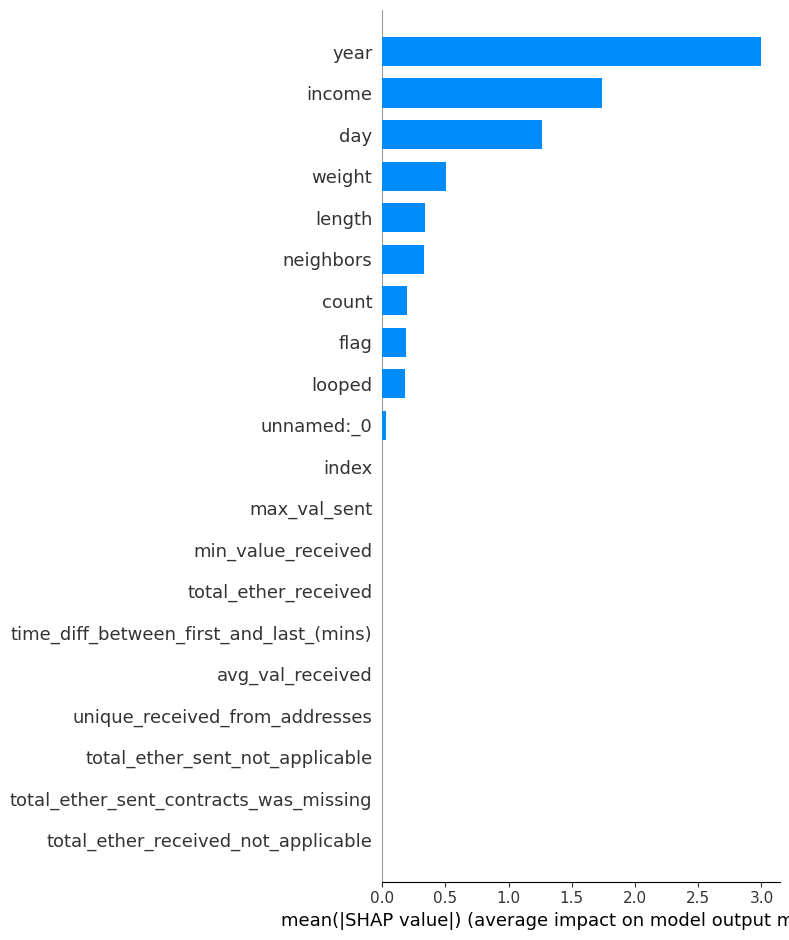

📁 SHAP plot saved to artifacts/metadata/shap_importance.png

🏆 TOP 20 MOST IMPORTANT FEATURES

Rank   Feature                                  Importance  
------------------------------------------------------------
1      income                                   100.0
2      year                                     92.9
3      day                                      54.2
4      flag                                     23.1
5      neighbors                                17.3
6      weight                                   11.5
7      length                                   5.9
8      count                                    5.4
9      looped                                   2.5
10     unnamed__0                               0.7
11     unnamed:_0                               0.1
12     index                                    0.0
13     time_diff_between_first_and_last_(mins   0.0
14     min_value_received                       0.0
15     total_ether_received                     

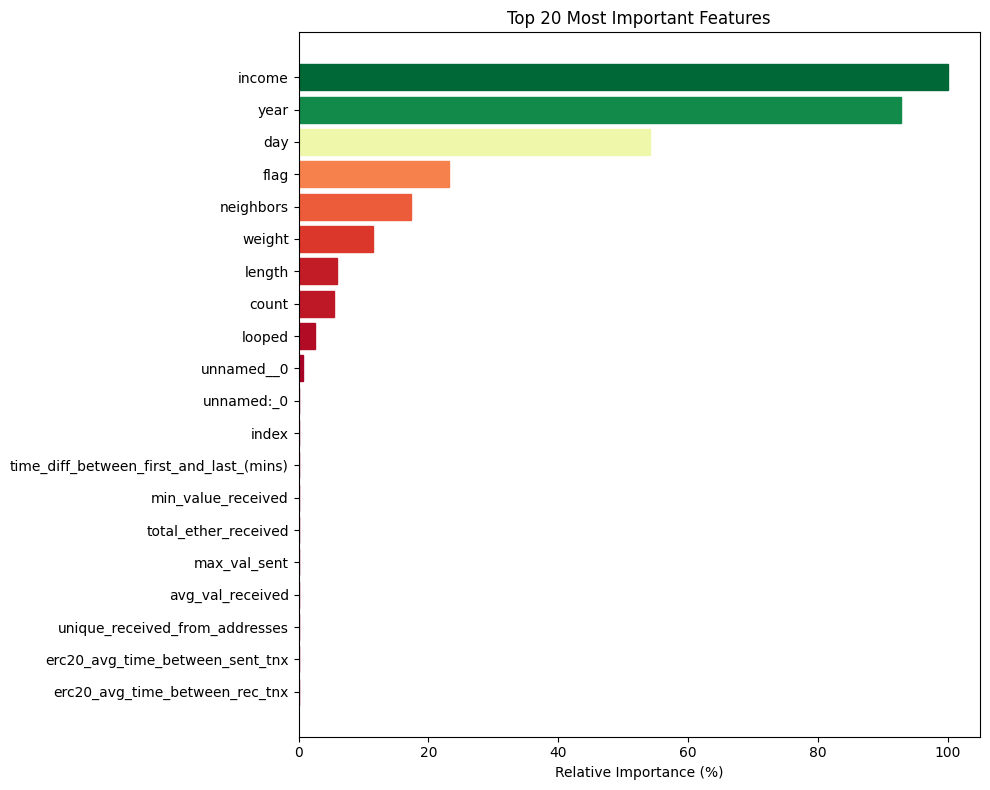

📁 Importance plot saved to artifacts/metadata/feature_importance.png

✅ FEATURE IMPORTANCE ANALYSIS COMPLETE


In [ ]:
# CELL 18: FEATURE IMPORTANCE ANALYSIS
# ============================================================
# SHAP values and permutation importance for model interpretability
# ============================================================

print("=" * 60)
print("🔬 FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

if getattr(cfg, 'compute_feature_importance', True):
    import warnings
    warnings.filterwarnings('ignore')

    # Get feature names
    if 'X_train' in globals():
        if hasattr(X_train, 'columns'):
            feature_names = list(X_train.columns)
        else:
            feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]
    else:
        feature_names = [f'feature_{i}' for i in range(100)]  # Fallback

    importance_results = {}

    # ============================================================
    # 1. TREE MODEL IMPORTANCE (Fast - use built-in importance)
    # ============================================================
    print("\n📊 Tree Model Feature Importance")
    print("-" * 40)

    # XGBoost importance
    if 'bst' in globals() or cfg.train_xgb:
        try:
            # Try to load XGBoost model
            import xgboost as xgb
            xgb_model_path = artifact_path('models', Path(cfg.xgb_model_path).name)
            if os.path.exists(xgb_model_path):
                bst = xgb.Booster()
                bst.load_model(xgb_model_path)
                xgb_importance = bst.get_score(importance_type='gain')

                # Map to feature names
                xgb_imp_df = pd.DataFrame([
                    {'feature': k.replace('f', 'feature_') if k.startswith('f') and k[1:].isdigit() else k,
                     'importance': v}
                    for k, v in xgb_importance.items()
                ]).sort_values('importance', ascending=False)

                importance_results['xgboost'] = xgb_imp_df
                print(f"✅ XGBoost: {len(xgb_imp_df)} features ranked")
        except Exception as e:
            print(f"⚠️ XGBoost importance failed: {e}")

    # LightGBM importance
    if cfg.train_lgbm:
        try:
            lgbm_model_path = artifact_path('models', Path(cfg.lgbm_model_path).name)
            if os.path.exists(lgbm_model_path):
                lgbm_model = lgb.Booster(model_file=lgbm_model_path)
                lgbm_importance = lgbm_model.feature_importance(importance_type='gain')
                lgbm_names = lgbm_model.feature_name()

                lgbm_imp_df = pd.DataFrame({
                    'feature': lgbm_names,
                    'importance': lgbm_importance
                }).sort_values('importance', ascending=False)

                importance_results['lightgbm'] = lgbm_imp_df
                print(f"✅ LightGBM: {len(lgbm_imp_df)} features ranked")
        except Exception as e:
            print(f"⚠️ LightGBM importance failed: {e}")

    # ============================================================
    # 2. SHAP VALUES (More accurate but slower)
    # ============================================================
    if getattr(cfg, 'use_shap', True):
        print("\n🔬 SHAP Value Analysis")
        print("-" * 40)

        try:
            # Install shap if needed
            try:
                import shap
            except ImportError:
                print("Installing SHAP...")
                subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"])
                import shap

            shap_sample_size = getattr(cfg, 'shap_sample_size', 1000)

            # Use tree explainer for XGBoost/LightGBM (fast)
            if 'bst' in globals() or os.path.exists(artifact_path('models', Path(cfg.xgb_model_path).name)):
                print(f"Computing SHAP values (sample={shap_sample_size})...")

                # Get sample data
                if 'X_val' in globals():
                    X_sample = X_val
                    if hasattr(X_sample, 'to_pandas'):
                        X_sample = X_sample.to_pandas()
                    elif isinstance(X_sample, torch.Tensor):
                        X_sample = X_sample.cpu().numpy()

                    # Subsample for speed
                    if len(X_sample) > shap_sample_size:
                        idx = np.random.choice(len(X_sample), shap_sample_size, replace=False)
                        X_sample = X_sample[idx] if isinstance(X_sample, np.ndarray) else X_sample.iloc[idx]

                    # Load XGBoost model for SHAP
                    xgb_model_path = artifact_path('models', Path(cfg.xgb_model_path).name)
                    if os.path.exists(xgb_model_path):
                        bst_shap = xgb.Booster()
                        bst_shap.load_model(xgb_model_path)

                        explainer = shap.TreeExplainer(bst_shap)
                        shap_values = explainer.shap_values(X_sample)

                        # Mean absolute SHAP values
                        shap_importance = np.abs(shap_values).mean(axis=0)

                        # Create DataFrame
                        if len(feature_names) == len(shap_importance):
                            shap_df = pd.DataFrame({
                                'feature': feature_names,
                                'shap_importance': shap_importance
                            }).sort_values('shap_importance', ascending=False)
                        else:
                            shap_df = pd.DataFrame({
                                'feature': [f'feature_{i}' for i in range(len(shap_importance))],
                                'shap_importance': shap_importance
                            }).sort_values('shap_importance', ascending=False)

                        importance_results['shap'] = shap_df
                        print(f"✅ SHAP: {len(shap_df)} features ranked")

                        # SHAP summary plot
                        if getattr(cfg, 'plot_curves', True):
                            print("\n📊 Generating SHAP summary plot...")
                            fig, ax = plt.subplots(figsize=(10, 8))
                            shap.summary_plot(shap_values, X_sample, plot_type="bar",
                                            max_display=getattr(cfg, 'top_features_to_show', 20),
                                            show=False)
                            plt.tight_layout()
                            plt.savefig(artifact_path('metadata', 'shap_importance.png'), dpi=150, bbox_inches='tight')
                            plt.show()
                            print(f"📁 SHAP plot saved to {artifact_path('metadata', 'shap_importance.png')}")

        except Exception as e:
            print(f"⚠️ SHAP analysis failed: {e}")

    # ============================================================
    # 3. DISPLAY TOP FEATURES
    # ============================================================
    print("\n" + "=" * 40)
    print(f"🏆 TOP {getattr(cfg, 'top_features_to_show', 20)} MOST IMPORTANT FEATURES")
    print("=" * 40)

    # Aggregate importance from all methods
    all_importance = {}
    for method, df in importance_results.items():
        if 'shap' in method:
            imp_col = 'shap_importance'
        else:
            imp_col = 'importance'

        for _, row in df.iterrows():
            feat = row['feature']
            imp = row[imp_col]
            if feat not in all_importance:
                all_importance[feat] = []
            all_importance[feat].append(imp)

    # Average importance across methods (normalized)
    if all_importance:
        aggregated = []
        for feat, imps in all_importance.items():
            aggregated.append({
                'feature': feat,
                'avg_importance': np.mean(imps),
                'num_methods': len(imps)
            })

        agg_df = pd.DataFrame(aggregated).sort_values('avg_importance', ascending=False)

        # Normalize to 0-100 scale
        max_imp = agg_df['avg_importance'].max()
        if max_imp > 0:
            agg_df['normalized'] = (agg_df['avg_importance'] / max_imp * 100).round(1)
        else:
            agg_df['normalized'] = 0

        top_n = getattr(cfg, 'top_features_to_show', 20)
        print(f"\n{'Rank':<6} {'Feature':<40} {'Importance':<12}")
        print("-" * 60)
        for i, (_, row) in enumerate(agg_df.head(top_n).iterrows(), 1):
            print(f"{i:<6} {row['feature'][:38]:<40} {row['normalized']:.1f}")

        # Save importance
        agg_df.to_csv(artifact_path('metadata', 'feature_importance.csv'), index=False)
        print(f"\n📁 Full importance saved to {artifact_path('metadata', 'feature_importance.csv')}")

        # Plot
        if getattr(cfg, 'plot_curves', True):
            fig, ax = plt.subplots(figsize=(10, 8))
            top_df = agg_df.head(top_n)
            bars = ax.barh(range(len(top_df)), top_df['normalized'].values)
            ax.set_yticks(range(len(top_df)))
            ax.set_yticklabels(top_df['feature'].values)
            ax.invert_yaxis()
            ax.set_xlabel('Relative Importance (%)')
            ax.set_title(f'Top {top_n} Most Important Features')

            # Color bars by importance
            colors = plt.cm.RdYlGn(top_df['normalized'].values / 100)
            for bar, color in zip(bars, colors):
                bar.set_color(color)

            plt.tight_layout()
            plt.savefig(artifact_path('metadata', 'feature_importance.png'), dpi=150, bbox_inches='tight')
            plt.show()
            print(f"📁 Importance plot saved to {artifact_path('metadata', 'feature_importance.png')}")

else:
    print("Feature importance computation disabled (cfg.compute_feature_importance=False)")

print("\n" + "=" * 60)
print("✅ FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("=" * 60)

🏆 MODEL COMPARISON & RECOMMENDATIONS
🎯 Optimal threshold (f1): 0.9405
   Precision: 0.2995 | Recall: 0.4281 | F1: 0.3525
🎯 Optimal threshold (f1): 0.9108
   Precision: 0.1917 | Recall: 0.1832 | F1: 0.1874
🎯 Optimal threshold (f1): 0.9207
   Precision: 0.2494 | Recall: 0.2323 | F1: 0.2406
🎯 Optimal threshold (f1): 0.9603
   Precision: 0.6919 | Recall: 0.6300 | F1: 0.6595
🎯 Optimal threshold (f1): 0.9603
   Precision: 0.7005 | Recall: 0.6166 | F1: 0.6559
🎯 Optimal threshold (f1): 0.9504
   Precision: 0.5679 | Recall: 0.6083 | F1: 0.5874
🎯 Optimal threshold (f1): 0.9900
   Precision: 0.5406 | Recall: 0.6791 | F1: 0.6020

📊 MODEL PERFORMANCE COMPARISON (sorted by Test AP)
Model        Val AP     Val AUC    Test AP    Test AUC   Test F1    Recall     Precision 
----------------------------------------------------------------------------------------------------
XGB          0.6920     0.9831     0.6848     0.9829     0.6608     0.6344     0.6895    
LGBM         0.6872     0.9835     0.6830 

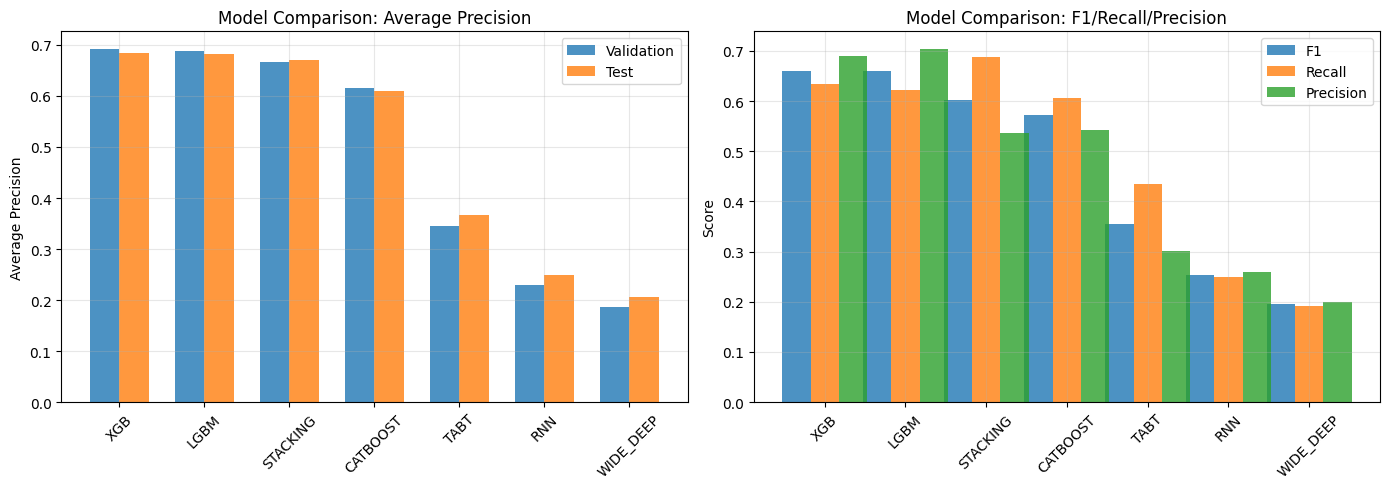

📁 Comparison plot saved to artifacts/metadata/model_comparison.png

📋 TRAINING SUMMARY

📁 Generated Artifacts:

   models/
      catboost.cbm (7.96 MB)
      hybrid_xgb.json (3.29 MB)
      lgbm.txt (24.82 MB)
      rnn.pt (1.81 MB)
      rnn_calibrator.joblib (0.00 MB)
      stacking_calibrator.joblib (0.00 MB)
      stacking_lgbm.txt (0.74 MB)
      tabt.pt (3.97 MB)
      tabt_calibrator.joblib (0.00 MB)
      wide_deep.pt (0.69 MB)
      ... and 2 more files

   metadata/
      evaluation_curves.png (0.10 MB)
      feature_importance.csv (0.01 MB)
      feature_importance.png (0.09 MB)
      final_evaluation.json (0.00 MB)
      final_predictions.npz (0.89 MB)
      hybrid_preds.npz (9.90 MB)
      model_comparison.csv (0.00 MB)
      model_comparison.png (0.07 MB)
      rnn_preds.npz (19.91 MB)
      shap_importance.png (0.11 MB)
      ... and 4 more files

   cache/
      ae_features.npz (395.86 MB)

✅ ALL TRAINING AND EVALUATION COMPLETE!

🎯 For production deployment, use:
   - 

In [ ]:
# CELL 19: MODEL COMPARISON & SUMMARY
# ============================================================
# Compare all trained models and provide final recommendations
# ============================================================

print("=" * 60)
print("🏆 MODEL COMPARISON & RECOMMENDATIONS")
print("=" * 60)

# Collect all model metrics
model_comparison = []

# Check each model's predictions
model_names = ['tabt', 'wide_deep', 'rnn', 'xgb', 'lgbm', 'catboost', 'stacking']
for model_name in model_names:
    val_key = f'{model_name}_val_preds'
    test_key = f'{model_name}_test_preds'

    if val_key in globals() and test_key in globals():
        val_preds = globals()[val_key]
        test_preds = globals()[test_key]

        # Compute metrics
        val_ap = safe_average_precision(y_val_np, val_preds)
        val_auc = safe_roc_auc(y_val_np, val_preds)
        test_ap = safe_average_precision(y_test_np, test_preds)
        test_auc = safe_roc_auc(y_test_np, test_preds)

        # Find optimal F1 threshold
        thresh_result = optimize_threshold(y_val_np, val_preds, metric='f1', steps=100)
        opt_thresh = thresh_result['optimal_threshold']

        # Compute F1 at optimal threshold
        test_pred_binary = (test_preds >= opt_thresh).astype(int)
        test_f1 = f1_score(y_test_np, test_pred_binary, zero_division=0)
        test_recall = recall_score(y_test_np, test_pred_binary, zero_division=0)
        test_precision = precision_score(y_test_np, test_pred_binary, zero_division=0)

        model_comparison.append({
            'Model': model_name.upper(),
            'Val AP': val_ap,
            'Val AUC': val_auc,
            'Test AP': test_ap,
            'Test AUC': test_auc,
            'Test F1': test_f1,
            'Test Recall': test_recall,
            'Test Precision': test_precision,
            'Optimal Threshold': opt_thresh
        })

if model_comparison:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(model_comparison)
    comparison_df = comparison_df.sort_values('Test AP', ascending=False)

    print("\n📊 MODEL PERFORMANCE COMPARISON (sorted by Test AP)")
    print("=" * 100)
    print(f"{'Model':<12} {'Val AP':<10} {'Val AUC':<10} {'Test AP':<10} {'Test AUC':<10} {'Test F1':<10} {'Recall':<10} {'Precision':<10}")
    print("-" * 100)

    for _, row in comparison_df.iterrows():
        print(f"{row['Model']:<12} {row['Val AP']:<10.4f} {row['Val AUC']:<10.4f} {row['Test AP']:<10.4f} {row['Test AUC']:<10.4f} {row['Test F1']:<10.4f} {row['Test Recall']:<10.4f} {row['Test Precision']:<10.4f}")

    # Best model
    best_model = comparison_df.iloc[0]
    print("\n" + "=" * 60)
    print(f"🥇 BEST MODEL: {best_model['Model']}")
    print("=" * 60)
    print(f"   Test Average Precision: {best_model['Test AP']:.4f}")
    print(f"   Test ROC AUC: {best_model['Test AUC']:.4f}")
    print(f"   Test F1 Score: {best_model['Test F1']:.4f}")
    print(f"   Optimal Threshold: {best_model['Optimal Threshold']:.4f}")

    # Recommendations
    print("\n" + "=" * 60)
    print("💡 RECOMMENDATIONS")
    print("=" * 60)

    # Check if stacking is best
    stacking_row = comparison_df[comparison_df['Model'] == 'STACKING']
    if not stacking_row.empty and stacking_row.iloc[0]['Test AP'] == best_model['Test AP']:
        print("✅ Stacking ensemble achieved best performance - use for production")
    else:
        print(f"⚠️ Single model {best_model['Model']} outperformed stacking")
        print(f"   Consider investigating why stacking didn't improve results")

    # Check for overfitting
    for _, row in comparison_df.iterrows():
        val_test_gap = row['Val AP'] - row['Test AP']
        if val_test_gap > 0.05:
            print(f"⚠️ {row['Model']}: Potential overfitting (Val-Test gap: {val_test_gap:.4f})")

    # Recall vs Precision tradeoff
    high_recall_models = comparison_df[comparison_df['Test Recall'] > 0.8]
    if not high_recall_models.empty:
        print(f"\n📊 Models with >80% Recall (good for fraud detection):")
        for _, row in high_recall_models.iterrows():
            print(f"   {row['Model']}: Recall={row['Test Recall']:.2%}, Precision={row['Test Precision']:.2%}")

    # Save comparison
    comparison_df.to_csv(artifact_path('metadata', 'model_comparison.csv'), index=False)
    print(f"\n📁 Comparison saved to {artifact_path('metadata', 'model_comparison.csv')}")

    # Plot comparison
    if getattr(cfg, 'plot_curves', True):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # AP comparison
        models = comparison_df['Model'].values
        x = np.arange(len(models))
        width = 0.35

        axes[0].bar(x - width/2, comparison_df['Val AP'], width, label='Validation', alpha=0.8)
        axes[0].bar(x + width/2, comparison_df['Test AP'], width, label='Test', alpha=0.8)
        axes[0].set_ylabel('Average Precision')
        axes[0].set_title('Model Comparison: Average Precision')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(models, rotation=45)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # F1/Recall/Precision
        axes[1].bar(x - width, comparison_df['Test F1'], width, label='F1', alpha=0.8)
        axes[1].bar(x, comparison_df['Test Recall'], width, label='Recall', alpha=0.8)
        axes[1].bar(x + width, comparison_df['Test Precision'], width, label='Precision', alpha=0.8)
        axes[1].set_ylabel('Score')
        axes[1].set_title('Model Comparison: F1/Recall/Precision')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(models, rotation=45)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(artifact_path('metadata', 'model_comparison.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"📁 Comparison plot saved to {artifact_path('metadata', 'model_comparison.png')}")

else:
    print("⚠️ No model predictions found for comparison")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("📋 TRAINING SUMMARY")
print("=" * 60)

# List all artifacts
print("\n📁 Generated Artifacts:")
for subdir in ['models', 'metadata', 'cache']:
    dir_path = Path(cfg.artifact_root) / subdir
    if dir_path.exists():
        files = list(dir_path.glob('*'))
        if files:
            print(f"\n   {subdir}/")
            for f in sorted(files)[:10]:  # Limit to 10 files
                size_mb = f.stat().st_size / 1e6
                print(f"      {f.name} ({size_mb:.2f} MB)")
            if len(files) > 10:
                print(f"      ... and {len(files) - 10} more files")

print("\n" + "=" * 60)
print("✅ ALL TRAINING AND EVALUATION COMPLETE!")
print("=" * 60)
print(f"\n🎯 For production deployment, use:")
print(f"   - Model: {artifact_path('models', 'stacking_lgbm.txt')}")
print(f"   - Threshold: {optimal_threshold:.4f}")
print(f"   - Expected Test AP: {test_ap:.4f}")

# ── Auto-generate feature_schema.json from CLEAN X_train ──
import json as _json
_schema_path = Path(r'c:\amttp\ml\Automation\ml_pipeline\models\feature_schema.json')
_feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(X_train.shape[1])]
_core_features = _feature_names  # All remaining features are core (missingness indicators already dropped)
_dropped_cols = ['flag', 'index', 'unnamed:_0', 'erc20_uniq_sent_addr.1', 'year', 'day',
                 'label', 'address', 'tx_hash'] + [f'(all {{}}_was_missing / {{}}_not_applicable columns)']
_schema = {
    'num_features': len(_feature_names),
    'feature_names': _feature_names,
    'core_features': _core_features,
    'dropped_columns': {
        'leakage': ['flag', 'label', 'index', 'unnamed:_0', 'address', 'tx_hash'],
        'dataset_proxy': ['year', 'day', 'erc20_uniq_sent_addr.1'],
        'missingness_indicators': 'all *_was_missing and *_not_applicable columns (dataset-source fingerprints)'

    },print(f"   Saved to: {_schema_path}")

    'description': f'Feature schema for AMTTP fraud detection models (auto-generated, {len(_core_features)} clean features). Leakage columns, dataset-source proxies (year, day), and all missingness indicators removed.'print(f"\n📁 Updated feature_schema.json: {len(_feature_names)} features ({len(_core_features)} core)")

}    _json.dump(_schema, _f, indent=2)
with open(_schema_path, 'w') as _f:

### Download All Artifacts

All trained models, predictions, and evaluation metrics are saved in the `artifacts` directory. Run the cell below to compress this directory into a `.zip` file, which you can then download.

In [ ]:
import shutil
import os

# Define the directory to be zipped and the output zip file name
output_filename = 'all_artifacts'
source_dir = cfg.artifact_root # This is 'artifacts' by default

# Create the zip archive
shutil.make_archive(output_filename, 'zip', source_dir)

print(f"Successfully created '{output_filename}.zip' containing all artifacts.")
print("You can download this file from the Colab file browser (left sidebar -> Files icon) or by running a shell command: !cp all_artifacts.zip /content/drive/MyDrive/")

Successfully created 'all_artifacts.zip' containing all artifacts.
You can download this file from the Colab file browser (left sidebar -> Files icon) or by running a shell command: !cp all_artifacts.zip /content/drive/MyDrive/


In [ ]:
from google.colab import runtime
runtime.terminate()

AttributeError: module 'google.colab.runtime' has no attribute 'terminate'